# Sensitivity charts

## Mappings from dashboard json exports to chart labels and number formatting

In [2]:
import json
from pathlib import Path

# Per-metric display format (string templates)
format_val = {
  # Envelope (spread)
  "median_W":           "{:.1f}",     # absolute width (units of variable)
  "p90_W":              "{:.1f}",
  "RW_med":             "{:.0%}",     # relative width (median)
  "RW_high":            "{:.0%}",     # on event days
  "RW_low":             "{:.0%}",
  "Peak_ratio":         "{:.2f}",

  # Central shift (displacement)
  "CS_abs":             "{:.1f}",     # absolute shift
  "CS_rel":             "{:.1%}",     # relative shift
  "Signed_C_shift":     "{:+.1%}",    # signed relative shift

  # Coverage
  "Coverage_frac":      "{:.0%}",
  "coverage100":        "{:.0%}",
  "Outside_upper":      "{:.0%}",
  "Outside_lower":      "{:.0%}",

  # Event contrast
  "Event_contrast":     "{:+.0%}",    # RW_high ˆ' RW_low (relative units)
  "Event_ratio":        "{:.2f}",

  # Duration-curve signature
  "RA_5":               "{:.0%}",
  "RA_50":              "{:.0%}",
  "RA_95":              "{:.0%}",

  # Optional shift detail (from your table)
  "delta_mean":         "{:+.0f}",
  "median_delta":       "{:+.0f}",
  "median_delta_pct":   "{:+.0%}",
  "delta_min":          "{:+.0f}",
  "delta_p50":          "{:+.0f}",
  "delta_p90":          "{:+.0f}",
  "delta_max":          "{:+.0f}",
  "delta_event_pairs_mean": "{:+.0f}",
  "delta_non_event_pairs_mean": "{:+.0f}",
  "normalized_mean_delta": "{:+.0%}",

  # Bias metrics
  "PBIAS%": "{:+.0f}%",
  "Bias(obs-pred)": "{:+.0f}",

  # Alias/legacy keys (if used)
  "relative_width":      "{:.0%}",
  "relative_width_high": "{:.0%}",
  "relative_width_low":  "{:.0%}",
  "relative_width_event": "{:.0%}",
  "relative_width_nonevent": "{:.0%}",
  "relative_width_event_contrast": "{:+.0%}",
  "event_ratio": "{:.2f}Ã--",

  # __baseline__ event/nonevent ensemble spread
  "bl_event_ratio":          "{:.2f}Ã--",
  "bl_RW_event":             "{:.0%}",
  "bl_RW_nonevent":          "{:.0%}",
  "bl_median_W_event":       "{:.1f}",
  "bl_median_W_nonevent":    "{:.1f}",
  "bl_mean_W_event":         "{:.1f}",
  "bl_mean_W_nonevent":      "{:.1f}",
  "bl_p90_W_event":          "{:.1f}",
  "bl_p90_W_nonevent":       "{:.1f}",

  # Absolute width event ratio
  "bl_abs_W_event_ratio":    "{:.1f}Ã--",

  # Mean-based relative width (all / event / non-event)
  "bl_RW_mean_all":          "{:.0%}",
  "bl_RW_mean_event":        "{:.0%}",
  "bl_RW_mean_nonevent":     "{:.0%}",

  # (max-min)/median metrics
  "bl_median_maxmin_over_median":          "{:.0%}",
  "bl_mean_maxmin_over_median":            "{:.0%}",
  "bl_median_maxmin_over_median_event":    "{:.0%}",
  "bl_median_maxmin_over_median_nonevent": "{:.0%}",
  "bl_mean_maxmin_over_median_event":      "{:.0%}",
  "bl_mean_maxmin_over_median_nonevent":   "{:.0%}",
}

# Single source of truth for label selection.
#
# Each key is the technical metric name expected in the exported stats JSON.
# `label` is what you pass in semantic_labels.
# Add `path` only when that metric name appears in multiple places in the export JSON.
# Example: "path": ("overlay_comparison", "__baseline__", "relative_width")
semantic_label_map = {
  # Width & spread
  "median_W": {"path": ("overlay_comparison", "__baseline__", "median_W"), "label": "Model raw width median (W)"},
  "p90_W": {"path": ("overlay_comparison", "__baseline__", "p90_W"), "label": "Model raw width p90 (W)"},
  "RW_med": {"path": ("overlay_comparison", "__baseline__", "relative_width"), "label": "Model relative width median((p95-p05)/p50)"},
  "RW_high": {"path": ("overlay_comparison", "__baseline__", "relative_width_event"), "label": "Relative width (high-flow days)"},
  "RW_low": {"path": ("overlay_comparison", "__baseline__", "relative_width_nonevent"), "label": "Relative width (baseflow days)"},

  # Shift & coverage
  "Coverage_frac": {"label": "Coverage fraction (overlay inside envelope)"},
  "delta_mean": {"path": ("overlay_comparison", "BASE", "delta_mean"), "label": "Mean shift (vs. BASE)"},
  "mean_delta_pct": {"path": ("overlay_comparison", "BASE", "delta_mean_pct"), "label": "Percent of mean shift (vs. BASE)"},
  "median_delta": {"path": ("overlay_comparison", "BASE", "median_delta"), "label": "Median shift (vs. BASE)"},
  "median_delta_pct": {"path": ("overlay_comparison", "BASE", "median_delta_pct"), "label": "Median percent shift (vs. BASE)"},
  "delta_max": {"label": "Shift in max (baseline - overlay)"},
  "delta_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_event_pairs_mean"), "label": "Mean shift (high-flow days)"},
  "delta_non_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_non_event_pairs_mean"), "label": "Mean shift (baseflow days)"},
  "delta_min": {"label": "Shift in min (baseline - overlay)"},
  "delta_p50": {"label": "Shift in p50 (baseline - overlay)"},
  "delta_p90": {"label": "Shift in p90 (baseline - overlay)"},
  "normalized_mean_delta": {"label": "Normalized mean shift (delta / baseline mean)"},
  "coverage100": {"path": ("same_day", "coverage100"), "label": "Min/Max Coverage (observations inside envelope)"}, 


  # BIAS
  "PBIAS%": {"path": ("same_day", "PBIAS%"), "label": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)"},
  "Bias(obs-pred)": {"path": ("same_day", "Bias(obs-pred)"), "label": "Mean bias (observed - simulated)"},


  # Event contrast (if used)
  "relative_width_event_contrast": {"label": "Flow contrast (high / low)"},
  "event_ratio": {"label": "Flow ratio (high-flow / baseflow)"},
  "relative_width_high": {"label": "Relative width high decile"},
  "relative_width_low": {"label": "Relative width low decile"},

  # __baseline__ ensemble event/nonevent spread
  "bl_event_ratio": {"path": ("overlay_comparison", "__baseline__", "event_ratio"), "label": "high-flow ratio (ensemble spread)"},
  "bl_RW_event": {"path": ("overlay_comparison", "__baseline__", "relative_width_event"), "label": "Ensemble RW (high-flow days)"},
  "bl_RW_nonevent": {"path": ("overlay_comparison", "__baseline__", "relative_width_nonevent"), "label": "Ensemble RW (baseflow days)"},
  "bl_median_W_event": {"path": ("overlay_comparison", "__baseline__", "median_W_event"), "label": "Ensemble median W (high-flow days)"},
  "bl_median_W_nonevent": {"path": ("overlay_comparison", "__baseline__", "median_W_nonevent"), "label": "Ensemble median W (baseflow days)"},
  "bl_mean_W_event": {"path": ("overlay_comparison", "__baseline__", "mean_W_event"), "label": "Ensemble mean W (high-flow days)"},
  "bl_mean_W_nonevent": {"path": ("overlay_comparison", "__baseline__", "mean_W_nonevent"), "label": "Ensemble mean W (baseflow days)"},
  "bl_p90_W_event": {"path": ("overlay_comparison", "__baseline__", "p90_W_event"), "label": "Ensemble p90 W (high-flow days)"},
  "bl_p90_W_nonevent": {"path": ("overlay_comparison", "__baseline__", "p90_W_nonevent"), "label": "Ensemble p90 W (baseflow days)"},

  # Absolute width event ratio
  "bl_abs_W_event_ratio": {"path": ("overlay_comparison", "__baseline__", "abs_width_event_ratio"), "label": "Absolute width flow ratio (ensemble)"},

  # Mean-based relative width
  "bl_RW_mean_all": {"path": ("overlay_comparison", "__baseline__", "relative_width_mean"), "label": "Mean relative width (all days)"},
  "bl_RW_mean_event": {"path": ("overlay_comparison", "__baseline__", "relative_width_mean_event"), "label": "Mean relative width (high-flow days)"},
  "bl_RW_mean_nonevent": {"path": ("overlay_comparison", "__baseline__", "relative_width_mean_nonevent"), "label": "Mean relative width (baseflow days)"},

  # (max-min)/median metrics
  "bl_median_maxmin_over_median": {"path": ("overlay_comparison", "__baseline__", "median_maxmin_over_median"), "label": "Median (max-min/median) (all days)"},
  "bl_mean_maxmin_over_median": {"path": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median"), "label": "Mean (max-min/median) (all days)"},
  "bl_median_maxmin_over_median_event": {"path": ("overlay_comparison", "__baseline__", "median_maxmin_over_median_event"), "label": "Median (max-min/median) (high-flow days)"},
  "bl_median_maxmin_over_median_nonevent": {"path": ("overlay_comparison", "__baseline__", "median_maxmin_over_median_nonevent"), "label": "Median (max-min/median) (baseflow days)"},
  "bl_mean_maxmin_over_median_event": {"path": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median_event"), "label": "Mean (max-min/median) (high-flow days)"},
  "bl_mean_maxmin_over_median_nonevent": {"path": ("overlay_comparison", "__baseline__", "mean_maxmin_over_median_nonevent"), "label": "Mean (max-min/median) (baseflow days)"},

}

### helper functions to convert data according to mappings

In [3]:
# Backwards-compatible flat view if you still want a technical-name -> label lookup elsewhere.
semantic_label = {
    technical_name: spec["label"]
    for technical_name, spec in semantic_label_map.items()
}

def _is_scalar_metric_value(value):
    """Return True for JSON scalar metric values that can be stored in the example dict."""
    return isinstance(value, (int, float)) and not isinstance(value, bool)


def _normalise_export_spec(export_spec):
    """
    Accept one export item in one of two forms:
      - {"path": ..., "scenario": ..., "variable": ...}
      - (path, scenario, variable)
    
    Variable can be omitted from the dict if the JSON file contains
    dashboard_state.variable, but scenario must always be supplied because it is
    not part of the current export payload.
    """
    if isinstance(export_spec, dict):
        path = export_spec.get("path")
        scenario = export_spec.get("scenario")
        variable = export_spec.get("variable")
    elif isinstance(export_spec, (tuple, list)) and len(export_spec) == 3:
        path, scenario, variable = export_spec
    else:
        raise TypeError(
            "Each export spec must be either a dict with keys 'path', 'scenario', 'variable' "
            "or a 3-item tuple/list of (path, scenario, variable)."
        )

    if not path:
        raise ValueError(f"Invalid export spec {export_spec!r}: missing file path.")
    if not scenario:
        raise ValueError(
            f"Invalid export spec {export_spec!r}: missing scenario. "
            "Scenario is not stored in the current JSON export, so it must be provided explicitly."
        )

    return Path(path), str(scenario), variable


def _load_stat_export(export_spec, *, verbose=True):
    """Load one JSON export file and return its payload plus resolved identifiers."""
    path, scenario, variable = _normalise_export_spec(export_spec)
    if verbose:
        print(f"Loading stats export: {path}")

    if not path.exists():
        raise FileNotFoundError(f"Stats export file does not exist: {path}")

    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if not isinstance(payload, dict):
        raise ValueError(f"Stats export {path} does not contain a top-level JSON object.")

    dashboard_state = payload.get("metadata", {}).get("dashboard_state") or payload.get("dashboard_state") or {}
    if variable is None:
        variable = dashboard_state.get("variable")

    if not variable:
        raise ValueError(
            f"Could not determine variable for {path}. "
            "Provide it explicitly in the export spec or ensure the payload has dashboard_state.variable."
        )

    stats = payload.get("stats")
    if not isinstance(stats, dict):
        raise ValueError(f"Stats export {path} is missing a 'stats' dictionary.")

    if verbose:
        print(f"  scenario={scenario}, variable={variable}")
    return {
        "path": path,
        "scenario": str(scenario),
        "variable": str(variable),
        "payload": payload,
        "stats": stats,
    }


def _normalise_semantic_entry(technical_name, entry):
    """Normalise one semantic_label_map entry to {'label': ..., 'path': ...}."""
    if isinstance(entry, str):
        spec = {"label": entry, "path": None}
    elif isinstance(entry, dict):
        label = entry.get("label")
        if not label or not isinstance(label, str):
            raise ValueError(
                f"semantic_label_map[{technical_name!r}] must define a string 'label'."
            )
        path = entry.get("path")
        if path is not None:
            if not isinstance(path, (tuple, list)) or not path or not all(isinstance(part, str) for part in path):
                raise ValueError(
                    f"semantic_label_map[{technical_name!r}]['path'] must be a non-empty tuple/list of strings."
                )
            path = tuple(path)
        spec = {"label": label, "path": path}
    else:
        raise TypeError(
            f"semantic_label_map[{technical_name!r}] must be either a label string or a dict with 'label' and optional 'path'."
        )

    return spec


def _normalise_semantic_label_map(semantic_label_map):
    """Return a validated semantic_label_map with uniform dict entries."""
    normalised = {}
    reverse_semantic_label = {}
    duplicate_labels = {}

    for technical_name, entry in semantic_label_map.items():
        spec = _normalise_semantic_entry(technical_name, entry)
        label = spec["label"]
        if label in reverse_semantic_label and reverse_semantic_label[label] != technical_name:
            duplicate_labels.setdefault(label, set()).update([reverse_semantic_label[label], technical_name])
        reverse_semantic_label[label] = technical_name
        normalised[technical_name] = spec

    if duplicate_labels:
        raise ValueError(
            "semantic_label_map contains duplicate labels mapped to different technical names: "
            f"{ {label: sorted(names) for label, names in duplicate_labels.items()} }"
        )

    return normalised


def _find_metric_matches(node, technical_name, path=()):
    """
    Recursively search the exported stats dictionary for a technical metric key.

    Returns a list of (path_tuple, value) matches so ambiguous metrics can be
    reported clearly instead of silently choosing the wrong number.
    """
    matches = []

    if isinstance(node, dict):
        for key, value in node.items():
            next_path = path + (str(key),)
            if key == technical_name and _is_scalar_metric_value(value):
                matches.append((next_path, value))
            matches.extend(_find_metric_matches(value, technical_name, next_path))

    elif isinstance(node, list):
        for index, value in enumerate(node):
            matches.extend(_find_metric_matches(value, technical_name, path + (str(index),)))

    return matches


_TECHNICAL_FALLBACK_PATHS = {
    # Chart 3 compatibility: some exports no longer populate same_day,
    # but still expose equivalent diagnostics under other sections.
    "coverage100": [
        ("measured_vs_series", "vs_mean_coverage100"),
        ("overlay_comparison", "BASE", "coverage_fraction"),
    ],
    "Bias(obs-pred)": [
        ("overlay_full_series", "BASE", "Bias(obs-pred)"),
    ],
}


def _try_extract_from_path(stats_dict, path):
    """Try to resolve one explicit path; return (found, value)."""
    current = stats_dict
    for part in tuple(path):
        if not isinstance(current, dict) or part not in current:
            return False, float('nan')
        current = current[part]
    if current is None:
        return True, 0
    if not _is_scalar_metric_value(current):
        return False, float('nan')
    return True, current


def _extract_metric_value(stats_dict, technical_name, explicit_path=None, *, verbose=True):
    """Extract one metric value from the exported stats dictionary."""
    if explicit_path is not None:
        explicit_path = tuple(explicit_path)
        found_explicit, explicit_value = _try_extract_from_path(stats_dict, explicit_path)
        if found_explicit:
            if verbose:
                print(f"    using semantic_label_map path {explicit_path} -> {explicit_value}")
            return explicit_value

        fallback_paths = _TECHNICAL_FALLBACK_PATHS.get(technical_name, [])
        for fallback_path in fallback_paths:
            found_fallback, fallback_value = _try_extract_from_path(stats_dict, fallback_path)
            if found_fallback:
                if verbose:
                    print(
                        f"    explicit path {explicit_path} missing for '{technical_name}'; "
                        f"using fallback path {tuple(fallback_path)} -> {fallback_value}"
                    )
                return fallback_value

        if verbose:
            print(f"    explicit path {explicit_path} for '{technical_name}' not found, returning NaN")
        return float('nan')

    matches = _find_metric_matches(stats_dict, technical_name)
    if not matches:
        if verbose:
            print(f"    metric '{technical_name}' not found anywhere in the stats export, returning NaN")
        return float('nan')
    if len(matches) > 1:
        pretty_paths = [" -> ".join(path) for path, _ in matches]
        raise ValueError(
            f"Metric '{technical_name}' matched more than one location in the stats export: {pretty_paths}. "
            "Add a 'path' entry to semantic_label_map for this metric."
        )

    metric_path, metric_value = matches[0]
    if verbose:
        print(f"    found {technical_name} at {' -> '.join(metric_path)} = {metric_value}")
    return metric_value


def _format_metric_value(value, fmt, technical_name):
    """Render one numeric value with the metric format string."""
    try:
        return fmt.format(value)
    except Exception as exc:
        raise ValueError(
            f"Could not format value {value!r} for metric '{technical_name}' with format {fmt!r}."
        ) from exc


def _build_requested_metric_specs(semantic_labels, semantic_label_map, format_map):
    """Resolve requested labels to technical names, formats, and optional paths."""
    reverse_semantic_label = {
        spec["label"]: technical_name
        for technical_name, spec in semantic_label_map.items()
    }

    requested_specs = []
    for requested_label in semantic_labels:
        if requested_label in reverse_semantic_label:
            technical_name = reverse_semantic_label[requested_label]
            output_label = requested_label
        elif requested_label in semantic_label_map:
            technical_name = requested_label
            output_label = semantic_label_map[requested_label]["label"]
        else:
            available = sorted(reverse_semantic_label.keys())
            raise KeyError(
                f"Unknown semantic label or technical name: {requested_label!r}. "
                f"Available semantic labels include: {available}"
            )

        if technical_name not in format_map:
            raise KeyError(
                f"No format string found in format_val for technical metric '{technical_name}'. "
                "Add it to format_val before building the metrics dictionary."
            )

        requested_specs.append(
            {
                "technical_name": technical_name,
                "output_label": output_label,
                "format": format_map[technical_name],
                "path": semantic_label_map[technical_name].get("path"),
            }
        )

    return requested_specs


def build_metrics_dict_from_stat_exports(
    export_specs,
    semantic_labels,
    *,
    semantic_label_map=None,
    format_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=True,
):
    """
    Build a dict with the same structure as the earlier manual 'metrics' blocks from a
    list of dashboard JSON exports.

    Parameters
    ----------
    export_specs : list
        One item per scenario-variable combination. Recommended form:
            {"path": <json_path>, "scenario": "WASTE", "variable": "TP"}
        A tuple/list of (path, scenario, variable) also works.

    semantic_labels : list[str]
        Labels you want in the output dictionary, using the labels defined in
        semantic_label_map, for example:
            ["Median width", "Coverage", "Mean Î""]
        Technical keys are also accepted directly.

    semantic_label_map : dict, optional
        Mapping of technical metric names to config dicts with:
            - 'label': display label used in semantic_labels
            - 'path' : optional explicit path inside the exported stats dict
        A plain string value is also accepted as shorthand for {'label': <string>}.

    format_map : dict, optional
        Mapping of technical metric names to format strings. If a technical name
        has no format entry, the function raises a helpful error.

    scenario_order / variable_order : list, optional
        If omitted, the function uses the order in which scenarios and variables
        appear in export_specs.

    include_technical_names : bool, default False
        If True, each output metric also gets a '__technical_name' field.

    format_mode : {'metadata', 'values'}, default 'metadata'
        'metadata' keeps numeric values and adds '__format'.
        'values' applies the format string to each extracted value and omits '__format'.

    verbose : bool, default True
        Print progress information while reading files and extracting metrics.

    Returns
    -------
    dict
        A dictionary shaped like:
            {
                "metrics": {
                    "Median width": {
                        "__format": "{:.1f}",
                        "WASTE": {"TP": 12.8, "TN": 17.6},
                        ...
                    },
                    ...
                }
            }
    """
    if semantic_label_map is None:
        semantic_label_map = globals()["semantic_label_map"]
    semantic_label_map = _normalise_semantic_label_map(semantic_label_map)

    if format_map is None:
        format_map = format_val

    valid_format_modes = {"metadata", "values"}
    if format_mode not in valid_format_modes:
        raise ValueError(
            f"format_mode must be one of {sorted(valid_format_modes)}, got {format_mode!r}."
        )

    if not export_specs:
        raise ValueError("export_specs is empty. Provide one export spec per scenario-variable combination.")
    if not semantic_labels:
        raise ValueError("semantic_labels is empty. Provide at least one label to extract.")

    loaded_exports = []
    seen_scenarios = []
    seen_variables = []

    if verbose:
        print(f"Preparing to read {len(export_specs)} stats export files...")

    for export_spec in export_specs:
        loaded = _load_stat_export(export_spec, verbose=verbose)
        loaded_exports.append(loaded)
        if loaded["scenario"] not in seen_scenarios:
            seen_scenarios.append(loaded["scenario"])
        if loaded["variable"] not in seen_variables:
            seen_variables.append(loaded["variable"])

    scenario_order = list(scenario_order) if scenario_order is not None else seen_scenarios
    variable_order = list(variable_order) if variable_order is not None else seen_variables

    if verbose:
        print(f"Scenarios discovered: {scenario_order}")
        print(f"Variables discovered: {variable_order}")

    requested_specs = _build_requested_metric_specs(
        semantic_labels,
        semantic_label_map,
        format_map,
    )

    result = {"metrics": {}}
    for spec in requested_specs:
        output_label = spec["output_label"]
        metric_block = {}
        if format_mode == "metadata":
            metric_block["__format"] = spec["format"]
        if include_technical_names:
            metric_block["__technical_name"] = spec["technical_name"]
        for scenario in scenario_order:
            metric_block[scenario] = {}
        result["metrics"][output_label] = metric_block

    for loaded in loaded_exports:
        scenario = loaded["scenario"]
        variable = loaded["variable"]
        stats_dict = loaded["stats"]

        if scenario not in scenario_order:
            raise ValueError(
                f"Scenario '{scenario}' from {loaded['path']} is not present in scenario_order {scenario_order}."
            )
        if variable not in variable_order:
            raise ValueError(
                f"Variable '{variable}' from {loaded['path']} is not present in variable_order {variable_order}."
            )

        if verbose:
            print(f"Reading metrics for scenario={scenario}, variable={variable}")

        for spec in requested_specs:
            raw_value = _extract_metric_value(
                stats_dict,
                spec["technical_name"],
                explicit_path=spec["path"],
                verbose=verbose,
            )
            if format_mode == "values":
                final_value = _format_metric_value(
                    raw_value,
                    spec["format"],
                    spec["technical_name"],
                )
            else:
                final_value = raw_value
            result["metrics"][spec["output_label"]][scenario][variable] = final_value

    missing_entries = []
    for output_label in result["metrics"]:
        for scenario in scenario_order:
            for variable in variable_order:
                if variable not in result["metrics"][output_label][scenario]:
                    missing_entries.append((output_label, scenario, variable))

    if missing_entries:
        preview = ", ".join([f"{label}/{scenario}/{variable}" for label, scenario, variable in missing_entries[:8]])
        suffix = " ..." if len(missing_entries) > 8 else ""
        raise ValueError(
            "The assembled metrics dictionary is incomplete. Missing entries: "
            f"{preview}{suffix}"
        )

    if verbose:
        print("Finished building metrics dictionary.")
        print(f"Built {len(result['metrics'])} metrics across {len(scenario_order)} scenarios and {len(variable_order)} variables.")

    return result

## Different CHART layouts

### Horizontal stacking of metrics

In [4]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

def plot_nested_sensitivity_bars(
    stats_data,
    stats_order=None,
    variables_order=None,       # list of variable names; None -> auto-discover from stats_data
    scenarios_order=None,       # list of scenario names; None -> auto-discover from stats_data
    title="Sensitivity metrics (nested bar chart)",
    y_label="Value",
    figsize=(14, 7),
    abbreviations=None,
    value_format=None,          # callable: (v) or (v, stat) -> str
    annotate_decimals=1,        # used only if neither per-metric nor format_map nor value_format is provided
    small_value_threshold=0.1,   # reformat labels below this magnitude
    small_value_decimals=2,      # decimals used when the threshold applies
    format_map=None,            # optional: dict {metric_key: format_string}
    bar_alpha=0.85,
    annotate_rotation=45,
    scenario_label_rotation=0,
    scenario_spacing=0.06,
    bar_width=0.12,
    metric_group_padding="auto",
    min_metric_group_padding=0.14,
    max_metric_group_padding=0.34,
    metric_padding_per_char=0.010,
    metric_padding_reference_chars=16,
    bottom_margin_for_labels=0.24,
    stat_label_map=None,        # optional: {metric_key: display_label}
    annot_fs=16,                # 2x  default (8)
    scenario_fs=16,             # 2x  default (8)
    tick_fs=20,                 # 2x  default (10)
    label_fs=22,                # 2x  default (11)
    title_fs=24,                # 2x  default (12)
    subtitle=None,
    subtitle_fs=None,
    subtitle_y=0.005,
    legend_fs=20,               # 2x  default (10)
    label_offset_scale=0.03,
    label_separation_scale=0.08,
    label_x_nudge_scale=0.22,
    top_margin_scale=0.22,
    inside_legend_top_margin_scale=0.72,
    scenario_label_y_scale=0.08,
    edge_bar_padding=0.75,
    legend_outside=False,
    legend_loc="upper right",
    legend_bbox=(0.98, 0.98),
    tight_layout_rect=(0.0, 0.02, 0.98, 0.98),

    annotation_formatter=None,   # optional callable: (value, stat, scenario, variable, default_text) -> str | None

    info_box_lines=None,          # list of strings to display in an info box on the chart
    info_box_x=0.875,             # horizontal position in axes coords (0-1); 0.875 = centre of 4th quarter
    info_box_y=0.60,              # vertical position in axes coords (0-1); below the legend area
    info_box_fs=None,             # font size (defaults to legend_fs)
    info_box_title=None,          # optional title line rendered in bold above the values

    # split-panel parameters 
    split_variable_panels=False,         # when True, one subplot per variable rendered side by side
    split_panel_figsize=None,            # figsize for the combined figure; None ' auto-scale from figsize
    split_panel_wspace=0.3,              # horizontal whitespace between panels (passed to subplots_adjust)
    split_panel_suptitle_y=1.01,         # y position for the shared suptitle (>1 puts it above the axes)
    split_panel_suptitle_fs=None,        # font size for suptitle; None ' uses title_fs
    split_panel_variable_title=True,     # show variable name as each panel's title
    split_panel_variable_title_fs=None,  # font size for the panel variable title; None ' label_fs
    split_panel_variable_title_bg=False, # add a coloured background box (matching bar colour) behind the variable name
    split_panel_variable_title_pad=4.0,  # padding (points) for the background box
    split_panel_left_y_label_only=True,  # only the leftmost panel gets the y-axis label
    split_panel_per_panel_y_labels=None,  # dict {variable: y_label} for per-panel y-axis labels (split mode)
    split_panel_legend_panel=0,          # panel index that receives the legend; -1 ' figure-level, None ' no legend
    split_panel_legend_side="right",     # side for figure-level legend: "right" or "bottom"
    split_panel_legend_bbox=None,        # bbox_to_anchor override for figure-level legend
    split_panel_tight_rect=None,         # tight_layout rect for the split figure; None ' tight_layout_rect

    #   Error bar parameters  
    error_data=None,             # dict {metric_label: {scenario: {variable: error_value}}}
    error_bar_color="black",     # color for error bar whiskers and caps
    error_bar_capsize=3,         # cap width in points
    error_bar_linewidth=1.0,     # whisker line width
    error_bar_legend_label=None,  # str: label for whisker legend entry (e.g. "95% CI")
):
    """
    stats_data["metrics"][<STAT>][SCENARIO][VAR] -> float

    Scenarios and variables are auto-discovered from stats_data["metrics"] when
    scenarios_order / variables_order are not provided, so the function works for
    any variable set (TP/TN, TP/TKN, ...).

    Optional per-metric meta-keys inside each <STAT> block:
      - "__format": format string, e.g., "{:.0%}", "{:.1f}", "{:.2f}x"
      - "__label" : short display label for the x-axis; overrides stat_label_map for this stat

    Split-panel mode (split_variable_panels=True):
      Creates one subplot per variable side by side, each with its own independent y-axis
      scale. The main title is rendered as a shared suptitle. A single legend is placed
      either inside one of the panels (split_panel_legend_panel >= 0), as a figure-level
      legend (split_panel_legend_panel == -1), or suppressed entirely
      (split_panel_legend_panel is None). Panel titles are labelled "(A) - VAR",
      "(B) " VAR", etc. Set split_panel_variable_title_bg=True to render the
      variable name portion with a coloured background matching the bar colour.
      All other visual parameters are shared across panels; pass split_panel_*
      parameters to control layout.
    """
    metrics = stats_data.get("metrics", {})
    if not isinstance(metrics, dict) or not metrics:
        raise ValueError("stats_data must contain a non-empty dict at 'metrics'.")

    _first_block = next(
        (v for v in metrics.values() if isinstance(v, dict)),
        {}
    )
    if scenarios_order is not None:
        scenarios = list(scenarios_order)
    else:
        scenarios = [k for k in _first_block if not k.startswith("__")]

    if variables_order is not None:
        variables = list(variables_order)
    else:
        _first_scenario_data = _first_block.get(scenarios[0], {}) if scenarios else {}
        variables = [k for k in _first_scenario_data if not k.startswith("__")]

    if not scenarios:
        raise ValueError("No scenarios found in stats_data and none provided via scenarios_order.")
    if not variables:
        raise ValueError("No variables found in stats_data and none provided via variables_order.")

    if abbreviations is None:
        abbreviations = {sc: sc for sc in scenarios}

    if value_format is not None and not callable(value_format):
        raise TypeError("value_format must be a callable, e.g. lambda v: '...'. You passed a non-callable.")

    if value_format is None:
        fmt_str_default = "{:." + str(int(max(0, annotate_decimals))) + "f}"
        def _format_value(v, stat=None):
            return fmt_str_default.format(v)
    else:
        _orig_fmt = value_format
        def _format_value(v, stat=None):
            try:
                return _orig_fmt(v)
            except TypeError:
                return _orig_fmt(v, stat)

    def _format_small_value_text(raw_value, default_text):
        if (
            small_value_threshold is None
            or small_value_decimals is None
            or small_value_decimals < 0
            or not math.isfinite(raw_value)
            or abs(raw_value) >= small_value_threshold
        ):
            return default_text
        return f"{raw_value:.{int(small_value_decimals)}f}"

    def _validate_stat(stat_name, block):
        missing = []
        for sc in scenarios:
            if sc not in block:
                missing.append(f"scenario '{sc}'")
            else:
                for var in variables:
                    if var not in block[sc]:
                        missing.append(f"{sc}->{var!r}")
        if missing:
            raise ValueError(f"Metric '{stat_name}' is missing: {', '.join(missing)}")

    for s, block in metrics.items():
        if not isinstance(block, dict):
            raise ValueError(f"Metric '{s}' must map to a dict.")
        _validate_stat(s, block)

    if stats_order is None:
        stats = list(metrics.keys())
    else:
        if not isinstance(stats_order, (list, tuple)):
            raise TypeError("stats_order must be a list/tuple of metric keys.")
        extra = [s for s in stats_order if s not in metrics]
        if extra:
            raise ValueError(f"stats_order contains unknown metric keys: {extra}")
        stats = list(stats_order)

    stat_labels = []
    for s in stats:
        block = metrics[s]
        if isinstance(block, dict) and "__label" in block:
            stat_labels.append(block["__label"])
        elif isinstance(stat_label_map, dict) and s in stat_label_map:
            stat_labels.append(stat_label_map[s])
        else:
            stat_labels.append(s)

    n_stats = len(stats)
    bars_per_subgroup = len(variables)
    subgroup_width = bars_per_subgroup * bar_width
    group_inner = len(scenarios) * subgroup_width + (len(scenarios) - 1) * scenario_spacing

    if metric_group_padding in (None, "auto"):
        inter_group_padding = []
        for i in range(max(0, n_stats - 1)):
            left_len = len(str(stat_labels[i]))
            right_len = len(str(stat_labels[i + 1]))
            label_pressure = max(left_len, right_len) - metric_padding_reference_chars
            padding = min_metric_group_padding + max(0.0, label_pressure) * metric_padding_per_char * (tick_fs / 20.0)
            inter_group_padding.append(min(max_metric_group_padding, max(min_metric_group_padding, padding)))
    else:
        inter_group_padding = [float(metric_group_padding)] * max(0, n_stats - 1)

    group_left_positions = []
    cursor = 0.0
    for i in range(n_stats):
        group_left_positions.append(cursor)
        if i < n_stats - 1:
            cursor += group_inner + inter_group_padding[i]

    _known_colors = {
        "TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c",
        "TON": "#d62728", "PP": "#9467bd",
    }
    var_to_color = {
        v: _known_colors.get(v, plt.cm.tab10((i % 10) / 10))
        for i, v in enumerate(variables)
    }

    legend_kwargs = dict(
        title="Variables",
        frameon=True,
        handlelength=1.2,
        fontsize=legend_fs,
        title_fontsize=legend_fs,
    )


    # "- error bar helper 
    def _get_error(err_data, stat, scenario, var):
        if err_data is None:
            return None
        block = err_data.get(stat)
        if block is None:
            return None
        sc_block = block.get(scenario)
        if sc_block is None:
            return None
        val = sc_block.get(var)
        if val is None or (isinstance(val, float) and math.isnan(val)):
            return None
        return val

    # "-- Split-panel mode "------------------------------------------------------
    if split_variable_panels:
        n_panels = len(variables)

        # Per-panel layout: each panel shows only one variable, so subgroup_width = bar_width
        _sp_subgroup_width = bar_width
        _sp_group_inner = len(scenarios) * _sp_subgroup_width + (len(scenarios) - 1) * scenario_spacing

        # Recompute group_left_positions for single-variable panels (same padding logic)
        _sp_inter_group_padding = []
        for i in range(max(0, n_stats - 1)):
            left_len = len(str(stat_labels[i]))
            right_len = len(str(stat_labels[i + 1]))
            label_pressure = max(left_len, right_len) - metric_padding_reference_chars
            padding = min_metric_group_padding + max(0.0, label_pressure) * metric_padding_per_char * (tick_fs / 20.0)
            _sp_inter_group_padding.append(min(max_metric_group_padding, max(min_metric_group_padding, padding)))

        _sp_group_left_positions = []
        _sp_cursor = 0.0
        for i in range(n_stats):
            _sp_group_left_positions.append(_sp_cursor)
            if i < n_stats - 1:
                _sp_cursor += _sp_group_inner + _sp_inter_group_padding[i]

        _sp_figsize = split_panel_figsize or (figsize[0] * max(1, n_panels) * 0.65, figsize[1])
        fig, _sp_axes = plt.subplots(1, n_panels, figsize=_sp_figsize)
        if n_panels == 1:
            _sp_axes = [_sp_axes]

        for _pi, _var in enumerate(variables):
            _ax = _sp_axes[_pi]

            # Compute global max for this panel's variable only
            _sp_all_values = [
                float(metrics[stat][scenario][_var])
                for stat in stats
                for scenario in scenarios
                if not math.isnan(float(metrics[stat][scenario][_var]))
            ]
            _sp_global_max = max(_sp_all_values) if _sp_all_values else 1.0
            if error_data:
                _sp_err_tops = [
                    float(metrics[stat][scenario][_var]) + abs(_get_error(error_data, stat, scenario, _var) or 0)
                    for stat in stats for scenario in scenarios
                    if not math.isnan(float(metrics[stat][scenario][_var]))
                ]
                if _sp_err_tops:
                    _sp_global_max = max(_sp_global_max, max(_sp_err_tops))
            _sp_label_base_offset = label_offset_scale * max(1.0, _sp_global_max)
            _sp_min_label_gap = label_separation_scale * max(1.0, _sp_global_max)
            _sp_max_label_y = _sp_global_max

            for i, stat in enumerate(stats):
                block = metrics[stat]
                per_metric_fmt = None
                if "__format" in block:
                    per_metric_fmt = block["__format"]
                elif isinstance(format_map, dict) and stat in format_map:
                    per_metric_fmt = format_map[stat]

                group_left = _sp_group_left_positions[i]
                for j, scenario in enumerate(scenarios):
                    subgroup_left = group_left + j * (_sp_subgroup_width + scenario_spacing)
                    x = subgroup_left   # single bar per subgroup (k=0)
                    y = float(block[scenario][_var])
                    if math.isnan(y):
                        continue
                    _ax.bar(x, y, width=bar_width, color=var_to_color[_var], alpha=bar_alpha)
                    _eb = _get_error(error_data, stat, scenario, _var)
                    if _eb is not None:
                        _eb_abs = abs(_eb)
                        _eb_lo = min(_eb_abs, y) if y >= 0 else _eb_abs
                        _ax.errorbar(x, y, yerr=[[_eb_lo], [_eb_abs]], fmt="none", ecolor=error_bar_color,
                                     capsize=error_bar_capsize, elinewidth=error_bar_linewidth)

                    if isinstance(per_metric_fmt, str):
                        try:
                            label_txt = per_metric_fmt.format(y)
                        except Exception:
                            label_txt = str(y)
                    else:
                        label_txt = _format_value(y, stat)
                    label_txt = _format_small_value_text(y, label_txt)

                    if annotation_formatter is not None:
                        _af_result = annotation_formatter(y, stat, scenario, _var, label_txt)
                        if _af_result is not None:
                            label_txt = str(_af_result)

                    _y_top = y + abs(_eb) if _eb is not None else y
                    label_y = _y_top + _sp_label_base_offset
                    if label_y < _sp_max_label_y + _sp_min_label_gap and label_y > _sp_max_label_y:
                        label_y = _sp_max_label_y + _sp_min_label_gap
                    _ax.text(
                        x, label_y, label_txt,
                        ha="center", va="bottom",
                        rotation=annotate_rotation,
                        fontsize=annot_fs,
                    )
                    _sp_max_label_y = max(_sp_max_label_y, label_y)

                    subgroup_center = subgroup_left
                    _ax.text(
                        subgroup_center,
                        -scenario_label_y_scale * max(1.0, _sp_global_max),
                        abbreviations.get(scenario, scenario),
                        ha="center", va="top",
                        rotation=scenario_label_rotation,
                        fontsize=scenario_fs,
                    )

            _sp_xticks = [_sp_group_left_positions[i] + _sp_group_inner / 2 for i in range(n_stats)]
            _ax.set_xticks(_sp_xticks)
            _ax.set_xticklabels(stat_labels, fontsize=tick_fs)

            if _pi == 0 or not split_panel_left_y_label_only:
                _panel_y_label = y_label
                if split_panel_per_panel_y_labels and _var in split_panel_per_panel_y_labels:
                    _panel_y_label = split_panel_per_panel_y_labels[_var]
                _ax.set_ylabel(_panel_y_label, fontsize=label_fs)

            if split_panel_variable_title:
                _p_title_fs = split_panel_variable_title_fs or label_fs
                _panel_letter = chr(65 + _pi)          # A, B, C, -¦
                if split_panel_variable_title_bg:
                    from matplotlib.offsetbox import (
                        AnchoredOffsetbox, HPacker, TextArea, DrawingArea,
                    )
                    # Solid colour swatch (no transparency) + white-bg variable label
                    _swatch_h = _p_title_fs * 0.9          # swatch height ‰ˆ font height
                    _swatch_w = _swatch_h * 1.2            # slightly wider than tall
                    _swatch_da = DrawingArea(_swatch_w, _swatch_h, 0, 0)
                    _swatch_da.add_artist(Rectangle(
                        (0, 0), _swatch_w, _swatch_h,
                        facecolor=var_to_color[_var], edgecolor="none",
                    ))
                    _prefix_area = TextArea(
                        f"({_panel_letter}) - ",
                        textprops=dict(fontsize=_p_title_fs, fontweight="bold"),
                    )
                    _var_area = TextArea(
                        f" {_var} ",
                        textprops=dict(fontsize=_p_title_fs, fontweight="bold"),
                    )
                    _title_pack = HPacker(
                        children=[_prefix_area, _swatch_da, _var_area],
                        pad=0, sep=split_panel_variable_title_pad, align="center",
                    )
                    _title_box = AnchoredOffsetbox(
                        loc="lower center",
                        child=_title_pack,
                        bbox_to_anchor=(0.5, 1.01),
                        bbox_transform=_ax.transAxes,
                        frameon=False,
                        pad=0,
                    )
                    # White background behind variable text
                    _var_area.get_children()[0].set_bbox(dict(
                        boxstyle=f"round,pad={split_panel_variable_title_pad / 72:.3f}",
                        facecolor="white",
                        edgecolor="#cccccc",
                        linewidth=0.6,
                    ))
                    _ax.add_artist(_title_box)
                    _ax.set_title("", fontsize=_p_title_fs)  # clear default title
                else:
                    _ax.set_title(
                        f"({_panel_letter}) - {_var}",
                        fontsize=_p_title_fs, fontweight="bold",
                    )

            _ax.tick_params(axis="y", labelsize=tick_fs)

            _sp_plot_right = (
                _sp_group_left_positions[-1] + _sp_group_inner - bar_width
                if _sp_group_left_positions else 0.0
            )
            _sp_edge_pad = edge_bar_padding * bar_width
            _ax.set_xlim(-_sp_edge_pad, _sp_plot_right + _sp_edge_pad)

            _sp_top_ref = max(_sp_global_max, _sp_max_label_y)
            _sp_top_space = (
                top_margin_scale if legend_outside
                else max(top_margin_scale, inside_legend_top_margin_scale)
            )
            _sp_top_pad = _sp_top_space * max(1.0, _sp_global_max)
            _sp_bot_pad = bottom_margin_for_labels * max(1.0, _sp_global_max)
            _ax.set_ylim(bottom=-_sp_bot_pad, top=_sp_top_ref + _sp_top_pad)

            _ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
            _ax.set_axisbelow(True)

        # "-- Shared legend (skipped when split_panel_legend_panel is None) "--
        if split_panel_legend_panel is not None:
            _sp_leg_handles = [Rectangle((0, 0), 1, 1, color=var_to_color[v]) for v in variables]
            _sp_leg_labels = list(variables)
            if error_bar_legend_label and error_data:
                _sp_leg_handles.append(Line2D(
                    [0], [0], color=error_bar_color, marker="|",
                    markersize=10, markeredgewidth=1.5, linestyle="-", linewidth=1.2,
                ))
                _sp_leg_labels.append(error_bar_legend_label)
            if split_panel_legend_panel == -1:
                _sp_leg_bbox = split_panel_legend_bbox
                if _sp_leg_bbox is None:
                    if split_panel_legend_side == "bottom":
                        _sp_leg_bbox = (0.5, -0.02)
                        _sp_leg_loc = "upper center"
                    else:
                        _sp_leg_bbox = (1.01, 0.98)
                        _sp_leg_loc = "upper left"
                else:
                    _sp_leg_loc = "upper left"
                fig.legend(
                    _sp_leg_handles, _sp_leg_labels,
                    loc=_sp_leg_loc,
                    bbox_to_anchor=_sp_leg_bbox,
                    **legend_kwargs,
                )
            else:
                _sp_leg_ax_idx = min(max(0, split_panel_legend_panel), n_panels - 1)
                _sp_axes[_sp_leg_ax_idx].legend(
                    _sp_leg_handles, _sp_leg_labels,
                    loc=legend_loc,
                    bbox_to_anchor=legend_bbox,
                    **legend_kwargs,
                )


        # "-- Per-panel whisker legend (independent of split_panel_legend_panel) "--
        if error_bar_legend_label and error_data:
            _wh_handle = Line2D(
                [0], [0], color=error_bar_color, marker="|",
                markersize=8, markeredgewidth=1.5, linestyle="-", linewidth=1.0,
            )
            for _wh_ax in _sp_axes:
                _wh_ax.legend(
                    [_wh_handle], [error_bar_legend_label],
                    loc="upper right",
                    fontsize=legend_fs * 0.75,
                    framealpha=0.85,
                    edgecolor="#cccccc",
                    handlelength=2.0,
                )

        # "-- Shared suptitle "--
        _sp_suptitle_fs = split_panel_suptitle_fs or title_fs
        fig.suptitle(title, fontsize=_sp_suptitle_fs, y=split_panel_suptitle_y)

        # "-- Layout "--
        _sp_tight_rect = split_panel_tight_rect or list(tight_layout_rect)
        fig.subplots_adjust(wspace=split_panel_wspace)
        plt.tight_layout(rect=_sp_tight_rect)

        # "-- Shared subtitle "--
        if subtitle:
            _sub_fs = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
            fig.text(0.5, subtitle_y, subtitle, ha="center", va="bottom",
                     fontsize=_sub_fs, style="italic", color="#444444")

        # "-- Info box per panel (if provided) "--
        # In split-panel mode, distribute info_box_lines across panels by
        # matching lines whose text starts with the panel's variable name.
        # Lines that match get the variable prefix stripped (it's redundant
        # because the panel title already shows the variable).
        if info_box_lines:
            from matplotlib.offsetbox import TextArea, VPacker, AnchoredOffsetbox
            _ib_fs = info_box_fs if info_box_fs is not None else legend_fs
            for _pi, _var in enumerate(variables):
                _panel_lines = []
                for _ib_entry in info_box_lines:
                    if isinstance(_ib_entry, (list, tuple)) and len(_ib_entry) == 2:
                        _ib_txt, _ib_clr = _ib_entry
                    else:
                        _ib_txt, _ib_clr = str(_ib_entry), "black"
                    # Match lines that start with "VAR:" or "VAR " (case-sensitive)
                    if _ib_txt.startswith(f"{_var}:") or _ib_txt.startswith(f"{_var} "):
                        _stripped = _ib_txt[len(_var):].lstrip(": ")
                        _panel_lines.append((_stripped, _ib_clr))
                if not _panel_lines:
                    continue
                _ib_areas = []
                if info_box_title:
                    _ib_areas.append(TextArea(info_box_title, textprops=dict(fontsize=_ib_fs, weight="bold")))
                for _p_txt, _p_clr in _panel_lines:
                    _ib_areas.append(TextArea(_p_txt, textprops=dict(fontsize=_ib_fs, color=_p_clr)))
                _ib_pack = VPacker(children=_ib_areas, pad=0, sep=2, align="left")
                _ib_anchor = AnchoredOffsetbox(
                    loc="upper left", child=_ib_pack,
                    bbox_to_anchor=(info_box_x, info_box_y),
                    bbox_transform=_sp_axes[_pi].transAxes,
                    frameon=True, pad=0.4,
                )
                _ib_anchor.patch.set(facecolor="white", alpha=0.8, edgecolor="gray",
                                     boxstyle="round,pad=0.4")
                _sp_axes[_pi].add_artist(_ib_anchor)

        return fig, _sp_axes[0]

    # "-- Normal single-panel mode "----------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    all_values = [
        float(metrics[stat][scenario][var])
        for stat in stats
        for scenario in scenarios
        for var in variables
        if not math.isnan(float(metrics[stat][scenario][var]))
    ]
    global_max = max(all_values) if all_values else 1.0
    if error_data:
        _err_tops = [
            float(metrics[stat][scenario][var]) + abs(_get_error(error_data, stat, scenario, var) or 0)
            for stat in stats for scenario in scenarios for var in variables
            if not math.isnan(float(metrics[stat][scenario][var]))
        ]
        if _err_tops:
            global_max = max(global_max, max(_err_tops))
    label_base_offset = label_offset_scale * max(1.0, global_max)
    min_label_gap = label_separation_scale * max(1.0, global_max)
    max_label_y = global_max

    for i, stat in enumerate(stats):
        block = metrics[stat]
        per_metric_fmt = None
        if "__format" in block:
            per_metric_fmt = block["__format"]
        elif isinstance(format_map, dict) and stat in format_map:
            per_metric_fmt = format_map[stat]

        group_left = group_left_positions[i]
        for j, scenario in enumerate(scenarios):
            subgroup_left = group_left + j * (subgroup_width + scenario_spacing)
            subgroup_entries = []

            for k, var in enumerate(variables):
                x = subgroup_left + k * bar_width
                y = float(block[scenario][var])
                if math.isnan(y):
                    continue
                ax.bar(x, y, width=bar_width, color=var_to_color[var], alpha=bar_alpha)
                _eb_sp = _get_error(error_data, stat, scenario, var)
                if _eb_sp is not None:
                    _eb_sp_abs = abs(_eb_sp)
                    _eb_sp_lo = min(_eb_sp_abs, y) if y >= 0 else _eb_sp_abs
                    ax.errorbar(x, y, yerr=[[_eb_sp_lo], [_eb_sp_abs]], fmt="none", ecolor=error_bar_color,
                                capsize=error_bar_capsize, elinewidth=error_bar_linewidth)

                if isinstance(per_metric_fmt, str):
                    try:
                        label_txt = per_metric_fmt.format(y)
                    except Exception:
                        label_txt = str(y)
                else:
                    label_txt = _format_value(y, stat)
                label_txt = _format_small_value_text(y, label_txt)

                if annotation_formatter is not None:
                    _af_result = annotation_formatter(y, stat, scenario, var, label_txt)
                    if _af_result is not None:
                        label_txt = str(_af_result)

                subgroup_entries.append({
                    "k": k,
                    "x": x,
                    "y": y,
                    "label": label_txt,
                })

            last_label_y = -math.inf
            for lane, entry in enumerate(sorted(subgroup_entries, key=lambda item: item["y"])):
                _entry_err = _get_error(error_data, stat, scenario, variables[entry["k"]]) or 0
                label_y = entry["y"] + abs(_entry_err) + label_base_offset
                if label_y - last_label_y < min_label_gap:
                    label_y = last_label_y + min_label_gap
                x_nudge = (lane - (len(subgroup_entries) - 1) / 2) * label_x_nudge_scale * bar_width
                ax.text(
                    entry["x"] + x_nudge,
                    label_y,
                    entry["label"],
                    ha="center",
                    va="bottom",
                    rotation=annotate_rotation,
                    fontsize=annot_fs,
                )
                last_label_y = label_y
                max_label_y = max(max_label_y, label_y)

            subgroup_center = subgroup_left + (subgroup_width - bar_width) / 2
            ax.text(
                subgroup_center,
                -scenario_label_y_scale * max(1.0, global_max),
                abbreviations.get(scenario, scenario),
                ha="center",
                va="top",
                rotation=scenario_label_rotation,
                fontsize=scenario_fs,
            )

    xticks = [group_left_positions[i] + group_inner / 2 for i in range(n_stats)]
    ax.set_xticks(xticks)
    ax.set_xticklabels(stat_labels, fontsize=tick_fs)

    ax.set_ylabel(y_label, fontsize=label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=tick_fs)

    plot_left = 0.0
    plot_right = group_left_positions[-1] + group_inner - bar_width if group_left_positions else 0.0
    edge_pad = edge_bar_padding * bar_width
    ax.set_xlim(plot_left - edge_pad, plot_right + edge_pad)

    handles = [Rectangle((0, 0), 1, 1, color=var_to_color[v]) for v in variables]
    labels = list(variables)
    if error_bar_legend_label and error_data:
        handles.append(Line2D(
            [0], [0], color=error_bar_color, marker="|",
            markersize=10, markeredgewidth=1.5, linestyle="-", linewidth=1.2,
        ))
        labels.append(error_bar_legend_label)
    for full_name, abbr in abbreviations.items():
        handles.append(Line2D([0], [0], color="none"))
        #labels.append(f"{abbr} = {full_name}")
    ax.legend(handles, labels, loc=legend_loc, bbox_to_anchor=legend_bbox, **legend_kwargs)

    top_reference = max(global_max, max_label_y)
    top_space_scale = top_margin_scale if legend_outside else max(top_margin_scale, inside_legend_top_margin_scale)
    top_pad = top_space_scale * max(1.0, global_max)
    bottom_pad = bottom_margin_for_labels * max(1.0, global_max)
    ax.set_ylim(bottom=-bottom_pad, top=top_reference + top_pad)

    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout(rect=list(tight_layout_rect))
    if subtitle:
        _sub_fs = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
        fig.text(0.5, subtitle_y, subtitle, ha="center", va="bottom",
                 fontsize=_sub_fs, style="italic", color="#444444")
    # "-- optional info box "--
    if info_box_lines:
        from matplotlib.offsetbox import TextArea, VPacker, AnchoredOffsetbox
        _ib_fs = info_box_fs if info_box_fs is not None else legend_fs
        _ib_areas = []
        if info_box_title:
            _ib_areas.append(TextArea(info_box_title, textprops=dict(fontsize=_ib_fs, weight="bold")))
        for _ib_entry in info_box_lines:
            if isinstance(_ib_entry, (list, tuple)) and len(_ib_entry) == 2:
                _ib_txt, _ib_clr = _ib_entry
            else:
                _ib_txt, _ib_clr = str(_ib_entry), "black"
            _ib_areas.append(TextArea(_ib_txt, textprops=dict(fontsize=_ib_fs, color=_ib_clr)))
        _ib_pack = VPacker(children=_ib_areas, pad=0, sep=2, align="left")
        _ib_anchor = AnchoredOffsetbox(
            loc="upper left", child=_ib_pack,
            bbox_to_anchor=(info_box_x, info_box_y),
            bbox_transform=ax.transAxes,
            frameon=True, pad=0.4,
        )
        _ib_anchor.patch.set(facecolor="white", alpha=0.8, edgecolor="gray",
                             boxstyle="round,pad=0.4")
        ax.add_artist(_ib_anchor)

    return fig, ax

### Vertical stacking of metrics

In [5]:
import math
from matplotlib.patches import Rectangle

def _normalise_three_metric_specs(metric_specs):
    """Return ordered metric configs for the simplified comparison plot."""
    if metric_specs is None:
        metric_specs = [
            {"title": "Min/Max Coverage (observations inside envelope)"},
            {"title": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)"},
            {"title": "Mean bias (observed - simulated)"},
        ]

    if len(metric_specs) != 3:
        raise ValueError("metric_specs must contain exactly 3 metric definitions.")

    normalised_specs = []
    for spec in metric_specs:
        if isinstance(spec, str):
            spec = {"title": spec}
        elif isinstance(spec, dict) and isinstance(spec.get("title"), str):
            spec = dict(spec)
        else:
            raise TypeError(
                "Each metric spec must be either a label string or a dict containing a string 'title'."
            )

        source_title = spec.get("source_title", spec["title"])
        if not isinstance(source_title, str) or not source_title.strip():
            raise ValueError("Each metric spec 'source_title' must be a non-empty string when provided.")

        sign_multiplier = spec.get("sign_multiplier", 1.0)
        try:
            sign_multiplier = float(sign_multiplier)
        except (TypeError, ValueError) as exc:
            raise ValueError(
                "Each metric spec 'sign_multiplier' must be numeric when provided."
            ) from exc

        spec["source_title"] = source_title
        spec["sign_multiplier"] = sign_multiplier
        normalised_specs.append(spec)

    return normalised_specs


def _resolve_three_metric_y_labels(normalised_specs, default_y_label, y_labels):
    """Return one y-axis label per subplot."""
    if y_labels is None:
        return [default_y_label] * len(normalised_specs)

    if isinstance(y_labels, str):
        return [y_labels] * len(normalised_specs)

    if isinstance(y_labels, dict):
        resolved = []
        for spec in normalised_specs:
            label = y_labels.get(spec["title"], y_labels.get(spec["source_title"], default_y_label))
            resolved.append("" if label is None else str(label))
        return resolved

    if isinstance(y_labels, (list, tuple)):
        if len(y_labels) != len(normalised_specs):
            raise ValueError(
                f"y_labels must have exactly {len(normalised_specs)} entries, got {len(y_labels)}."
            )
        return ["" if label is None else str(label) for label in y_labels]

    raise TypeError("y_labels must be None, a string, a dict, or a list/tuple of labels.")


def _build_implied_observed_metric_block(
    pbias_block,
    mean_bias_block,
    scenarios,
    variables,
    *,
    metric_fmt="{:.2g}",
    min_abs_pbias=None,
):
    """Infer mean observed baseline from mean bias and percent bias.

    Since
        PBIAS = 100 * sum(sim - obs) / sum(obs)
    and
        mean_bias = mean(sim - obs) = sum(sim - obs) / n,
    the implied mean observed baseline is
        mean(obs) = 100 * mean_bias / PBIAS
    for the same aligned sample set.
    """
    implied_block = {"__format": metric_fmt}
    for scenario in scenarios:
        implied_block[scenario] = {}
        for variable in variables:
            pbias_value = float(pbias_block[scenario][variable])
            mean_bias_value = float(mean_bias_block[scenario][variable])
            if (
                not math.isfinite(pbias_value)
                or abs(pbias_value) < 1e-12
                or (min_abs_pbias is not None and abs(pbias_value) < min_abs_pbias)
                or not math.isfinite(mean_bias_value)
            ):
                implied_value = float("nan")
            else:
                implied_value = 100.0 * mean_bias_value / pbias_value
            implied_block[scenario][variable] = implied_value
    return implied_block


def _format_small_value_text(raw_value, default_text, *, threshold=None, decimals=None):
    """Preserve the default format except for small magnitudes that need extra precision."""
    if (
        threshold is None
        or decimals is None
        or decimals < 0
        or not math.isfinite(raw_value)
        or abs(raw_value) >= threshold
    ):
        return default_text

    magnitude_text = f"{abs(raw_value):.{decimals}f}".rstrip("0").rstrip(".")
    if not magnitude_text:
        magnitude_text = "0"

    if raw_value < 0:
        return f"-{magnitude_text}"
    if default_text.startswith("+"):
        return f"+{magnitude_text}"
    return magnitude_text


def _format_implied_observed_annotation(
    implied_value,
    metric_fmt,
    *,
    prefix="obs~",
    fallback_text="obs~n/a",
    small_value_threshold=None,
    small_value_decimals=None,
):
    """Format the implied observed baseline annotation shown inside the mean-bias panel."""
    if not math.isfinite(implied_value):
        return fallback_text

    default_text = metric_fmt.format(implied_value)
    value_text = _format_small_value_text(
        implied_value,
        default_text,
        threshold=small_value_threshold,
        decimals=small_value_decimals,
    )
    return f"{prefix}{value_text}"


def _build_implied_observed_annotation_legend_lines(
    *,
    prefix="obs~",
    fallback_text="obs~n/a",
    min_abs_pbias=None,
):
    """Build default legend text explaining implied observed annotations."""
    prefix_text = str(prefix or "obs~")
    example_prefix = prefix_text if prefix_text.endswith("~") else f"{prefix_text} "
    lines = [f"{example_prefix}x = implied mean observed baseline"]

    if fallback_text:
        fallback_line = f"{fallback_text} = annotation unavailable"
        if min_abs_pbias is not None:
            fallback_line = f"{fallback_text} = hidden when |PBIAS| < {min_abs_pbias:g}%"
        lines.append(fallback_line)
    elif min_abs_pbias is not None:
        lines.append(f"Hidden when |PBIAS| < {min_abs_pbias:g}%")

    return lines


def build_three_metric_stats(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=False,
):
    """Build the stats dict consumed by the simplified comparison plot."""
    normalised_specs = _normalise_three_metric_specs(metric_specs)
    semantic_labels = [spec["source_title"] for spec in normalised_specs]
    raw_stats = build_metrics_dict_from_stat_exports(
        export_specs,
        semantic_labels,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        include_technical_names=include_technical_names,
        format_mode=format_mode,
        verbose=verbose,
    )

    transformed_stats = {"metrics": {}}
    for spec in normalised_specs:
        source_block = raw_stats["metrics"][spec["source_title"]]
        metric_block = {}
        for key, value in source_block.items():
            if key.startswith("__"):
                metric_block[key] = value
                continue

            metric_block[key] = {
                variable: float(raw_value) * spec["sign_multiplier"]
                for variable, raw_value in value.items()
            }

        if spec["source_title"] != spec["title"]:
            metric_block["__source_title"] = spec["source_title"]
        if spec["sign_multiplier"] != 1.0:
            metric_block["__sign_multiplier"] = spec["sign_multiplier"]

        transformed_stats["metrics"][spec["title"]] = metric_block

    return transformed_stats


def plot_three_metric_comparison(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    title="Three metric comparison",
    y_label="Value",
    y_labels=None,
    shared_y_label=None,
    show_individual_y_labels=True,
    shared_y_label_x=0.02,
    shared_y_label_fs=None,
    show_implied_observed_panel=False,
    show_implied_observed_annotations=False,
    show_implied_observed_annotation_legend=False,
    implied_observed_title="Implied mean observed baseline",
    implied_observed_y_label="implied mean observed",
    implied_observed_format="{:.2g}",
    implied_observed_annotation_prefix="obs~",
    implied_observed_annotation_fs=None,
    implied_observed_annotation_offset_points=14,
    implied_observed_annotation_legend_title="~obs annotations",
    implied_observed_annotation_legend_lines=None,
    implied_observed_annotation_legend_fs=None,
    implied_observed_annotation_legend_loc="lower right",
    implied_observed_annotation_legend_bbox=(0.98, 0.24),
    implied_observed_min_abs_pbias=None,
    implied_observed_low_pbias_text="obs~n/a",
    third_metric_small_value_threshold=3.0,
    third_metric_small_value_decimals=2,
    figsize=(12, 9),
    abbreviations=None,
    scenario_short=None,
    var_color=None,
    bar_width=0.18,
    group_padding=0.5,
    bar_alpha=0.85,
    annot_fs=18,
    tick_fs=20,
    title_fs=24,
    subtitle=None,
    subtitle_fs=None,
    subtitle_y=0.005,
    label_fs=22,
    legend_fs=20,
    height_scale=0.85,
    annotate_rotation=35,
    format_mode="metadata",
    verbose=False,
    label_offset_scale=0.03,
    annotation_offset_points=6,
    signed_annotation_offset_points=2,
    top_margin_scale=0.22,
    bottom_margin_scale=0.24,
    title_pad=8,
    subplot_h_pad=1.0,
    positive_bar_h_pad_scale=1.6,
    legend_outside=False,
    legend_loc="upper right",
    legend_bbox=(0.98, 0.98),
    tight_layout_rect=(0.0, 0.02, 0.82, 0.94),
    title_clearance_scale=0.05,
    signed_positive_axis_fraction=0.22,
    signed_negative_axis_fraction=0.22,
):
    """Build three metric blocks from dashboard exports and plot them as stacked subplots."""
    if format_mode != "metadata":
        raise ValueError(
            "plot_three_metric_comparison requires format_mode='metadata' so the plot can keep numeric values "
            "and use '__format' for annotations."
        )

    normalised_specs = _normalise_three_metric_specs(metric_specs)

    if scenario_order is None:
        scenario_order = list(dict.fromkeys(s["scenario"] for s in export_specs))
    if variable_order is None:
        variable_order = list(dict.fromkeys(s["variable"] for s in export_specs))

    stats = build_three_metric_stats(
        export_specs,
        metric_specs=normalised_specs,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        format_mode=format_mode,
        verbose=verbose,
    )

    metrics = stats["metrics"]
    scenarios = list(scenario_order)
    variables = list(variable_order)
    resolved_y_labels = _resolve_three_metric_y_labels(normalised_specs, y_label, y_labels)

    plot_entries = [
        {
            "title": spec["title"],
            "metric_block": metrics[spec["title"]],
            "y_label": resolved_y_labels[index],
        }
        for index, spec in enumerate(normalised_specs)
    ]

    implied_metric_block = None
    if show_implied_observed_panel or show_implied_observed_annotations:
        implied_metric_block = _build_implied_observed_metric_block(
            metrics[normalised_specs[1]["title"]],
            metrics[normalised_specs[2]["title"]],
            scenarios,
            variables,
            metric_fmt=implied_observed_format,
            min_abs_pbias=implied_observed_min_abs_pbias,
        )
        stats["metrics"][implied_observed_title] = implied_metric_block

    if show_implied_observed_panel and implied_metric_block is not None:
        plot_entries.append(
            {
                "title": implied_observed_title,
                "metric_block": implied_metric_block,
                "y_label": implied_observed_y_label,
            }
        )

    if scenario_short is None:
        scenario_short = abbreviations or {sc: sc for sc in scenarios}

    if var_color is None:
        known_colors = {"TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c", "TON": "#d62728", "PP": "#9467bd"}
        var_color = {v: known_colors.get(v, plt.cm.tab10((i % 10) / 10)) for i, v in enumerate(variables)}

    subgroup_width = len(variables) * bar_width
    group_width = subgroup_width + group_padding

    def group_left(i_scn):
        return i_scn * group_width

    def bar_x(i_scn, i_var):
        return group_left(i_scn) + i_var * bar_width

    def group_center(i_scn):
        return group_left(i_scn) + (subgroup_width - bar_width) / 2

    panel_count = len(plot_entries)
    effective_figsize = (figsize[0], figsize[1] * panel_count / max(1, len(normalised_specs)))
    fig, axes = plt.subplots(panel_count, 1, figsize=effective_figsize, sharex=True)
    if panel_count == 1:
        axes = [axes]

    positive_content_ratios = []
    implied_metric_fmt = implied_observed_format
    if implied_metric_block is not None:
        implied_metric_fmt = implied_metric_block.get("__format", implied_observed_format)

    for idx, plot_entry in enumerate(plot_entries):
        metric_label = plot_entry["title"]
        metric_block = plot_entry["metric_block"]
        metric_fmt = metric_block.get("__format", "{:.1f}")
        ax = axes[idx]

        raw_values = [float(metric_block[scenario][variable]) for scenario in scenarios for variable in variables]
        scaled_values = [value * height_scale for value in raw_values]
        finite_raw_values = [value for value in raw_values if math.isfinite(value)]

        if not finite_raw_values:
            ax.set_axisbelow(True)
            ax.set_ylim(bottom=-1.0, top=1.0)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.text(
                0.5,
                0.5,
                "No data in selected exports",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=max(10, tick_fs - 2),
                color="#666666",
            )
            xticks = [group_center(i) for i in range(len(scenarios))]
            ax.set_xticks(xticks)
            ax.set_xticklabels([scenario_short.get(scenario, scenario) for scenario in scenarios], fontsize=tick_fs, rotation=annotate_rotation)
            ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
            ax.set_title(metric_label, fontsize=title_fs, pad=title_pad)
            ax.set_ylabel(plot_entry["y_label"] if show_individual_y_labels else "", fontsize=label_fs)
            ax.tick_params(axis="y", labelsize=tick_fs)
            positive_content_ratios.append(0.5)
            continue

        y_min_raw = min(finite_raw_values)
        y_max_raw = max(finite_raw_values)
        signed = y_min_raw < 0
        if signed:
            ax.axhline(0, color="black", linewidth=0.8)

        annotation_offset_points_effective = signed_annotation_offset_points if signed else annotation_offset_points

        positive_bar_top = max([scaled for raw, scaled in zip(raw_values, scaled_values) if raw >= 0] or [0.0])
        negative_bar_bottom = min([scaled for raw, scaled in zip(raw_values, scaled_values) if raw < 0] or [0.0])

        top_pad = top_margin_scale * max(1.0, y_max_raw, positive_bar_top)
        title_clearance = max(
            title_clearance_scale * max(1.0, y_max_raw, positive_bar_top),
            label_offset_scale * max(1.0, y_max_raw),
        )
        bottom_pad = bottom_margin_scale * max(1.0, abs(min(0.0, y_min_raw, negative_bar_bottom)))

        if idx == 2 and show_implied_observed_annotations:
            top_pad += max(4, implied_observed_annotation_offset_points) * max(1.0, label_offset_scale * max(1.0, y_max_raw))
            bottom_pad += max(4, implied_observed_annotation_offset_points) * max(1.0, label_offset_scale * max(1.0, abs(y_min_raw)))

        needed_positive = max(0.0, positive_bar_top) + top_pad + title_clearance
        needed_negative = abs(min(0.0, negative_bar_bottom)) + bottom_pad

        if signed:
            min_upper_from_fraction = needed_negative * signed_positive_axis_fraction / max(1e-6, 1.0 - signed_positive_axis_fraction)
            min_lower_from_fraction = needed_positive * signed_negative_axis_fraction / max(1e-6, 1.0 - signed_negative_axis_fraction)
            upper_bound = max(needed_positive, min_upper_from_fraction)
            lower_bound = -max(needed_negative, min_lower_from_fraction)
        else:
            upper_bound = needed_positive
            lower_bound = -bottom_pad

        ax.set_ylim(bottom=lower_bound, top=upper_bound)

        axis_span = upper_bound - lower_bound
        positive_content_ratios.append((upper_bound / axis_span) if axis_span else 0.0)

        for i_scn, scenario in enumerate(scenarios):
            for i_var, variable in enumerate(variables):
                raw_value = float(metric_block[scenario][variable])
                if not math.isfinite(raw_value):
                    continue
                scaled_value = raw_value * height_scale
                x = bar_x(i_scn, i_var)
                ax.bar(x, scaled_value, width=bar_width, color=var_color[variable], alpha=bar_alpha)

                annotation_text = _format_small_value_text(
                    raw_value,
                    metric_fmt.format(raw_value),
                    threshold=(third_metric_small_value_threshold if idx == 2 else None),
                    decimals=(third_metric_small_value_decimals if idx == 2 else None),
                )

                if raw_value >= 0:
                    ax.annotate(
                        annotation_text,
                        (x, scaled_value),
                        xytext=(0, annotation_offset_points_effective),
                        textcoords="offset points",
                        ha="center",
                        va="bottom",
                        fontsize=annot_fs,
                        clip_on=False,
                    )
                else:
                    ax.annotate(
                        annotation_text,
                        (x, scaled_value),
                        xytext=(0, -annotation_offset_points_effective),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=annot_fs,
                        clip_on=False,
                    )

                if idx == 2 and show_implied_observed_annotations and implied_metric_block is not None:
                    implied_value = float(implied_metric_block[scenario][variable])
                    implied_text = _format_implied_observed_annotation(
                        implied_value,
                        implied_metric_fmt,
                        prefix=implied_observed_annotation_prefix,
                        fallback_text=implied_observed_low_pbias_text,
                        small_value_threshold=third_metric_small_value_threshold,
                        small_value_decimals=third_metric_small_value_decimals,
                    )
                    implied_fontsize = implied_observed_annotation_fs if implied_observed_annotation_fs is not None else max(8, annot_fs - 3)
                    implied_offset = annotation_offset_points_effective + implied_observed_annotation_offset_points
                    if raw_value >= 0:
                        ax.annotate(
                            implied_text,
                            (x, scaled_value),
                            xytext=(0, implied_offset),
                            textcoords="offset points",
                            ha="center",
                            va="bottom",
                            fontsize=implied_fontsize,
                            color="#555555",
                            clip_on=False,
                        )
                    else:
                        ax.annotate(
                            implied_text,
                            (x, scaled_value),
                            xytext=(0, -implied_offset),
                            textcoords="offset points",
                            ha="center",
                            va="top",
                            fontsize=implied_fontsize,
                            color="#555555",
                            clip_on=False,
                        )

        xticks = [group_center(i) for i in range(len(scenarios))]
        ax.set_xticks(xticks)
        ax.set_xticklabels([scenario_short.get(scenario, scenario) for scenario in scenarios], fontsize=tick_fs, rotation=annotate_rotation)
        ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_axisbelow(True)
        ax.set_title(metric_label, fontsize=title_fs, pad=title_pad)
        ax.set_ylabel(plot_entry["y_label"] if show_individual_y_labels else "", fontsize=label_fs)
        ax.tick_params(axis="y", labelsize=tick_fs)

    handles = [Rectangle((0, 0), 1, 1, color=var_color[variable]) for variable in variables]
    legend_kwargs = dict(title="Variables", fontsize=legend_fs, title_fontsize=legend_fs, frameon=True)
    variables_legend = fig.legend(handles, variables, loc=legend_loc, bbox_to_anchor=legend_bbox, **legend_kwargs)

    if show_implied_observed_annotation_legend and show_implied_observed_annotations:
        annotation_legend_lines = implied_observed_annotation_legend_lines
        if annotation_legend_lines is None:
            annotation_legend_lines = _build_implied_observed_annotation_legend_lines(
                prefix=implied_observed_annotation_prefix,
                fallback_text=implied_observed_low_pbias_text,
                min_abs_pbias=implied_observed_min_abs_pbias,
            )
        annotation_legend_lines = [str(line) for line in annotation_legend_lines if str(line).strip()]
        if annotation_legend_lines:
            annotation_legend_fs = (
                implied_observed_annotation_legend_fs
                if implied_observed_annotation_legend_fs is not None
                else max(8, legend_fs - 2)
            )
            annotation_handles = [Rectangle((0, 0), 1, 1, facecolor="none", edgecolor="none") for _ in annotation_legend_lines]
            fig.add_artist(variables_legend)
            fig.legend(
                annotation_handles,
                annotation_legend_lines,
                loc=implied_observed_annotation_legend_loc,
                bbox_to_anchor=implied_observed_annotation_legend_bbox,
                title=implied_observed_annotation_legend_title,
                fontsize=annotation_legend_fs,
                title_fontsize=annotation_legend_fs,
                frameon=True,
                handlelength=0.0,
                handletextpad=0.0,
                borderaxespad=0.0,
                labelspacing=0.8,
            )

    dynamic_h_pad = subplot_h_pad + positive_bar_h_pad_scale * max(positive_content_ratios[:-1] or [0.0])
    fig.suptitle(title, fontsize=title_fs + 1)
    layout_rect = list(tight_layout_rect)
    if shared_y_label is not None:
        layout_rect[0] = max(layout_rect[0], min(0.12, shared_y_label_x + 0.04))
    plt.tight_layout(rect=layout_rect, h_pad=dynamic_h_pad)
    if shared_y_label is not None:
        fig.supylabel(
            shared_y_label,
            x=shared_y_label_x,
            fontsize=(shared_y_label_fs if shared_y_label_fs is not None else label_fs),
        )
    if subtitle:
        subtitle_font_size = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
        fig.text(
            0.5,
            subtitle_y,
            subtitle,
            ha="center",
            va="bottom",
            fontsize=subtitle_font_size,
            style="italic",
            color="#444444",
        )
    return fig, axes, stats

In [6]:
def _normalise_selector_token(value):
    """Normalise exported variable tokens so mappings stay robust."""
    import re
    
    return re.sub(r"[^0-9a-z]+", "-", str(value).strip().lower()).strip("-")


def _extract_run_and_variable_from_stats_filename(filename):
    """Extract the run number and exported variable token from a stats filename."""
    import re
    
    match = re.search(r"run-(\d+)_var-(.+?)_reach", filename)
    if not match:
        return None, None
    return int(match.group(1)), _normalise_selector_token(match.group(2))


def _normalise_run_to_scenario(run_to_scenario):
    """Validate and normalise the run -> scenario mapping."""
    if not isinstance(run_to_scenario, dict):
        raise TypeError("run_to_scenario must be a dict mapping run_number -> scenario.")

    if not run_to_scenario:
        raise ValueError("run_to_scenario is empty")

    normalised = {}
    for run_id, scenario in run_to_scenario.items():
        if not scenario:
            raise ValueError(f"run_to_scenario[{run_id}] is missing a scenario value.")
        normalised[int(run_id)] = str(scenario)

    return normalised


def _normalise_variable_map(variable_map):
    """Validate and normalise the exported-variable -> output-variable mapping."""
    if not isinstance(variable_map, dict):
        raise TypeError(
            "variable_map must be a dict mapping exported variable tokens to output variable names."
        )

    if not variable_map:
        raise ValueError("variable_map is empty")

    return {
        _normalise_selector_token(export_variable): str(output_variable)
        for export_variable, output_variable in variable_map.items()
    }


def build_export_specs_from_folder(
    folder_path,
    run_to_scenario,
    variable_map,
    *,
    file_pattern="run-*.json",
    strict=False,
    verbose=True,
):
    """
    Generate export specs from a folder of dashboard stats JSON files.
    
    Each filename is parsed as:
        run-<RUN>_var-<EXPORTED_VARIABLE>_reach-...json
    
    The caller provides two flat mappings:
        - run_to_scenario : run number -> scenario
        - variable_map    : exported variable token -> output chart variable
    
    Expected mapping shape
    ----------------------
    run_to_scenario = {
        200: "WASTE",
        201: "SOIL",
        202: "WASTE+SOIL",
    }
    
    variable_map = {
        "tot-pkg": "TP",
        "kjeldahl-outkg": "TKN",
    }
    
    Returns a list of dicts shaped like:
        {"path": <json_path>, "scenario": <scenario>, "variable": <output_variable>}
    """
    folder = Path(folder_path)
    if not folder.is_dir():
        raise NotADirectoryError(f"Folder not found: {folder}")

    normalised_run_to_scenario = _normalise_run_to_scenario(run_to_scenario)
    normalised_variable_map = _normalise_variable_map(variable_map)

    json_files = sorted(folder.glob(file_pattern))
    if not json_files:
        raise FileNotFoundError(f"No files matching '{file_pattern}' found in {folder}")

    if verbose:
        print(f"Found {len(json_files)} JSON files in {folder}")

    export_specs = []
    failures = []

    for json_path in json_files:
        run_id, export_variable = _extract_run_and_variable_from_stats_filename(json_path.name)
        if run_id is None or export_variable is None:
            message = f"Could not parse run/variable from filename: {json_path.name}"
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        scenario = normalised_run_to_scenario.get(run_id)
        if scenario is None:
            message = f"Run {run_id} from {json_path.name} is not present in run_to_scenario."
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        output_variable = normalised_variable_map.get(export_variable)
        if output_variable is None:
            available = sorted(normalised_variable_map.keys())
            message = (
                f"Export variable '{export_variable}' from {json_path.name} is not mapped. "
                f"Available variable_map keys: {available}"
            )
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        export_specs.append({
            "path": str(json_path),
            "scenario": scenario,
            "variable": output_variable,
        })

        if verbose:
            print(
                f"run-{run_id}: export_variable={export_variable}",
                f"scenario={scenario}, variable={output_variable}"
            )

    matched_runs = {
        _extract_run_and_variable_from_stats_filename(Path(spec["path"]).name)[0]
        for spec in export_specs
    }
    missing_runs = sorted(set(normalised_run_to_scenario) - matched_runs)
    if missing_runs and verbose:
        print(f"  Note: no matched files were exported for runs: {missing_runs}")

    if failures:
        raise ValueError("Could not build export specs from folder:\n- " + "\n- ".join(failures))

    if verbose:
        print(f"\nBuilt {len(export_specs)} export specs")

    return export_specs


In [7]:
import re

TITLE_METADATA_PART_OPTIONS = {
    "folder_label",
    "reach",
    "event_threshold",
    "view",
    "n",
    "measured_nonnum_policy",
    "measured_selection",
}

DEFAULT_TITLE_METADATA_PARTS = [
    "folder_label",
    "reach",
    "event_threshold",
    "view",
    "n",
    "measured_nonnum_policy",
    "measured_selection",
]

CHEMICAL_TITLE_ALIASES = {
    "nitrogeno-kjeldahl": "TKN",
    "kjeldahl": "TKN",
    "nitratos": "Nitrate",
    "nitrato": "Nitrate",
    "nitrogeno-total": "Total N",
    "total-nitrogen": "Total N",
    "fosforo-total": "Total P",
}

EVENT_THRESHOLD_TITLE_ALIASES = {
    "p50": "P50",
    "p75": "P75",
    "p90": "P90",
    "abs": "abs threshold",
}

VIEW_TITLE_ALIASES = {
    "all": "all days",
    "events": "events",
    "non_events": "non-events",
    "non-event": "non-events",
    "non-events": "non-events",
}

MEASURED_POLICY_TITLE_ALIASES = {
    "drop": "nonnum drop",
    "keep": "nonnum keep",
    "coerce": "nonnum coerce",
}


def _normalise_title_label_rules(title_folder_label_map):
    """Accept dict shorthand or a list of rule objects for title labels.

    Mapping a token to ``None`` (dict shorthand) or setting ``"label": None``
    (rule-dict format) suppresses that token entirely - no default fallback.

    Rule-dict format also supports:
    - ``"order": N``  - controls position in the subtitle
      (lower N appears first; unordered tokens keep their natural path order
      after all ordered ones).
    """
    if title_folder_label_map is None:
        return []

    if isinstance(title_folder_label_map, dict):
        rules = []
        for token, label in title_folder_label_map.items():
            if label is None:
                rules.append({"token": str(token), "label": None})
            else:
                rules.append({"token": str(token), "label": str(label)})
        return rules

    if not isinstance(title_folder_label_map, list):
        raise TypeError(
            "title_folder_label_map must be either a dict or a list of rule dictionaries."
        )

    normalised_rules = []
    for rule in title_folder_label_map:
        if not isinstance(rule, dict):
            raise TypeError("Each title rule must be a dict.")
        label = rule.get("label")
        if label is not None and not isinstance(label, str):
            raise ValueError(
                "Each title rule 'label' must be a string or None (to hide)."
            )

        match_keys = [
            key for key in ("token", "contains", "regex")
            if isinstance(rule.get(key), str) and rule.get(key).strip()
        ]
        if len(match_keys) != 1:
            raise ValueError(
                "Each title rule must define exactly one of 'token', 'contains', or 'regex'."
            )

        normalised_rule = {
            match_keys[0]: rule[match_keys[0]],
            "label": label.strip() if isinstance(label, str) else None,
        }
        if "order" in rule and rule["order"] is not None:
            normalised_rule["order"] = int(rule["order"])
        normalised_rules.append(normalised_rule)

    return normalised_rules


def _match_title_rule(token, title_rules):
    """Return ``(label, order)`` for the first matching rule, or ``None``.

    *label* is ``None`` when the token should be hidden (no fallback).
    *order* is an ``int`` when the rule specifies one, otherwise ``None``.
    """
    for rule in title_rules:
        matched = False
        if "token" in rule and token == rule["token"]:
            matched = True
        elif "contains" in rule and rule["contains"] in token:
            matched = True
        elif "regex" in rule and re.search(rule["regex"], token):
            matched = True
        if matched:
            return rule["label"], rule.get("order")
    return None


def _prettify_title_token(token):
    """Convert a folder token into a short human-readable label."""
    token = str(token).strip()
    if not token:
        return None

    if token.startswith("runs_"):
        run_numbers = re.findall(r"\d+", token)
        if run_numbers:
            return "runs " + "/".join(run_numbers)

    pretty = token.replace("__", " ").replace("_", " ").replace("-", " ")
    pretty = re.sub(r"\s+", " ", pretty).strip()
    return pretty.title() if pretty else None


def _extract_folder_title_tokens(batch_folder):
    """Extract meaningful folder tokens from a dashboard stats batch folder path."""
    folder = Path(batch_folder)
    parts = list(folder.parts)
    dashboard_index = next(
        (index for index, part in enumerate(parts) if str(part).lower() == "dashboard_stats"),
        None,
    )

    relevant_parts = parts[dashboard_index + 1 :] if dashboard_index is not None else parts[-3:]
    if not relevant_parts:
        return []

    tokens = [str(part) for part in relevant_parts[:-1] if str(part).strip()]
    final_part = str(relevant_parts[-1]).strip()
    if final_part:
        tokens.append(final_part.split("__", 1)[0])
    return tokens


def _build_folder_title_label(batch_folder, title_folder_label_map=None):
    """Build a semantic label from folder path segments and optional translation rules.

    Supports ``order`` for explicit positioning and ``None`` labels to hide tokens.
    """
    title_rules = _normalise_title_label_rules(title_folder_label_map)
    _INF = float("inf")
    entries = []  # list of (order, natural_index, label)
    for natural_index, token in enumerate(_extract_folder_title_tokens(batch_folder)):
        match = _match_title_rule(token, title_rules)
        if match is not None:
            label, order = match
            if label is None:
                continue  # explicitly hidden - no fallback
        else:
            label = _prettify_title_token(token)
            order = None
        if label and label not in [e[2] for e in entries]:
            entries.append((order if order is not None else _INF, natural_index, label))
    entries.sort(key=lambda e: (e[0], e[1]))
    labels = [e[2] for e in entries]
    return ", ".join(labels) if labels else Path(batch_folder).name


def _translate_title_value(value, aliases, fallback=None):
    """Translate a metadata value with alias lookup and a simple fallback."""
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None

    token = _normalise_selector_token(text)
    if token in aliases:
        return aliases[token]
    if callable(fallback):
        return fallback(text)
    return text


def _translate_measured_chemical(chemical_name):
    """Return a compact chemistry label for measured selection summaries."""
    return _translate_title_value(
        chemical_name,
        CHEMICAL_TITLE_ALIASES,
        fallback=lambda text: text.title(),
    )


def _summarise_measured_selection(measured_selection):
    """Summarise enabled measured chemistry and station choices for chart titles."""
    if not isinstance(measured_selection, dict):
        return None

    enabled_entries = [
        entry for entry in measured_selection.values()
        if isinstance(entry, dict) and entry.get("enabled")
    ]
    if not enabled_entries:
        return None

    chemistry_labels = []
    station_sets = []
    for entry in enabled_entries:
        chemical = _translate_measured_chemical(entry.get("chemical"))
        if chemical and chemical not in chemistry_labels:
            chemistry_labels.append(chemical)

        stations = tuple(
            str(station).strip()
            for station in (entry.get("stations") or [])
            if str(station).strip()
        )
        if stations and stations not in station_sets:
            station_sets.append(stations)

    if not chemistry_labels:
        return None

    summary = f"measured: {' + '.join(chemistry_labels)}"
    if len(station_sets) == 1:
        station_label = "Station" if len(station_sets[0]) == 1 else "Stations"
        summary = f"{summary}; {station_label}: {' + '.join(station_sets[0])}"
    elif len(station_sets) > 1:
        summary = f"{summary}; Stations: mixed"

    return summary


def _normalise_title_metadata_parts(title_metadata_parts=None):
    """Validate title metadata part selection while preserving order."""
    parts = DEFAULT_TITLE_METADATA_PARTS if title_metadata_parts is None else list(title_metadata_parts)
    invalid_parts = [part for part in parts if part not in TITLE_METADATA_PART_OPTIONS]
    if invalid_parts:
        raise ValueError(
            f"Unknown title metadata parts: {invalid_parts}. Valid options are {sorted(TITLE_METADATA_PART_OPTIONS)}."
        )

    deduplicated = []
    for part in parts:
        if part not in deduplicated:
            deduplicated.append(part)
    return deduplicated


def _format_title_sample_size(value):
    """Format a numeric sample size compactly for titles."""
    if value is None:
        return None
    if isinstance(value, (int, float)) and float(value).is_integer():
        return f"n={int(value)}"
    return f"n={value}"


def build_semantic_chart_title(
    batch_folder,
    export_specs,
    chart_descriptor,
    *,
    title_metadata_parts=None,
    title_folder_label_map=None,
    verbose=False,
):
    """Build a short semantic chart title from folder tokens and one example JSON export."""
    selected_parts = _normalise_title_metadata_parts(title_metadata_parts)
    if not export_specs:
        return chart_descriptor

    loaded_export = _load_stat_export(export_specs[0], verbose=False)
    payload = loaded_export["payload"]
    metadata = payload.get("metadata") or {}
    dashboard_state = metadata.get("dashboard_state") or payload.get("dashboard_state") or {}
    stats_dict = loaded_export["stats"]
    event_context = stats_dict.get("event_context") or {}

    extracted_values = {
        "folder_label": _build_folder_title_label(
            batch_folder,
            title_folder_label_map=title_folder_label_map,
        ),
        "reach": f"R{dashboard_state.get('reach')}" if dashboard_state.get("reach") is not None else None,
        "event_threshold": _translate_title_value(
            dashboard_state.get("event_threshold"),
            EVENT_THRESHOLD_TITLE_ALIASES,
            fallback=lambda text: text.upper(),
        ),
        "view": _translate_title_value(
            event_context.get("view") or dashboard_state.get("event_view"),
            VIEW_TITLE_ALIASES,
            fallback=lambda text: text.replace("_", " "),
        ),
        "n": _format_title_sample_size(stats_dict.get("n")),
        "measured_nonnum_policy": _translate_title_value(
            dashboard_state.get("measured_nonnum_policy"),
            MEASURED_POLICY_TITLE_ALIASES,
            fallback=lambda text: f"nonnum {text}",
        ),
        "measured_selection": _summarise_measured_selection(
            dashboard_state.get("measured_selection")
        ),
    }

    folder_label = None
    compact_parts = []
    measured_selection_summary = None
    for part_name in selected_parts:
        value = extracted_values.get(part_name)
        if not value:
            continue
        if part_name == "folder_label":
            folder_label = value
        elif part_name == "measured_selection":
            measured_selection_summary = value
        else:
            compact_parts.append(value)

    subtitle_segments = []
    if folder_label:
        subtitle_segments.append(folder_label)
    if compact_parts:
        subtitle_segments.append(", ".join(compact_parts))
    if measured_selection_summary:
        subtitle_segments.append(measured_selection_summary)

    title = chart_descriptor if chart_descriptor else ""
    subtitle = " | ".join(seg for seg in subtitle_segments if seg) if subtitle_segments else None
    if verbose:
        print(f"Semantic title for {Path(batch_folder).name}: {title}")
        print(f"  subtitle: {subtitle}")
    return title, subtitle


In [8]:




#How the auto-subtitle construction works and an annotated example showin how to control it:


# 
# title_metadata_parts is a list" its ORDER determines the subtitle
# segment order, and its PRESENCE controls which parts appear at all.
# Valid keys: "folder_label", "reach", "event_threshold", "view",
#             "n", "measured_nonnum_policy", "measured_selection"

title_metadata_parts = [
    "folder_label",           # represents interpolation error
    "view",                   # represents event vs non-event vs all days
    "event_threshold",        # defines event definition (e.g. P75, abs)
    "measured_selection",     # summarises which chemicals and stations were included in the measured data for this chart (e.g. "measured: TKN + Nitrate; Station: 30304")
    "n",                      # number of measurements considere by above filter and mapping
    "reach",                  # represents the reach being analysed (e.g. 13)
    #"measured_nonnum_policy", 
]
# Subtitle template:  folder_label | view, reach, event_threshold, n | measured_selection



# Each extracted value is translated through its own alias dict.
# You can override any of them before the chart cells run.

# 1) folder tokens ' human labels  (used by "folder_label"); order will be folowed; set None to skip a segment entirely with no fallback
title_folder_label_map = {
    # exact-match shorthand  (token: label)
    "runs_187_200_202":      "Soil interpol. err.: rel. median",
    "runs_205_200_204":      "Soil interpol. err.: abs. median",
    "runs_189_200_203":      "Soil interpol. err.: rel. RMSE",
    "runs_188_200_201":      "Soil interpol. err.: P75",
    "runs_153_155_157":      "Original TFM (rel. RMSE)",
    "drop_mdl":              "drop-below-DL",
    "half_mdl":              "half-DL",
    "non-event-days":        "non-event-days",
    "event-days":            "event-days",
}
# or use a list of rule-dicts for contains / regex matching:
# title_folder_label_map = [
#     {"contains": "188",  "label": "P75 soil uncertainty"},
#     {"regex":    r"^runs_153", "label": "original TFM"},
# ]

# 2) event threshold tokens ' labels  (used by "event_threshold")
EVENT_THRESHOLD_TITLE_ALIASES = {
    "p50": "event thresh.: P50",
    "p75": "event thresh.: P75",
    "p90": "event thresh.: P90",
    "abs": "event thresh.: abs",
}

# 3) view tokens at labels  (used by "view")
VIEW_TITLE_ALIASES = {
    "all":        "all days",
    "events":     "event days",
    "non_events": "non-event days",
    "non-event":  "non-event days",
    "non-events": "non-event days",
}

# 4) measured nonnum policy tokens ' labels  (used by "measured_nonnum_policy")
MEASURED_POLICY_TITLE_ALIASES = {
    "drop":   "nonnum drop",
    "keep":   "nonnum keep",
    "coerce": "nonnum coerce",
}

# 5) chemistry tokens ' labels  (used inside "measured_selection")
CHEMICAL_TITLE_ALIASES = {
    "nitrogeno-kjeldahl": "TKN",
    "nitratos":           "Nitrate",
    "nitrogeno-total":    "TN",
    "fosforo-total":      "TP",
}




# The resulting subtitle is: `folder_label | compact_part1, compact_part2, -¦ | measured_selection`

# So to **reorder**, just rearrange `title_metadata_parts`. To **rename** what appears, modify the corresponding alias dict or `title_folder_label_map`. To **hide** a part, remove it from the list.

**How the pieces compose at runtime:**

| `extracted_values` key | Source | Alias dict | Subtitle placement |
|---|---|---|---|
| `folder_label` | folder path tokens | `title_folder_label_map` | own segment (first `\|` block) |
| `reach` | `dashboard_state["reach"]` | formatted as `R{n}` | compact group |
| `event_threshold` | `dashboard_state["event_threshold"]` | `EVENT_THRESHOLD_TITLE_ALIASES` | compact group |
| `view` | `event_context["view"]` | `VIEW_TITLE_ALIASES` | compact group |
| `n` | `stats["n"]` | formatted as `n={v}` | compact group |
| `measured_nonnum_policy` | `dashboard_state["measured_nonnum_policy"]` | `MEASURED_POLICY_TITLE_ALIASES` | compact group |
| `measured_selection` | `dashboard_state["measured_selection"]` | `CHEMICAL_TITLE_ALIASES` (internal) | own segment (last `\|` block) |

# Charts

In [9]:

#format only coverage as percent:
value_format_map = {
  "Coverage fraction": (lambda v: f"{v*100:.1f}%")
}

In [10]:

# Extends semantic_label_map with explicit metric paths needed for width-by-event metrics.
# These metrics appear at multiple locations in the JSON, so explicit paths prevent ambiguity.
example_semantic_label_map = {
    **semantic_label_map,
    # RW_high / RW_low now point to __baseline__ (ensemble spread) via semantic_label_map.
    # No overrides needed here unless you want to switch to BASE overlay deviations.
}


In [11]:
# # Example usage: declare one or more batch export folders to process in one pass.
# # Each folder will generate the full set of three charts.

# batch_folders = [
    
#     # 188 - csv_p75_absolute_relative_error
#         # TN + TP (half_mdl, all days)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\conc\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#         # TN + TP (half_mdl, non_event)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\non-event\conc\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#         # TN + TP (half_mdl, event)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\events\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\events\conc\runs_188_200_201__vars_tot_nkg_tot_pkg"),
       
#         # TN + TP (drop_mdl, all days)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\conc\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#         # TN + TP (drop_mdl, non-event)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_188_200_201__vars_tot_nkg_tot_pkg"),
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\conc\runs_188_200_201__vars_tot_nkg_tot_pkg"),

#     # 205 - csv_absolute_relative_error
#         # TN + TP (drop_mdl, all days)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_205_200_204__vars_tot_nkg_tot_pkg"),
#          # TN + TP (half_mdl, all days)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_205_200_204__vars_tot_nkg_tot_pkg"),
#         # TN + TP (drop_mdl, non-event days)
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_205_200_204__vars_tot_nkg_tot_pkg"),


#     # 187 - csv_median_relative_error
#          # TN + TP (half_mdl, all days)
#     #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\conc\runs_187_200_202__vars_tot_nkg_tot_pkg"),
#         # TN + TP (drop_mdl, all days)
#     #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_187_200_202__vars_tot_nkg_tot_pkg"),
#         # TN + TP (drop_mdl, non-event days)
#     #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_187_200_202__vars_tot_nkg_tot_pkg"),

#     # 189 - rmse_rel_center
#          # TN + TP (drop_mdl, all days)
#     #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_189_200_203__vars_tot_nkg_tot_pkg"),
#          # TN + TP (half_mdl, all days)
#     #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_189_200_203__vars_tot_nkg_tot_pkg"),
#         # TN + TP (drop_mdl, non-event days)
#     #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_189_200_203__vars_tot_nkg_tot_pkg"),
       
       
#         # orig TFM
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_153_155_157__vars_tot_nkg_tot_pkg"),

# ]

# run_to_scenario = {
#     # shared WASTE baseline
#     200: "WASTE",

#     # 188 group
#     188: "SOIL",
#     201: "WASTE+SOIL",

#     # 205 group
#     205: "SOIL",
#     204: "WASTE+SOIL",

#     # 187 group
#     187: "SOIL",
#     202: "WASTE+SOIL",

#     # 189 group
#     189: "SOIL",
#     203: "WASTE+SOIL",

#     # orig TFM
#     157: "WASTE",
#     153: "SOIL",
#     155: "WASTE+SOIL",
# }

# variable_map = {
#     "tot-nkg": "TN",
#     "tot-pkg": "TP",
#     "kjeldahl-outkg": "TKN",
# }

# chart_scenario_order = ["WASTE", "SOIL", "WASTE+SOIL"]
# chart_variable_order = ["TP", "TN"]
# chart_abbreviations = {"WASTE": "WASTE", "SOIL": "SOIL", "WASTE+SOIL": "W+S"}

# save_individual_chart_images = False
# saved_chart_root = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\sensitivity_chart_exports")
# saved_chart_dpi = 220


# # # "-- Title builder configuration "--
# # # Which metadata parts to include in each chart title (in order).
# # title_metadata_parts = [
# #     "folder_label",
# #     "reach",
# #     "event_threshold",
# #     "view",
# #     "n",
# #     "measured_nonnum_policy",
# #     "measured_selection",
# # ]

# # # Map raw folder tokens to human-readable labels.
# # # Accepts a simple dict (token ' label) or a list of rule dicts.
# # title_folder_label_map = {
# #     "drop_mdl": "drop-MDL",
# #     "half_mdl": "half-MDL",
# #     "non-event-days": "non-events",
# #     "runs_188_200_201": "soil uncertainty = P75",
# #     "runs_205_200_204": "soil uncertainty = |median relative error|",
# #     "runs_187_200_202": "soil uncertainty = median relative error",
# #     "runs_189_200_203": "soil uncertainty = RMSE rel. center",
# #     "runs_153_155_157": "original TFM",
# # }

# print(f"Configured {len(batch_folders)} batch folder(s).")
# for folder in batch_folders:
#     print(f"  - {folder.name}")
# print(f"Title metadata parts: {title_metadata_parts}")


In [12]:
# "-- Batch-folder builder "------------------------------------------------------
# Mirrors the folder hierarchy produced by the combinatorial wrapper in
# notebook 03: batch_folder_exports / {chm} / {policy} / {view} / {mode} / runs_-¦
#
# Pass an *ordered* dict of axis ' values.  The dict iteration order controls
# which axis varies fastest in the returned list (last key = innermost loop).
# The on-disk hierarchy is always chm/policy/view/mode regardless of dict order.

import itertools, re

BATCH_EXPORT_ROOT = Path(
    r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM"
    r"\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM"
    r"\config\outputs\dashboard_stats\batch_folder_exports"
)

# Maps global_chm_uncert ' sorted (run_a, run_b, run_c) newest run numbers
SCENARIO_RUNS = {
    "csv_p75_absolute_relative_error":    (188, 200, 201),
    "csv_median_absolute_relative_error": (204, 200, 205),
    "csv_median_relative_error":          (187, 200, 202),
    "rmse_rel_center":                    (189, 200, 203),
}

_POLICY_FOLDER_MAP = {"half_mdl": "half_mdl", "drop": "drop_mdl"}


def build_batch_folders(
    axes: dict,
    *,
    batch_root: Path = BATCH_EXPORT_ROOT,
    scenario_runs: dict = SCENARIO_RUNS,
    variables: tuple = ("TOT_Nkg", "TOT_Pkg"),
    loop_order=None,
) -> list:
    """Build an ordered list of batch-export folder Paths.

    Parameters
    ----------
    axes : dict[str, list[str]]
        Keys from {"global_chm_uncert", "policy", "event_view", "compare_mode"}.
        Values are the desired values for that axis.
        Dict iteration order controls which axis varies fastest (last = innermost).
    batch_root : Path
        Root of the batch_folder_exports tree.
    scenario_runs : dict
        Maps global_chm_uncert key ' tuple of sorted run numbers.
    variables : tuple
        SWAT variable names used to build the leaf folder token.
    loop_order : list[str] | tuple[str] | None
        Optional explicit axis iteration order. Use this to switch between
        alternating compare_mode output and compare_mode blocks without
        changing the on-disk folder hierarchy.

    Returns
    -------
    list[Path]
    """
    def _sanitize(v):
        return re.sub(r"[^0-9A-Za-z]+", "_", v).strip("_").lower() or "var"

    vars_token = "_".join(_sanitize(v) for v in variables)

    def _runs_folder(chm):
        nums = sorted(scenario_runs[chm])
        return f"runs_{'_'.join(str(n) for n in nums)}__vars_{vars_token}"

    def _policy_folder(p):
        return _POLICY_FOLDER_MAP.get(p.lower(), p.lower())

    axis_keys = list(axes.keys())
    if loop_order is not None:
        loop_order = list(loop_order)
        unknown = [k for k in loop_order if k not in axes]
        missing = [k for k in axes if k not in loop_order]
        if unknown or missing:
            raise ValueError(
                f"loop_order must reference each axis exactly once. Unknown={unknown}, missing={missing}."
            )
        axis_keys = loop_order
    axis_values = [axes[k] for k in axis_keys]

    result = []
    for combo in itertools.product(*axis_values):
        combo_dict = dict(zip(axis_keys, combo))
        chm    = combo_dict["global_chm_uncert"]
        policy = combo_dict["policy"]
        view   = combo_dict["event_view"]
        mode   = combo_dict["compare_mode"]

        path = (
            batch_root
            / chm
            / _policy_folder(policy)
            / view
            / mode
            / _runs_folder(chm)
        )
        result.append(path)

    return result


BATCH_FOLDER_ORDER_PRESETS = {
    "alternate_compare_mode": ["global_chm_uncert", "compare_mode", "policy", "event_view"],
    "compare_mode_blocks": ["compare_mode", "global_chm_uncert", "policy", "event_view"],
}

# "-- Build batch_folders from the new hierarchy "--------------------------------
# Set batch_folder_order_preset="compare_mode_blocks" to render all conc
# folders first and all load folders afterwards across the configured groups.
batch_folder_order_preset = "compare_mode_blocks" # "alternate_compare_mode"  # defined above
batch_folder_compare_mode_order = ["conc", "load"]
if batch_folder_order_preset not in BATCH_FOLDER_ORDER_PRESETS:
    raise ValueError(
        f"Unknown batch_folder_order_preset={batch_folder_order_preset!r}. Choose one of {sorted(BATCH_FOLDER_ORDER_PRESETS)}"
    )

##### THIS IS THE MAIN CONFIGURATION POINT: specify which batch folders to process by setting the axes and their values below. #####
batch_folders = build_batch_folders({
    "global_chm_uncert":  ["csv_p75_absolute_relative_error", "csv_median_absolute_relative_error",],# "csv_median_relative_error", "rmse_rel_center"],
    "compare_mode":       batch_folder_compare_mode_order,
    "policy":             ["half_mdl", "drop"],
    "event_view":         ["all", "events", "non_events"],
}, loop_order=BATCH_FOLDER_ORDER_PRESETS[batch_folder_order_preset])

# "-- Append legacy / non-hierarchy folders if needed "---------------------------

# batch_folders += [
#     # orig TFM
#     Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_153_155_157__vars_tot_nkg_tot_pkg"),
# ]


run_to_scenario = {
    # shared WASTE baseline
    200: "WASTE",

    # 188 group
    188: "SOIL",
    201: "WASTE+SOIL",

    # 205 group
    205: "SOIL",
    204: "WASTE+SOIL",

    # 187 group
    187: "SOIL",
    202: "WASTE+SOIL",

    # 189 group
    189: "SOIL",
    203: "WASTE+SOIL",

    # orig TFM
    157: "WASTE",
    153: "SOIL",
    155: "WASTE+SOIL",
}

variable_map = {
    "tot-nkg": "TN",
    "tot-pkg": "TP",
    "kjeldahl-outkg": "TKN",
}

chart_scenario_order = ["WASTE", "SOIL", "WASTE+SOIL"]
chart_variable_order = ["TP", "TN"]
chart_abbreviations = {"WASTE": "W", "SOIL": "S", "WASTE+SOIL": "W+S"}

save_individual_chart_images = False

# "-- Split-panel chart options "-------------------------------------------------
# Set split_variable_panels=True to show one subplot per variable side by side.
# All chart calls below automatically use these settings.
chart_split_variable_panels = True      # True ' TP and TN panels side by side
chart_split_panel_figsize = (28, 8)      # figsize for the combined two-panel figure
chart_split_panel_wspace = 0.30          # horizontal whitespace between the two panels
chart_split_panel_suptitle_y = 1.01      # y position of the shared suptitle (>1 = above axes)
chart_split_panel_suptitle_fs = None     # suptitle font size; None ' title_fs from each call
chart_split_panel_variable_title = True  # show variable name (TP / TN) as each panel title
chart_split_panel_variable_title_fs = None  # panel title font size; None ' label_fs
chart_split_panel_variable_title_bg = True   # coloured background box behind variable name
chart_split_panel_variable_title_pad = 4.0   # padding (pt) for the background box
chart_split_panel_left_y_label_only = False  # only the left panel carries the y-axis label
chart_split_panel_legend_panel = None        # 0=left panel, -1=figure legend, None=no legend
chart_split_panel_legend_side = "right"  # side for figure-level legend: "right" or "bottom"
chart_split_panel_tight_rect = None      # tight_layout rect override for the split figure
saved_chart_root = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\sensitivity_chart_exports")
saved_chart_dpi = 220


# # "-- Title builder configuration "--
# # Which metadata parts to include in each chart title (in order).
# title_metadata_parts = [
#     "folder_label",
#     "reach",
#     "event_threshold",
#     "view",
#     "n",
#     "measured_nonnum_policy",
#     "measured_selection",
# ]

# # Map raw folder tokens to human-readable labels.
# title_folder_label_map = {
#     "drop_mdl": "drop-MDL",
#     "half_mdl": "half-MDL",
#     "non-event-days": "non-events",
#     "runs_188_200_201": "soil uncertainty = P75",
#     "runs_205_200_204": "soil uncertainty = |median relative error|",
#     "runs_187_200_202": "soil uncertainty = median relative error",
#     "runs_189_200_203": "soil uncertainty = RMSE rel. center",
#     "runs_153_155_157": "original TFM",
# }

print(f"Configured {len(batch_folders)} batch folder(s).")
for folder in batch_folders:
    print(f"  - {folder.name}")

# "-- Chart 1 & 2 folder filter "-------------------------------------------------
# Charts 1 and 2 yield identical results for half_mdl vs drop_mdl, so we keep
# only one policy to avoid duplicate charts.  Set to None to disable.
ch12_single_policy = "half_mdl"          # "half_mdl", "drop", or None
# Drop event / non-event view folders for charts 1 & 2 (keep only "all" days).
ch12_all_days_only = True                # True ' keep only view="all"

_POLICY_FOLDER_NAMES = set(_POLICY_FOLDER_MAP.values())  # {"half_mdl", "drop_mdl"}

def _filter_batch_folders_for_ch12(folders, *, single_policy=None, all_days_only=True):
    """Return the subset of *folders* relevant to charts 1 & 2."""
    result = []
    for f in folders:
        parts = set(f.parts)
        # "-- policy filter "--
        if single_policy is not None:
            target = _POLICY_FOLDER_MAP.get(single_policy, single_policy)
            if any(p in _POLICY_FOLDER_NAMES and p != target for p in parts):
                continue
        # "-- event-view filter "--
        if all_days_only:
            if parts & {"events", "non_events", "non-event", "non-event-days"}:
                continue
        result.append(f)
    return result

_ch12_batch_folders = _filter_batch_folders_for_ch12(
    batch_folders,
    single_policy=ch12_single_policy,
    all_days_only=ch12_all_days_only,
)
print(f"\nChart 1 & 2 folders ({len(_ch12_batch_folders)} of {len(batch_folders)}):")
for folder in _ch12_batch_folders:
    print(f"  - ...{str(folder)[-80:]}")

Configured 24 batch folder(s).
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__vars_tot_nkg_tot_pkg
  - runs_200_204_205__v

In [13]:
from contextlib import redirect_stdout
import io

def _ordered_present_values(actual_values, preferred_order=None):
    """Keep discovered order unless a preferred order is provided."""
    actual_values = list(actual_values)
    if preferred_order is None:
        return actual_values

    preferred_present = [value for value in preferred_order if value in actual_values]
    extras = [value for value in actual_values if value not in preferred_present]
    return preferred_present + extras


def _save_chart_figure(fig, folder_label, chart_slug, *, save_enabled=False, output_root=None, dpi=220):
    """Optionally save one chart figure to a per-folder output directory."""
    if not save_enabled:
        return None

    if output_root is None:
        raise ValueError("output_root must be provided when save_enabled=True")

    output_dir = Path(output_root) / folder_label
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{chart_slug}.png"
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart image: {output_path}")
    return output_path


def _capture_stdout(callable_obj, *args, **kwargs):
    """Run a callable and return (result, captured_stdout)."""
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        result = callable_obj(*args, **kwargs)
    return result, buffer.getvalue()

def _resolve_batch_folder_compare_mode(batch_folder):
    """Return the compare_mode path segment for one batch-export folder."""
    batch_folder = Path(batch_folder)
    if len(batch_folder.parts) < 2:
        raise ValueError(f"Cannot resolve compare_mode from batch folder path: {batch_folder}")
    return str(batch_folder.parts[-2]).strip().lower()

def _print_graph_group_separator(group_key, *, chart_label=None, width=88):
    """Print a dashed separator before each new graph group in notebook output."""
    group_label_map = {
        "conc": "Concentration graphs",
        "load": "Load graphs",
    }
    group_label = group_label_map.get(str(group_key).strip().lower(), str(group_key))
    separator = "-" * int(width)
    if chart_label:
        print(f"\n{separator}\n{chart_label}: {group_label}\n{separator}")
    else:
        print(f"\n{separator}\n{group_label}\n{separator}")


# "-- Chart 1a: Median-based relative width (existing) "--
ch1a_semantic_labels = [
    "Model relative width median((p95-p05)/p50)",
    "Relative width (high-flow days)",
    "Relative width (baseflow days)",
    "high-flow ratio (ensemble spread)",
]

# "-- Chart 1b: Absolute width (event vs non-event) "--
ch1b_semantic_labels = [
    "Model raw width median (W)",
    "Ensemble median W (high-flow days)",
    "Ensemble median W (baseflow days)",
    #"Absolute width flow ratio (ensemble)",
]

# "-- Chart 1c: Mean-based relative width "--
ch1c_semantic_labels = [
    "Mean relative width (all days)",
    "Mean relative width (high-flow days)",
    "Mean relative width (baseflow days)",
]

# "-- Chart 1d: Median (max-min)/median metrics "--
ch1d_semantic_labels = [
    "Median (max-min/median) (all days)",
    "Median (max-min/median) (high-flow days)",
    "Median (max-min/median) (baseflow days)",
]

# "-- Chart 1e: Mean (max-min)/median metrics "--
ch1e_semantic_labels = [
    "Mean (max-min/median) (all days)",
    "Mean (max-min/median) (high-flow days)",
    "Mean (max-min/median) (baseflow days)",
]

# Combined list for backward-compatibility references
ch1_semantic_labels = ch1a_semantic_labels + ch1b_semantic_labels + ch1c_semantic_labels + ch1d_semantic_labels + ch1e_semantic_labels

ch2_semantic_labels = [
    "Mean shift (vs. BASE)",
    "Median shift (vs. BASE)",
    "Mean shift (high-flow days)",
    "Mean shift (baseflow days)",
]


# "delta_mean": {"path": ("overlay_comparison", "BASE", "delta_mean"), "label": "Mean shift (vs. BASE)"},
#"mean_delta_pct": {"path": ("overlay_comparison", "BASE", "delta_mean_pct"), "label": "Percent of mean shift (vs. BASE)"},
#"median_delta": {"path": ("overlay_comparison", "BASE", "median_delta"), "label": "Median shift (vs. BASE)"},
#"median_delta_pct": {"path": ("overlay_comparison", "BASE", "median_delta_pct"), "label": "Median percent shift (vs. BASE)"},


chart_results_by_folder = {}

In [14]:
# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••



# Significance / comparison tables  - reusable engine for Charts 1, 2, 3



# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••



#



# The engine works in two tiers:



#   Tier 1 (always available): differences, ratios, and ranges from bar values.



#   Tier 2 (after JSON re-export with extended_stats): Welch t-test, CI, Cohen's d.



#



# Comparison modes (pass any subset to `comparison_modes`):



#   "scenarios"  - pairwise across scenarios, fixed variable + metric



#   "variables"  - pairwise across variables, fixed scenario + metric



#   "metrics"    - pairwise across metrics (groups), fixed scenario + variable



#



# Customisation:  change `SIGNIFICANCE_METRICS` to pick which test statistics



# appear in the table columns.  The defaults are chosen for scientific export.



# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••







import pandas as pd



import numpy as np



import itertools as _itertools



from typing import List, Dict, Optional, Tuple, Sequence







# "-- Column registry "------------------------------------------------------------



# Master catalogue of every column the engine can produce.



# Each entry: (display_name, format_function_or_string).



# The user-facing *selection and order* lives in SIGNIFICANCE_METRICS (config cell).



_SIG_COLUMN_REGISTRY: Dict[str, Dict] = {



    "value_A":  {"header": "Value A",   "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},



    "value_B":  {"header": "Value B",   "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},



    "fmt_A":    {"header": "A (fmt)",   "fmt": str},



    "fmt_B":    {"header": "B (fmt)",   "fmt": str},



    "diff":     {"header": "\u0394 (A\u2212B)", "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},



    "rel_diff": {"header": "\u0394 rel",     "fmt": lambda v: f"{v:+.1%}" if np.isfinite(v) else ""},



    "sd_A":     {"header": "SD(A)",     "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},



    "sd_B":     {"header": "SD(B)",     "fmt": lambda v: f"{v:.3g}"  if np.isfinite(v) else ""},



    "n_A":      {"header": "n(A)",      "fmt": lambda v: str(int(v)) if np.isfinite(v) else ""},



    "n_B":      {"header": "n(B)",      "fmt": lambda v: str(int(v)) if np.isfinite(v) else ""},



    "t_stat":   {"header": "t",         "fmt": lambda v: f"{v:.2f}"  if np.isfinite(v) else ""},



    "p_value":  {"header": "p",         "fmt": lambda v: f"{v:.4f}"  if np.isfinite(v) else ""},



    "cohens_d": {"header": "Cohen\u2019s d", "fmt": lambda v: f"{v:.2f}" if np.isfinite(v) else ""},



    "ci95_lo":  {"header": "CI\u2089\u2085 lo",  "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},



    "ci95_hi":  {"header": "CI\u2089\u2085 hi",  "fmt": lambda v: f"{v:+.3g}" if np.isfinite(v) else ""},



}







# Fallback SIGNIFICANCE_METRICS (overridden by config cell below)



SIGNIFICANCE_METRICS: List[str] = list(_SIG_COLUMN_REGISTRY.keys())











# "-- Extended-stats key conventions "--------------------------------------------



# Maps a metric technical_name to the JSON keys holding its SD and n.



# For Chart 1 baseline metrics the SD/n keys live in __baseline__; for Chart 2



# overlay deltas they live in the overlay entry.  This mapping is extensible.



_EXTENDED_STATS_KEY_MAP: Dict[str, Dict[str, Optional[str]]] = {



    # Chart 1 - baseline (max-min)/median



    "bl_median_maxmin_over_median":          {"sd": "sd_maxmin_over_median",      "n": "n_maxmin_over_median"},



    "bl_median_maxmin_over_median_event":    {"sd": "sd_maxmin_over_median_event",    "n": "n_maxmin_over_median_event"},



    "bl_median_maxmin_over_median_nonevent": {"sd": "sd_maxmin_over_median_nonevent", "n": "n_maxmin_over_median_nonevent"},



    "bl_mean_maxmin_over_median":            {"sd": "sd_maxmin_over_median",      "n": "n_maxmin_over_median"},



    "bl_mean_maxmin_over_median_event":      {"sd": "sd_maxmin_over_median_event",    "n": "n_maxmin_over_median_event"},



    "bl_mean_maxmin_over_median_nonevent":   {"sd": "sd_maxmin_over_median_nonevent", "n": "n_maxmin_over_median_nonevent"},



    # Chart 1 - baseline absolute width



    "median_W":             {"sd": "sd_W",          "n": "n_W"},



    "p90_W":                {"sd": None,            "n": None},  # p90 has no dedicated SD/n



    "bl_median_W_event":    {"sd": "sd_W_event",    "n": "n_W_event"},



    "bl_median_W_nonevent": {"sd": "sd_W_nonevent", "n": "n_W_nonevent"},



    "bl_abs_W_event_ratio": {"sd": None, "n": None},  # ratio - no direct SD



    # Chart 2 - overlay shift stats



    "delta_mean":                 {"sd": "sd_delta",          "n": "n_delta"},



    "median_delta":               {"sd": "sd_delta",          "n": "n_delta"},



    "delta_event_pairs_mean":     {"sd": "sd_delta_event",    "n": "n_delta_event"},



    "delta_non_event_pairs_mean": {"sd": "sd_delta_nonevent", "n": "n_delta_nonevent"},



    # Chart 3 - same_day pairwise



    "Bias(obs-pred)": {"sd": "sd_bias", "n": "n_bias"},



    "PBIAS%":         {"sd": None,      "n": None},       # derived %, no direct SD



    "coverage100":    {"sd": None,      "n": None},       # fraction, no direct SD



}











def _welch_t_test(mean_a, sd_a, n_a, mean_b, sd_b, n_b):



    """Welch's two-sample t-test from summary statistics.







    Returns (t_stat, p_value, ci95_lo, ci95_hi, cohens_d).



    All NaN when inputs are insufficient.



    """



    nan5 = (np.nan, np.nan, np.nan, np.nan, np.nan)



    if any(not np.isfinite(x) for x in [mean_a, sd_a, mean_b, sd_b]):



        return nan5



    n_a, n_b = int(n_a), int(n_b)



    if n_a < 2 or n_b < 2:



        return nan5







    diff = mean_a - mean_b



    se_a = sd_a ** 2 / n_a



    se_b = sd_b ** 2 / n_b



    se_diff = np.sqrt(se_a + se_b)



    if se_diff < 1e-15:



        return nan5







    t_stat = diff / se_diff







    # Welch-Satterthwaite degrees of freedom



    df_num = (se_a + se_b) ** 2



    df_den = (se_a ** 2 / (n_a - 1)) + (se_b ** 2 / (n_b - 1))



    df = df_num / df_den if df_den > 0 else 1.0







    try:



        from scipy.stats import t as t_dist



        p_value = 2.0 * t_dist.sf(abs(t_stat), df)



        t_crit = t_dist.ppf(0.975, df)



    except ImportError:



        p_value = np.nan



        t_crit = 1.96  # fallback







    ci95_lo = diff - t_crit * se_diff



    ci95_hi = diff + t_crit * se_diff







    pooled_sd = np.sqrt((sd_a ** 2 + sd_b ** 2) / 2.0)



    cohens_d = diff / pooled_sd if pooled_sd > 1e-15 else np.nan







    return t_stat, p_value, ci95_lo, ci95_hi, cohens_d















def _one_sample_t_test(mean_a, sd_a, n_a, mu0=0.0):

    """One-sample t-test from summary statistics against reference mean mu0."""

    nan5 = (np.nan, np.nan, np.nan, np.nan, np.nan)

    if any(not np.isfinite(x) for x in [mean_a, sd_a, n_a]):

        return nan5

    n_a = int(n_a)

    if n_a < 2:

        return nan5



    se = sd_a / np.sqrt(n_a)

    if se < 1e-15:

        return nan5



    diff = mean_a - mu0

    t_stat = diff / se

    df = n_a - 1



    try:

        from scipy.stats import t as t_dist

        p_value = 2.0 * t_dist.sf(abs(t_stat), df)

        t_crit = t_dist.ppf(0.975, df)

    except ImportError:

        p_value = np.nan

        t_crit = 1.96



    ci95_lo = diff - t_crit * se

    ci95_hi = diff + t_crit * se

    cohens_d = diff / sd_a if sd_a > 1e-15 else np.nan

    return t_stat, p_value, ci95_lo, ci95_hi, cohens_d





def _try_get_extended(stats_dict, technical_name, section_path, key_map=None):



    """Try to extract SD and n for a given metric from the raw JSON stats dict.







    Returns (sd, n) - both NaN when not available.



    """



    if key_map is None:



        key_map = _EXTENDED_STATS_KEY_MAP



    ext_keys = key_map.get(technical_name, {})



    sd_key = ext_keys.get("sd")



    n_key = ext_keys.get("n")



    if sd_key is None or n_key is None:



        return np.nan, np.nan







    # Navigate to the section that contains the extended keys



    current = stats_dict



    for part in section_path:



        if isinstance(current, dict) and part in current:



            current = current[part]



        else:



            return np.nan, np.nan







    sd_val = current.get(sd_key, np.nan)



    n_val = current.get(n_key, np.nan)



    if sd_val is None:



        sd_val = np.nan



    if n_val is None:



        n_val = np.nan



    return float(sd_val), float(n_val)











def extract_extended_stats_for_chart(



    export_specs,



    metric_technical_names,



    *,



    section_paths=None,



    extended_key_map=None,



    verbose=False,



):



    """Read raw JSON exports and extract (sd, n) for each (scenario, variable, metric).







    Parameters



    ----------



    export_specs : list



        Same export specs used by build_metrics_dict_from_stat_exports.



    metric_technical_names : list[str]



        Technical metric names (keys in semantic_label_map).



    section_paths : dict[str, tuple], optional



        Maps each technical_name to the JSON path prefix where its extended



        stats live.  Defaults to educated guesses based on known conventions.



    extended_key_map : dict, optional



        Override for _EXTENDED_STATS_KEY_MAP.







    Returns



    -------



    dict  {(scenario, variable, technical_name): {"sd": float, "n": float}}



    """



    if section_paths is None:



        section_paths = {}



    if extended_key_map is None:



        extended_key_map = _EXTENDED_STATS_KEY_MAP







    # Default section paths based on metric name conventions



    _default_sections = {}



    for tn in metric_technical_names:



        if tn in section_paths:



            _default_sections[tn] = section_paths[tn]



        elif tn.startswith("bl_"):



            _default_sections[tn] = ("overlay_comparison", "__baseline__")



        elif tn in ("median_W", "p90_W", "RW_med", "RW_high", "RW_low"):



            _default_sections[tn] = ("overlay_comparison", "__baseline__")



        elif tn in ("delta_mean", "median_delta", "delta_event_pairs_mean", "delta_non_event_pairs_mean"):



            _default_sections[tn] = ("overlay_comparison", "BASE")



        elif tn in ("Bias(obs-pred)", "PBIAS%", "coverage100"):



            _default_sections[tn] = ("same_day",)



        else:



            _default_sections[tn] = ()







    result = {}



    for spec in export_specs:



        loaded = _load_stat_export(spec, verbose=False)



        scenario = loaded["scenario"]



        variable = loaded["variable"]



        stats_dict = loaded["stats"]







        for tn in metric_technical_names:



            section = _default_sections.get(tn, ())



            sd, n = _try_get_extended(stats_dict, tn, section, key_map=extended_key_map)



            result[(scenario, variable, tn)] = {"sd": sd, "n": n}



            if verbose and np.isfinite(sd):



                print(f"  ext stats {scenario}/{variable}/{tn}: sd={sd:.4f}, n={n}")







    return result











def build_comparison_rows(



    metrics_dict,



    *,



    comparison_modes=("scenarios",),



    scenarios=None,



    variables=None,



    metric_labels=None,



    extended_stats=None,



    metric_label_to_technical=None,



    value_format_map=None,

    include_baseline_zero_for_mean_groups=True,



):



    """Build comparison rows from a chart's metrics dict.







    Parameters



    ----------



    metrics_dict : dict



        The {"metrics": {label: {scenario: {variable: float}}}} dict



        used by the chart.



    comparison_modes : tuple of str



        Any subset of ("scenarios", "variables", "metrics").



    scenarios, variables : list, optional



        Ordered lists; auto-discovered if None.



    metric_labels : list, optional



        Which metric labels to include; all if None.



    extended_stats : dict, optional



        Output of extract_extended_stats_for_chart.



    metric_label_to_technical : dict, optional



        Maps metric display label ' technical name for extended stats lookup.



    value_format_map : dict, optional



        Maps metric label ' format string for display.

    include_baseline_zero_for_mean_groups : bool

        If True, add one-sample rows vs BASE reference (0 shift) for

        mean-shift groups.







    Returns



    -------



    list[dict]  - one row per comparison pair.



    """



    mets = metrics_dict.get("metrics", metrics_dict)



    if metric_labels is None:



        metric_labels = [k for k in mets if not str(k).startswith("__")]







    if scenarios is None:



        for label in metric_labels:



            block = mets[label]



            scenarios = [k for k in block if not str(k).startswith("__")]



            break



    if variables is None:



        for label in metric_labels:



            block = mets[label]



            for sc in scenarios:



                if sc in block:



                    variables = [k for k in block[sc] if not str(k).startswith("__")]



                    break



            break







    ext = extended_stats or {}



    label_to_tech = metric_label_to_technical or {}



    fmt_map = value_format_map or {}







    rows = []







    def _get_ext(scenario, variable, metric_label):



        tn = label_to_tech.get(metric_label, metric_label)



        entry = ext.get((scenario, variable, tn), {})



        return entry.get("sd", np.nan), entry.get("n", np.nan)







    def _fmt_val(value, metric_label):



        fmt = fmt_map.get(metric_label)



        if fmt:



            try:



                return fmt.format(value)



            except Exception:



                pass



        if abs(value) < 0.01 and value != 0:



            return f"{value:.4g}"



        return f"{value:.3g}"







    def _add_row(metric_label, group_a_label, group_b_label, val_a, val_b,



                 sd_a, n_a, sd_b, n_b, comparison_type):



        diff = val_a - val_b



        rel_diff = diff / abs(val_b) if abs(val_b) > 1e-15 else np.nan



        t_stat, p_val, ci_lo, ci_hi, d = _welch_t_test(val_a, sd_a, n_a, val_b, sd_b, n_b)







        rows.append({



            "metric": metric_label,



            "comparison": comparison_type,



            "group_A": group_a_label,



            "group_B": group_b_label,



            "value_A": val_a,



            "value_B": val_b,



            "fmt_A": _fmt_val(val_a, metric_label),



            "fmt_B": _fmt_val(val_b, metric_label),



            "diff": diff,



            "rel_diff": rel_diff,



            "sd_A": sd_a,



            "sd_B": sd_b,



            "n_A": n_a,



            "n_B": n_b,



            "t_stat": t_stat,



            "p_value": p_val,



            "cohens_d": d,



            "ci95_lo": ci_lo,



            "ci95_hi": ci_hi,



        })







    for label in metric_labels:



        block = mets[label]







        # "-- Scenario comparison: fixed variable + metric "--



        if "scenarios" in comparison_modes:



            for var in variables:



                for sc_a, sc_b in _itertools.combinations(scenarios, 2):



                    val_a = float(block[sc_a][var])



                    val_b = float(block[sc_b][var])



                    sd_a, n_a = _get_ext(sc_a, var, label)



                    sd_b, n_b = _get_ext(sc_b, var, label)



                    _add_row(



                        label,



                        f"{sc_a} / {var}",



                        f"{sc_b} / {var}",



                        val_a, val_b, sd_a, n_a, sd_b, n_b,



                        "scenario",



                    )







        # "-- Variable comparison: fixed scenario + metric "--



        if "variables" in comparison_modes:



            for sc in scenarios:



                for var_a, var_b in _itertools.combinations(variables, 2):



                    val_a = float(block[sc][var_a])



                    val_b = float(block[sc][var_b])



                    sd_a, n_a = _get_ext(sc, var_a, label)



                    sd_b, n_b = _get_ext(sc, var_b, label)



                    _add_row(



                        label,



                        f"{sc} / {var_a}",



                        f"{sc} / {var_b}",



                        val_a, val_b, sd_a, n_a, sd_b, n_b,



                        "variable",



                    )







        # "-- Metric comparison: fixed scenario + variable "--



        if "metrics" in comparison_modes:



            for sc in scenarios:



                for var in variables:



                    for lab_a, lab_b in _itertools.combinations(metric_labels, 2):



                        if lab_a == label:



                            val_a = float(block[sc][var])



                            val_b = float(mets[lab_b][sc][var])



                            sd_a, n_a = _get_ext(sc, var, lab_a)



                            sd_b, n_b = _get_ext(sc, var, lab_b)



                            _add_row(



                                f"{lab_a} vs {lab_b}",



                                f"{sc} / {var}",



                                f"{sc} / {var}",



                                val_a, val_b, sd_a, n_a, sd_b, n_b,



                                "metric",



                            )





        if include_baseline_zero_for_mean_groups and str(label).startswith("Mean shift"):

            for sc in scenarios:

                for var in variables:

                    val_a = float(block[sc][var])

                    sd_a, n_a = _get_ext(sc, var, label)

                    t_stat, p_val, ci_lo, ci_hi, d = _one_sample_t_test(val_a, sd_a, n_a, mu0=0.0)

                    rows.append({

                        "metric": label,

                        "comparison": "baseline_zero",

                        "group_A": f"{sc} / {var}",

                        "group_B": "BASE reference (0 shift)",

                        "value_A": val_a,

                        "value_B": 0.0,

                        "fmt_A": _fmt_val(val_a, label),

                        "fmt_B": "0",

                        "diff": val_a,

                        "rel_diff": np.nan,

                        "sd_A": sd_a,

                        "sd_B": np.nan,

                        "n_A": n_a,

                        "n_B": np.nan,

                        "t_stat": t_stat,

                        "p_value": p_val,

                        "cohens_d": d,

                        "ci95_lo": ci_lo,

                        "ci95_hi": ci_hi,

                    })







    return rows











def format_significance_table(



    rows,



    *,



    columns=None,



    drop_nan_columns=True,



    p_value_stars=True,



    title=None,



    subtitle=None,



):



    """Convert comparison rows into a styled pandas DataFrame.







    Parameters



    ----------



    rows : list[dict]



    columns : list[str], optional



        Which columns to show.  Defaults to SIGNIFICANCE_METRICS.



    drop_nan_columns : bool



        If True, drop columns where every value is NaN (e.g. tier-2 when



        extended_stats are not yet in JSON).



    p_value_stars : bool



        Add a 'sig' column with *, **, *** notation.



    title, subtitle : str, optional



        Displayed above the table (via print).







    Returns



    -------



    pd.DataFrame



    """



    if not rows:



        if title:



            print(f"\n{title}")



        if subtitle:



            print(f"  {subtitle}")



        print("  (no comparisons)")



        return pd.DataFrame()







    df = pd.DataFrame(rows)







    # Select display columns



    base_cols = ["metric", "comparison", "group_A", "group_B"]



    if columns is None:



        columns = SIGNIFICANCE_METRICS



    display_cols = base_cols + [c for c in columns if c in df.columns]







    df = df[display_cols].copy()







    if p_value_stars and "p_value" in df.columns:



        def _stars(p):



            if not np.isfinite(p):



                return ""



            if p < 0.001:



                return "***"



            if p < 0.01:



                return "**"



            if p < 0.05:



                return "*"



            return "ns"



        df.insert(df.columns.get_loc("p_value") + 1, "sig", df["p_value"].apply(_stars))







    if drop_nan_columns:



        numeric_cols = df.select_dtypes(include=[np.number]).columns



        all_nan_cols = [c for c in numeric_cols if df[c].isna().all()]



        df = df.drop(columns=all_nan_cols)



        # Also drop 'sig' if p_value was dropped



        if "p_value" in all_nan_cols and "sig" in df.columns:



            df = df.drop(columns=["sig"])







    # "-- per-column formatting using _SIG_COLUMN_REGISTRY "------------------



    for c in df.columns:



        entry = _SIG_COLUMN_REGISTRY.get(c)



        if entry and c in df.select_dtypes(include=[np.number]).columns:



            df[c] = df[c].apply(entry["fmt"])







    # "-- rename columns to display headers "---------------------------------



    rename_map = {c: _SIG_COLUMN_REGISTRY[c]["header"]



                  for c in df.columns if c in _SIG_COLUMN_REGISTRY}



    base_headers = {"metric": "Metric", "comparison": "Comparison",



                    "group_A": "Group A", "group_B": "Group B"}



    rename_map.update({k: v for k, v in base_headers.items() if k in df.columns})



    df = df.rename(columns=rename_map)







    if title:



        print(f"\n{'"-' * 88}")



        print(f"  {title}")



    if subtitle:



        print(f"  {subtitle}")



    if title or subtitle:



        print(f"{'"-' * 88}")







    return df











def display_chart_significance_tables(



    metrics_dict,



    generated_specs,



    *,



    chart_title="",



    chart_subtitle="",



    comparison_modes=("scenarios", "variables"),



    scenarios=None,



    variables=None,



    metric_labels=None,



    metric_label_to_technical=None,



    extended_key_map=None,



    section_paths=None,



    value_format_map=None,



    display_mode="print",



):



    """One-call helper: extract extended stats, build comparisons, display table.







    Call this right after each chart's plt.show() to get a matching table.







    Parameters



    ----------



    metrics_dict : dict



        The same {"metrics": ...} dict passed to the chart function.



    generated_specs : list



        Export specs for the current batch folder.



    chart_title, chart_subtitle : str



        Echoed above the table to match the chart they follow.



    comparison_modes : tuple



        Which comparison types to include.



    metric_label_to_technical : dict, optional



        Maps chart metric labels to technical_name for extended stats lookup.



    display_mode : {"print", "dataframe", "both"}



        "print" ' print table; "dataframe" ' return it silently; "both" ' both.







    Returns



    -------



    pd.DataFrame



    """



    # Resolve metric labels



    mets = metrics_dict.get("metrics", metrics_dict)



    if metric_labels is None:



        metric_labels = [k for k in mets if not str(k).startswith("__")]







    # Build reverse label ' technical name if not provided



    if metric_label_to_technical is None:



        metric_label_to_technical = {}



        _rev = {v.get("label", v) if isinstance(v, dict) else v: k



                for k, v in (globals().get("semantic_label_map") or {}).items()}



        _rev2 = {v.get("label", v) if isinstance(v, dict) else v: k



                 for k, v in (globals().get("example_semantic_label_map") or {}).items()}



        _rev.update(_rev2)



        for ml in metric_labels:



            if ml in _rev:



                metric_label_to_technical[ml] = _rev[ml]







    # Extract extended stats from raw JSON



    tech_names = list(set(metric_label_to_technical.values()))



    ext_stats = {}



    if tech_names and generated_specs:



        try:



            ext_stats = extract_extended_stats_for_chart(



                generated_specs, tech_names,



                section_paths=section_paths,



                extended_key_map=extended_key_map,



                verbose=False,



            )



        except Exception:



            pass







    rows = build_comparison_rows(



        metrics_dict,



        comparison_modes=comparison_modes,



        scenarios=scenarios,



        variables=variables,



        metric_labels=metric_labels,



        extended_stats=ext_stats,



        metric_label_to_technical=metric_label_to_technical,



        value_format_map=value_format_map,



    )







    df = format_significance_table(



        rows,



        title=chart_title,



        subtitle=chart_subtitle,



    )







    if display_mode in ("print", "both") and not df.empty:



        from IPython.display import display as _ipy_display



        _ipy_display(df)







    return df















def build_error_data_from_extended_stats(



    export_specs,



    metric_labels,



    *,



    metric_label_to_technical=None,



    section_paths=None,



    extended_key_map=None,



    error_mode="sd",



):



    """Reshape extended stats into error_data dict for plot_nested_sensitivity_bars.







    Parameters



    ----------



    export_specs : list



        Same export specs used by build_metrics_dict_from_stat_exports.



    metric_labels : list[str]



        Display labels of the metrics shown on the chart.



    error_mode : {"sd", "se", "ci95"}



        "sd" ' raw standard deviation, "se" ' SD/sqrt(n), "ci95" ' 1.96*SE.







    Returns



    -------



    dict  {metric_label: {scenario: {variable: error_value}}}



    """



    if metric_label_to_technical is None:



        metric_label_to_technical = {}



        _rev = {v.get("label", v) if isinstance(v, dict) else v: k



                for k, v in (globals().get("semantic_label_map") or {}).items()}



        _rev2 = {v.get("label", v) if isinstance(v, dict) else v: k



                 for k, v in (globals().get("example_semantic_label_map") or {}).items()}



        _rev.update(_rev2)



        for ml in metric_labels:



            if ml in _rev:



                metric_label_to_technical[ml] = _rev[ml]







    tech_names = list(set(metric_label_to_technical.values()))



    if not tech_names or not export_specs:



        return {}







    try:



        ext_stats = extract_extended_stats_for_chart(



            export_specs, tech_names,



            section_paths=section_paths,



            extended_key_map=extended_key_map,



            verbose=False,



        )



    except Exception:



        return {}







    # Reverse map: technical_name ' list of display labels



    tech_to_labels = {}



    for label, tech in metric_label_to_technical.items():



        tech_to_labels.setdefault(tech, []).append(label)







    result = {}



    for (scenario, variable, tech_name), entry in ext_stats.items():



        sd = entry.get("sd", float("nan"))



        n = entry.get("n", float("nan"))



        if not np.isfinite(sd):



            continue



        if error_mode == "se":



            if np.isfinite(n) and n > 1:



                error_val = sd / np.sqrt(n)



            else:



                continue



        elif error_mode == "ci95":



            if np.isfinite(n) and n > 1:



                error_val = 1.96 * sd / np.sqrt(n)



            else:



                continue



        else:  # sd



            error_val = sd







        for label in tech_to_labels.get(tech_name, []):



            result.setdefault(label, {}).setdefault(scenario, {})[variable] = error_val







    return result











print("Significance table engine loaded.")

Significance table engine loaded.


In [15]:
# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••
#  SIGNIFICANCE TABLE - COLUMN CONFIGURATION
# •••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••••
# Edit this list to change column selection and order for ALL significance
# tables.  Each entry is a key from _SIG_COLUMN_REGISTRY (defined above).
#
# Available columns (Tier 1 - always available):
#   value_A    - bar numeric value for group A
#   value_B    - bar numeric value for group B
#   fmt_A      - bar value, pre-formatted string (from JSON)
#   fmt_B      - bar value, pre-formatted string (from JSON)
#   diff       - A ˆ' B  (absolute difference)
#   rel_diff   - (A ˆ' B)/|B|  as percentage
#
# Available columns (Tier 2 - require extended_stats in JSON, else auto-hidden):
#   sd_A       - standard deviation of daily values for A
#   sd_B       - standard deviation of daily values for B
#   n_A        - sample size A
#   n_B        - sample size B
#   t_stat     - Welch t-statistic
#   p_value    - two-tailed p-value  (auto-generates a "sig" column with stars)
#   cohens_d   - Cohen's d effect size
#   ci95_lo    - 95% CI lower bound of the mean difference
#   ci95_hi    - 95% CI upper bound of the mean difference
#
# To customise:  reorder lines, comment/uncomment, or remove entries.
# "-------------------------------------------------------------------------------

SIGNIFICANCE_METRICS: List[str] = [
    # "-- values & difference "--
    "diff",
    "rel_diff",
    "value_A",
    "value_B",
    # "-- sample descriptors (Tier 2) "--
    "sd_A",
    "sd_B",
    "n_A",
    "n_B",
    # "-- inferential statistics (Tier 2) "--
    "t_stat",
    "p_value",       #  auto-adds a "sig" stars column next to it
    "cohens_d",
    "ci95_lo",
    "ci95_hi",
]

print(f"Significance columns configured: {len(SIGNIFICANCE_METRICS)} selected")


Significance columns configured: 13 selected


### Multi-folder chart execution

The next chart cells run each chart once for every folder listed in `batch_folders`.

- Each figure title includes the current folder name.
- If `save_individual_chart_images = True`, each chart is also saved separately per folder.


----------------------------------------------------------------------------------------
Chart 1: Concentration graphs
----------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------
Chart 1: Load graphs
----------------------------------------------------------------------------------------


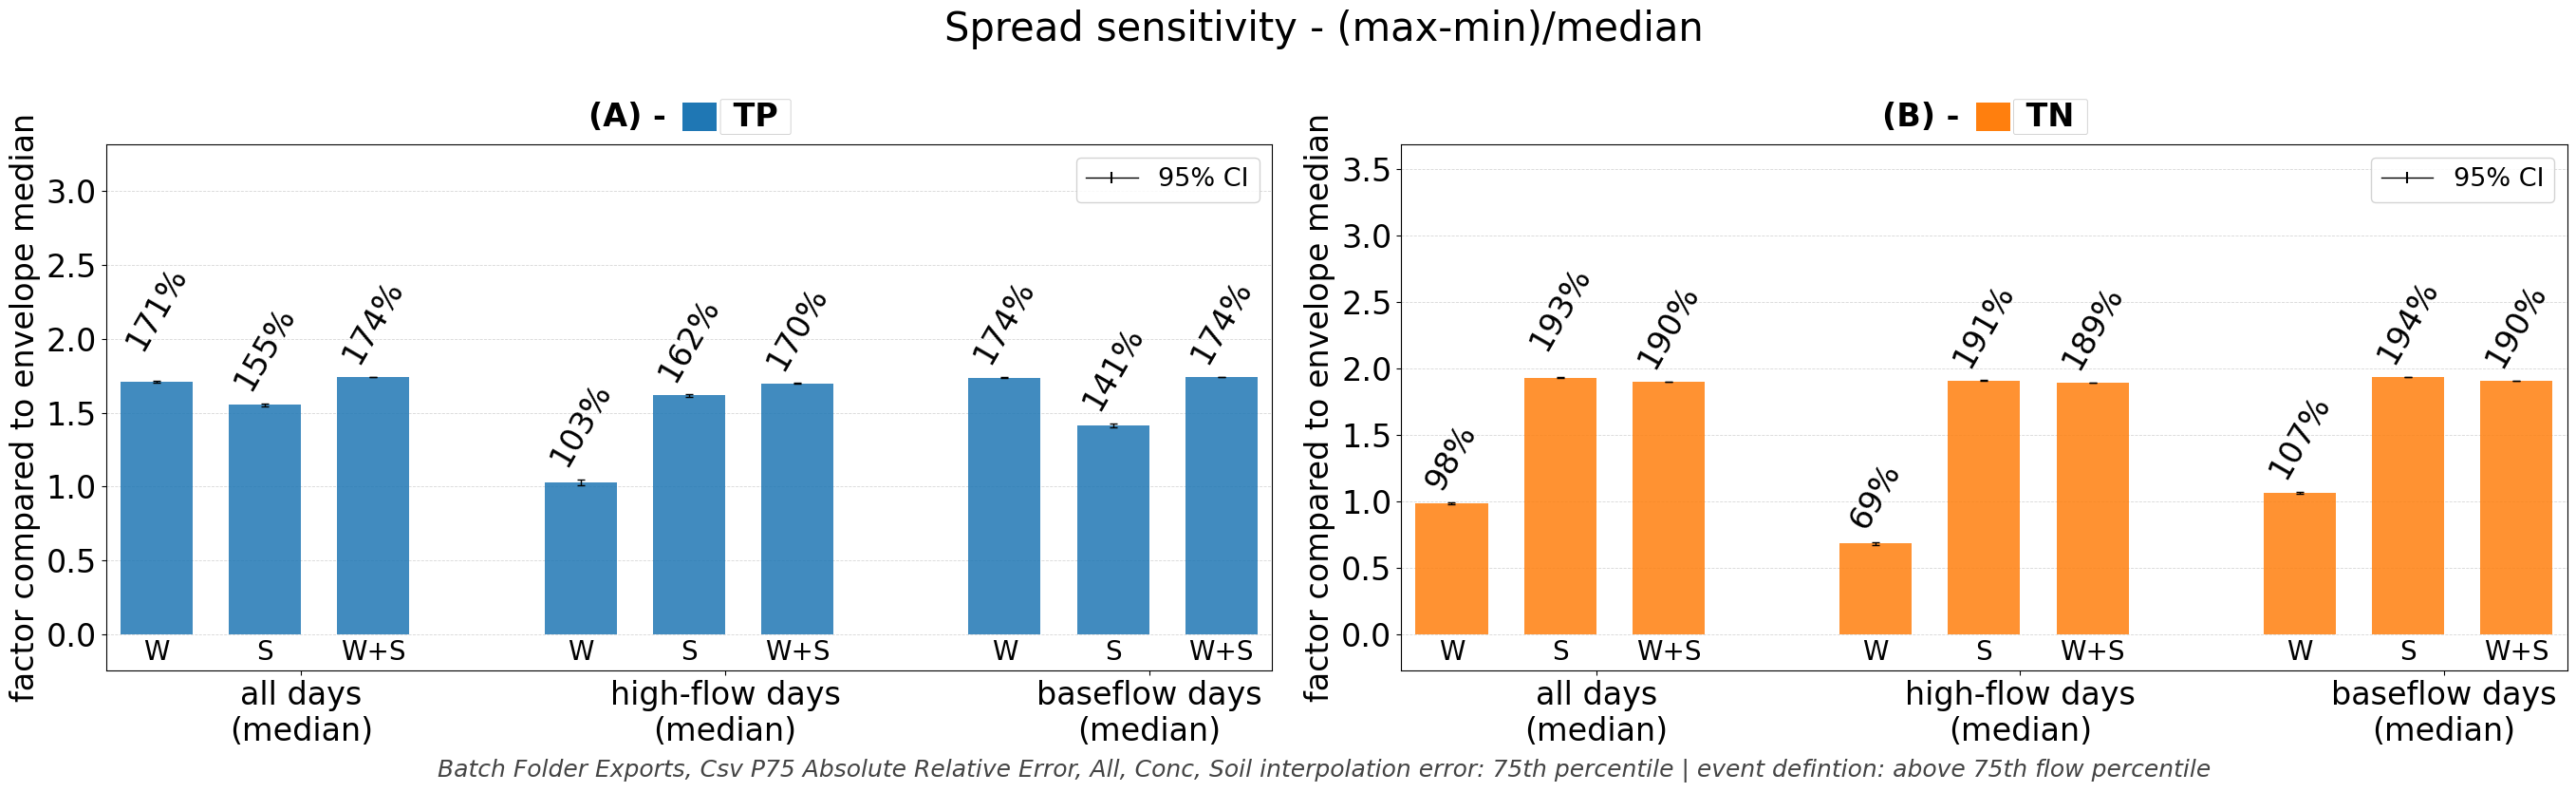


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Spread sensitivity - (max-min)/median
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Median (max-min/median) (all days),scenario,WASTE / TP,SOIL / TP,+0.157,+10.1%,1.71,1.55,0.5,0.579,14245,14234,24.58,0.0000,***,0.29,+0.145,+0.17
1,Median (max-min/median) (all days),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0309,-1.8%,1.71,1.74,0.5,0.0584,14245,14245,-7.34,0.0000,***,-0.09,-0.0392,-0.0227
2,Median (max-min/median) (all days),scenario,SOIL / TP,WASTE+SOIL / TP,-0.188,-10.8%,1.55,1.74,0.579,0.0584,14234,14245,-38.65,0.0000,***,-0.46,-0.198,-0.179
3,Median (max-min/median) (all days),scenario,WASTE / TN,SOIL / TN,-0.948,-49.1%,0.983,1.93,0.361,0.0803,14245,14234,-306.40,0.0000,***,-3.63,-0.954,-0.942
4,Median (max-min/median) (all days),scenario,WASTE / TN,WASTE+SOIL / TN,-0.918,-48.3%,0.983,1.9,0.361,0.0695,14245,14245,-298.45,0.0000,***,-3.54,-0.924,-0.912
5,Median (max-min/median) (all days),scenario,SOIL / TN,WASTE+SOIL / TN,+0.0301,+1.6%,1.93,1.9,0.0803,0.0695,14234,14245,33.84,0.0000,***,0.40,+0.0284,+0.0319
6,Median (max-min/median) (all days),variable,WASTE / TP,WASTE / TN,+0.726,+73.8%,1.71,0.983,0.5,0.361,14245,14245,140.58,0.0000,***,1.67,+0.716,+0.736
7,Median (max-min/median) (all days),variable,SOIL / TP,SOIL / TN,-0.38,-19.7%,1.55,1.93,0.579,0.0803,14234,14234,-77.59,0.0000,***,-0.92,-0.39,-0.37
8,Median (max-min/median) (all days),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-0.161,-8.5%,1.74,1.9,0.0584,0.0695,14245,14245,-212.29,0.0000,***,-2.52,-0.163,-0.16
9,Median (max-min/median) (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.588,-36.4%,1.03,1.62,0.629,0.247,3930,3919,-54.49,0.0000,***,-1.23,-0.609,-0.567


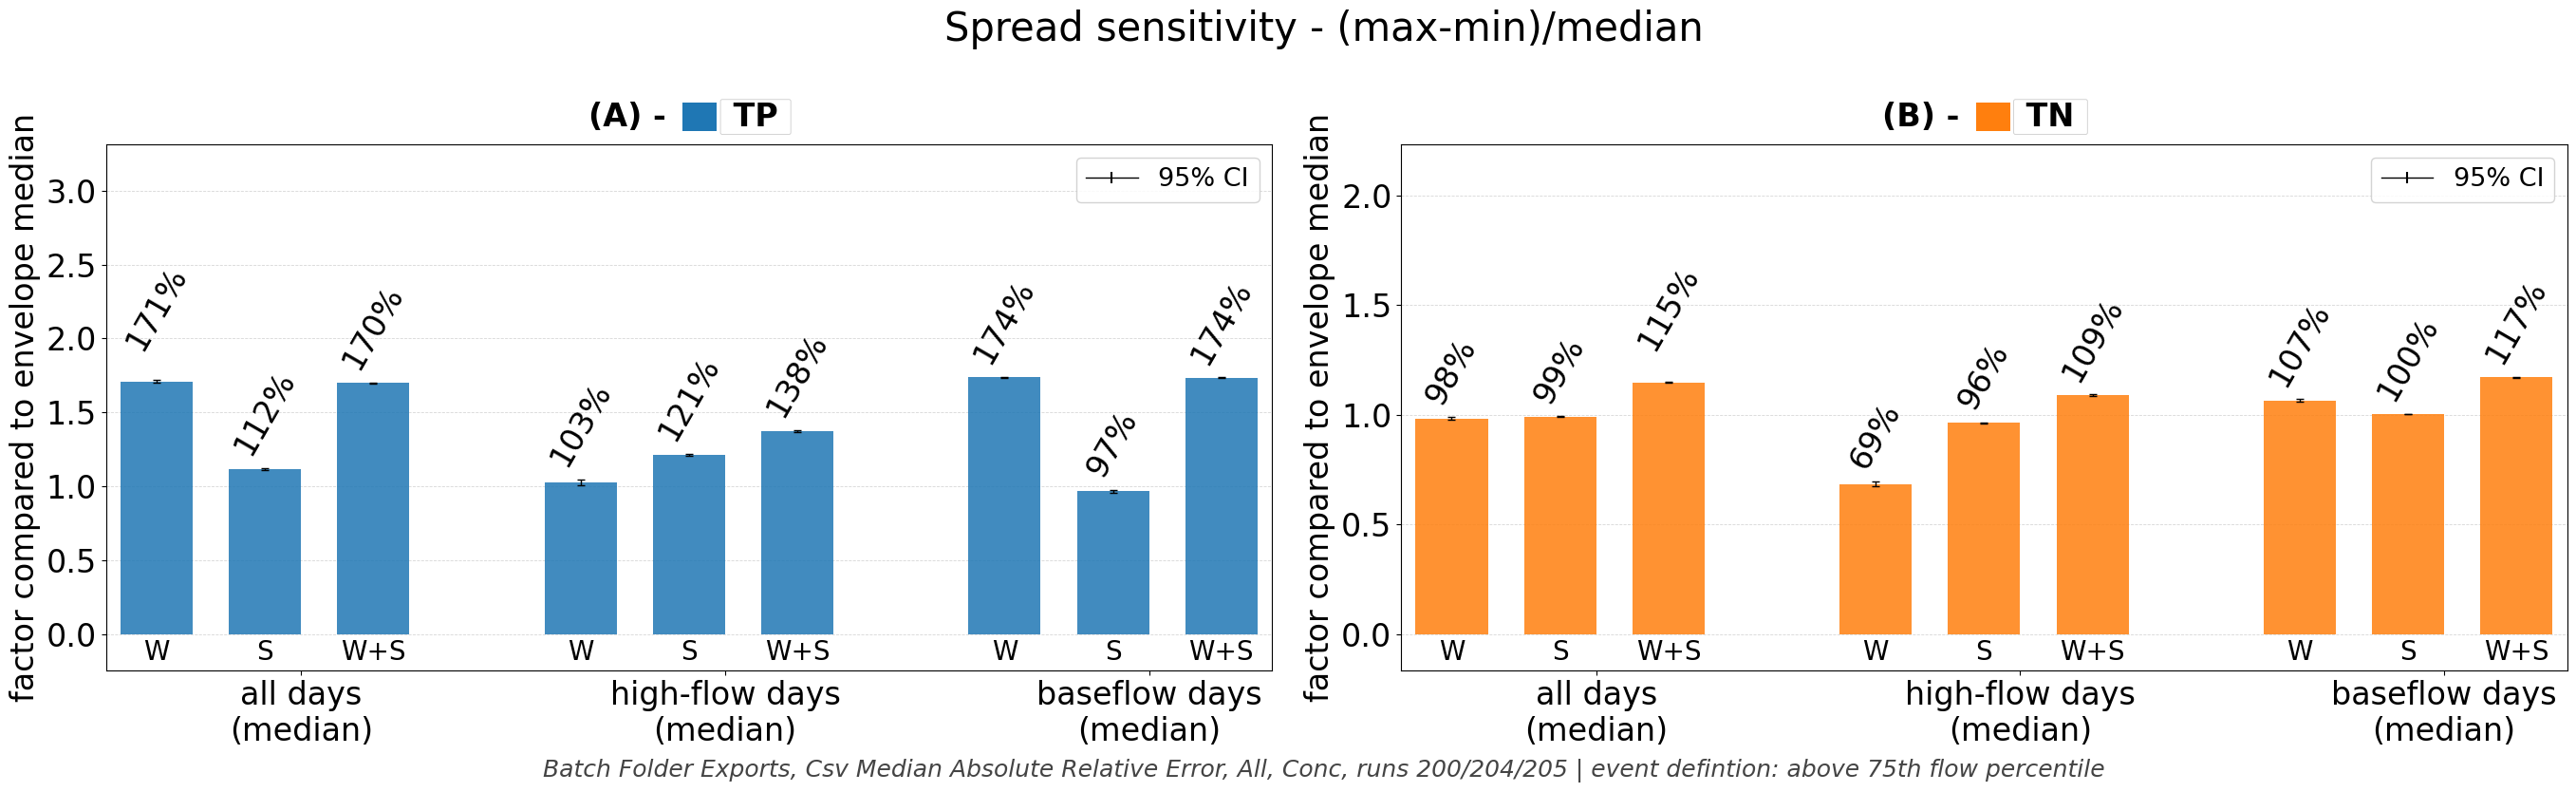


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Spread sensitivity - (max-min)/median
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Conc, runs 200/204/205 | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Median (max-min/median) (all days),scenario,WASTE / TP,SOIL / TP,+0.59,+52.8%,1.71,1.12,0.5,0.446,14245,14234,105.16,0.0000,***,1.25,+0.579,+0.601
1,Median (max-min/median) (all days),scenario,WASTE / TP,WASTE+SOIL / TP,+0.0101,+0.6%,1.71,1.7,0.5,0.183,14245,14245,2.27,0.0232,*,0.03,+0.00138,+0.0189
2,Median (max-min/median) (all days),scenario,SOIL / TP,WASTE+SOIL / TP,-0.58,-34.1%,1.12,1.7,0.446,0.183,14234,14245,-143.52,0.0000,***,-1.70,-0.588,-0.572
3,Median (max-min/median) (all days),scenario,WASTE / TN,SOIL / TN,-0.00901,-0.9%,0.983,0.992,0.361,0.0819,14245,14234,-2.91,0.0036,**,-0.03,-0.0151,-0.00293
4,Median (max-min/median) (all days),scenario,WASTE / TN,WASTE+SOIL / TN,-0.164,-14.3%,0.983,1.15,0.361,0.127,14245,14245,-51.17,0.0000,***,-0.61,-0.17,-0.158
5,Median (max-min/median) (all days),scenario,SOIL / TN,WASTE+SOIL / TN,-0.155,-13.5%,0.992,1.15,0.0819,0.127,14234,14245,-122.16,0.0000,***,-1.45,-0.157,-0.152
6,Median (max-min/median) (all days),variable,WASTE / TP,WASTE / TN,+0.726,+73.8%,1.71,0.983,0.5,0.361,14245,14245,140.58,0.0000,***,1.67,+0.716,+0.736
7,Median (max-min/median) (all days),variable,SOIL / TP,SOIL / TN,+0.126,+12.7%,1.12,0.992,0.446,0.0819,14234,14234,33.28,0.0000,***,0.39,+0.119,+0.134
8,Median (max-min/median) (all days),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.552,+48.1%,1.7,1.15,0.183,0.127,14245,14245,294.99,0.0000,***,3.50,+0.548,+0.555
9,Median (max-min/median) (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.186,-15.3%,1.03,1.21,0.629,0.209,3930,3925,-17.61,0.0000,***,-0.40,-0.207,-0.166


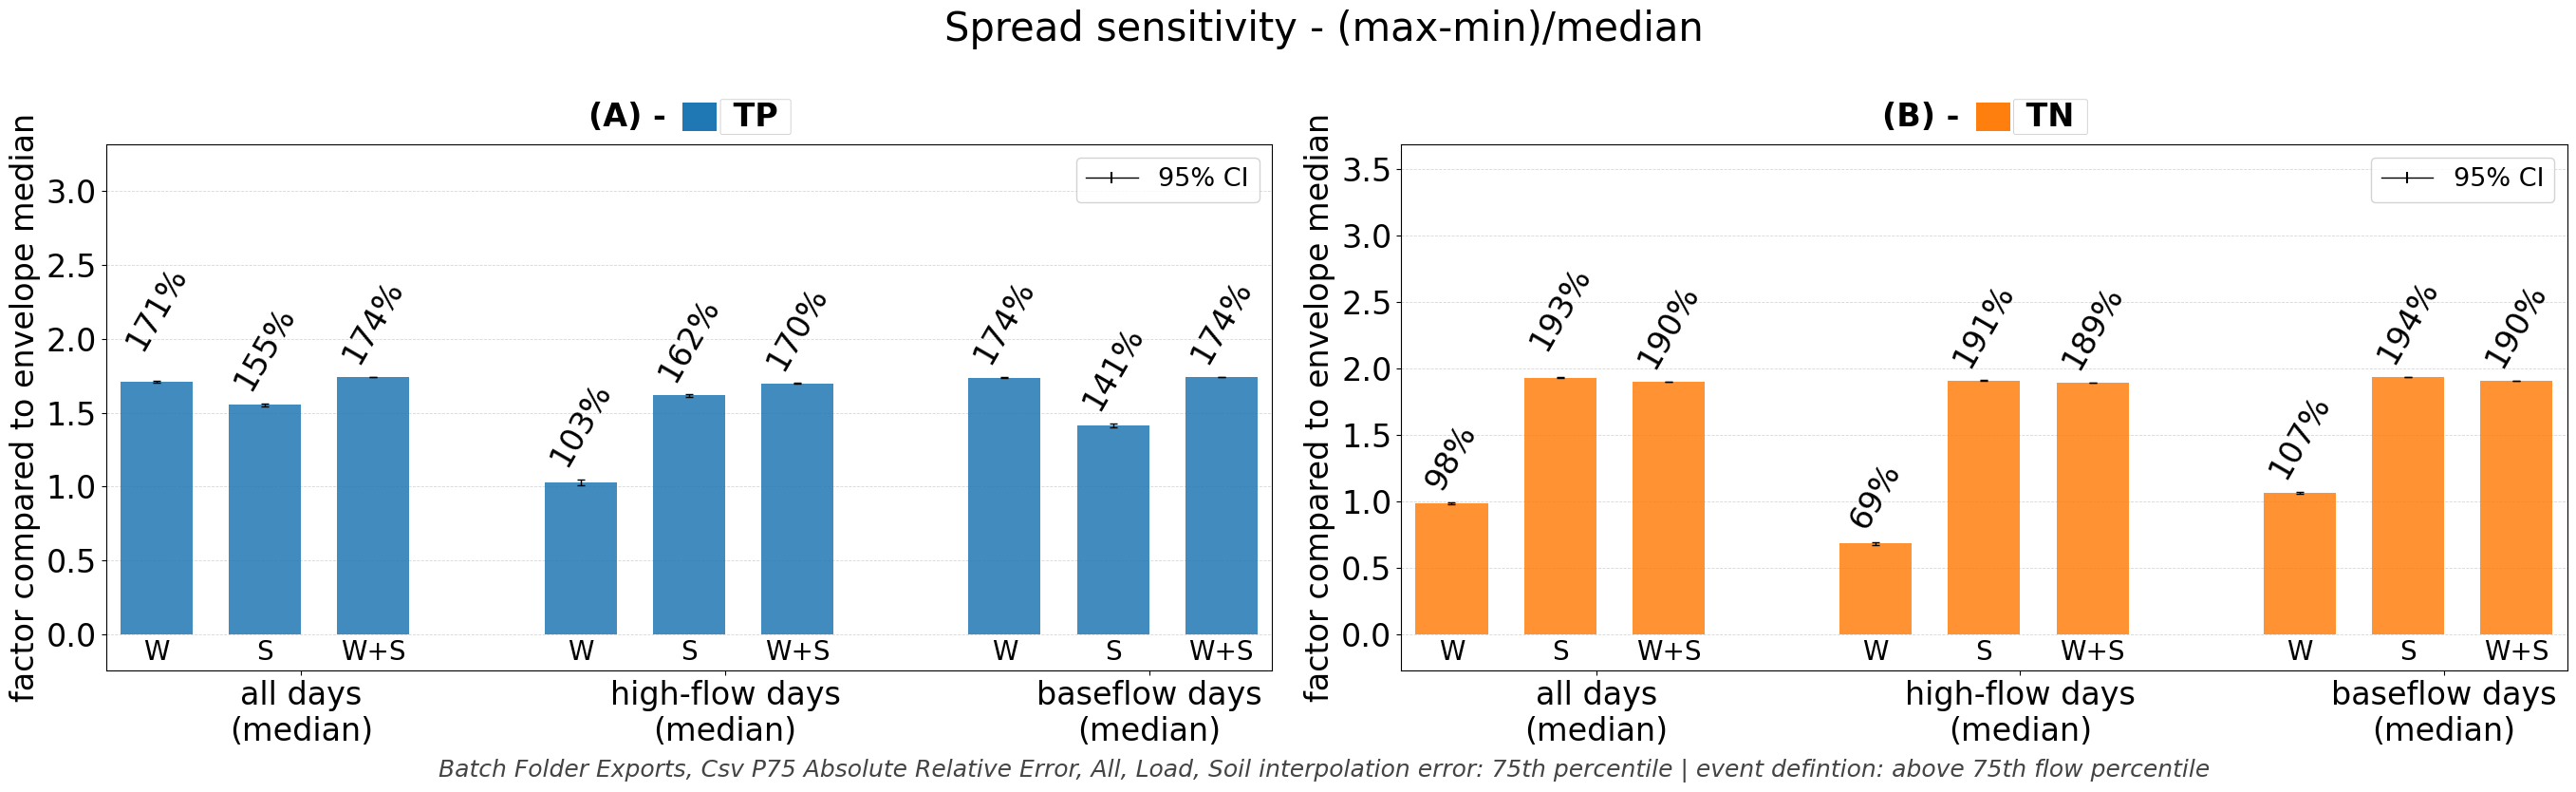


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Spread sensitivity - (max-min)/median
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Median (max-min/median) (all days),scenario,WASTE / TP,SOIL / TP,+0.157,+10.1%,1.71,1.55,0.5,0.579,14245,14234,24.58,0.0000,***,0.29,+0.145,+0.17
1,Median (max-min/median) (all days),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0309,-1.8%,1.71,1.74,0.5,0.0584,14245,14245,-7.34,0.0000,***,-0.09,-0.0392,-0.0227
2,Median (max-min/median) (all days),scenario,SOIL / TP,WASTE+SOIL / TP,-0.188,-10.8%,1.55,1.74,0.579,0.0584,14234,14245,-38.65,0.0000,***,-0.46,-0.198,-0.179
3,Median (max-min/median) (all days),scenario,WASTE / TN,SOIL / TN,-0.948,-49.1%,0.983,1.93,0.361,0.0803,14245,14234,-306.40,0.0000,***,-3.63,-0.954,-0.942
4,Median (max-min/median) (all days),scenario,WASTE / TN,WASTE+SOIL / TN,-0.918,-48.3%,0.983,1.9,0.361,0.0695,14245,14245,-298.45,0.0000,***,-3.54,-0.924,-0.912
5,Median (max-min/median) (all days),scenario,SOIL / TN,WASTE+SOIL / TN,+0.0301,+1.6%,1.93,1.9,0.0803,0.0695,14234,14245,33.84,0.0000,***,0.40,+0.0284,+0.0319
6,Median (max-min/median) (all days),variable,WASTE / TP,WASTE / TN,+0.726,+73.8%,1.71,0.983,0.5,0.361,14245,14245,140.58,0.0000,***,1.67,+0.716,+0.736
7,Median (max-min/median) (all days),variable,SOIL / TP,SOIL / TN,-0.38,-19.7%,1.55,1.93,0.579,0.0803,14234,14234,-77.59,0.0000,***,-0.92,-0.39,-0.37
8,Median (max-min/median) (all days),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-0.161,-8.5%,1.74,1.9,0.0584,0.0695,14245,14245,-212.29,0.0000,***,-2.52,-0.163,-0.16
9,Median (max-min/median) (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.588,-36.4%,1.03,1.62,0.629,0.247,3930,3919,-54.49,0.0000,***,-1.23,-0.609,-0.567


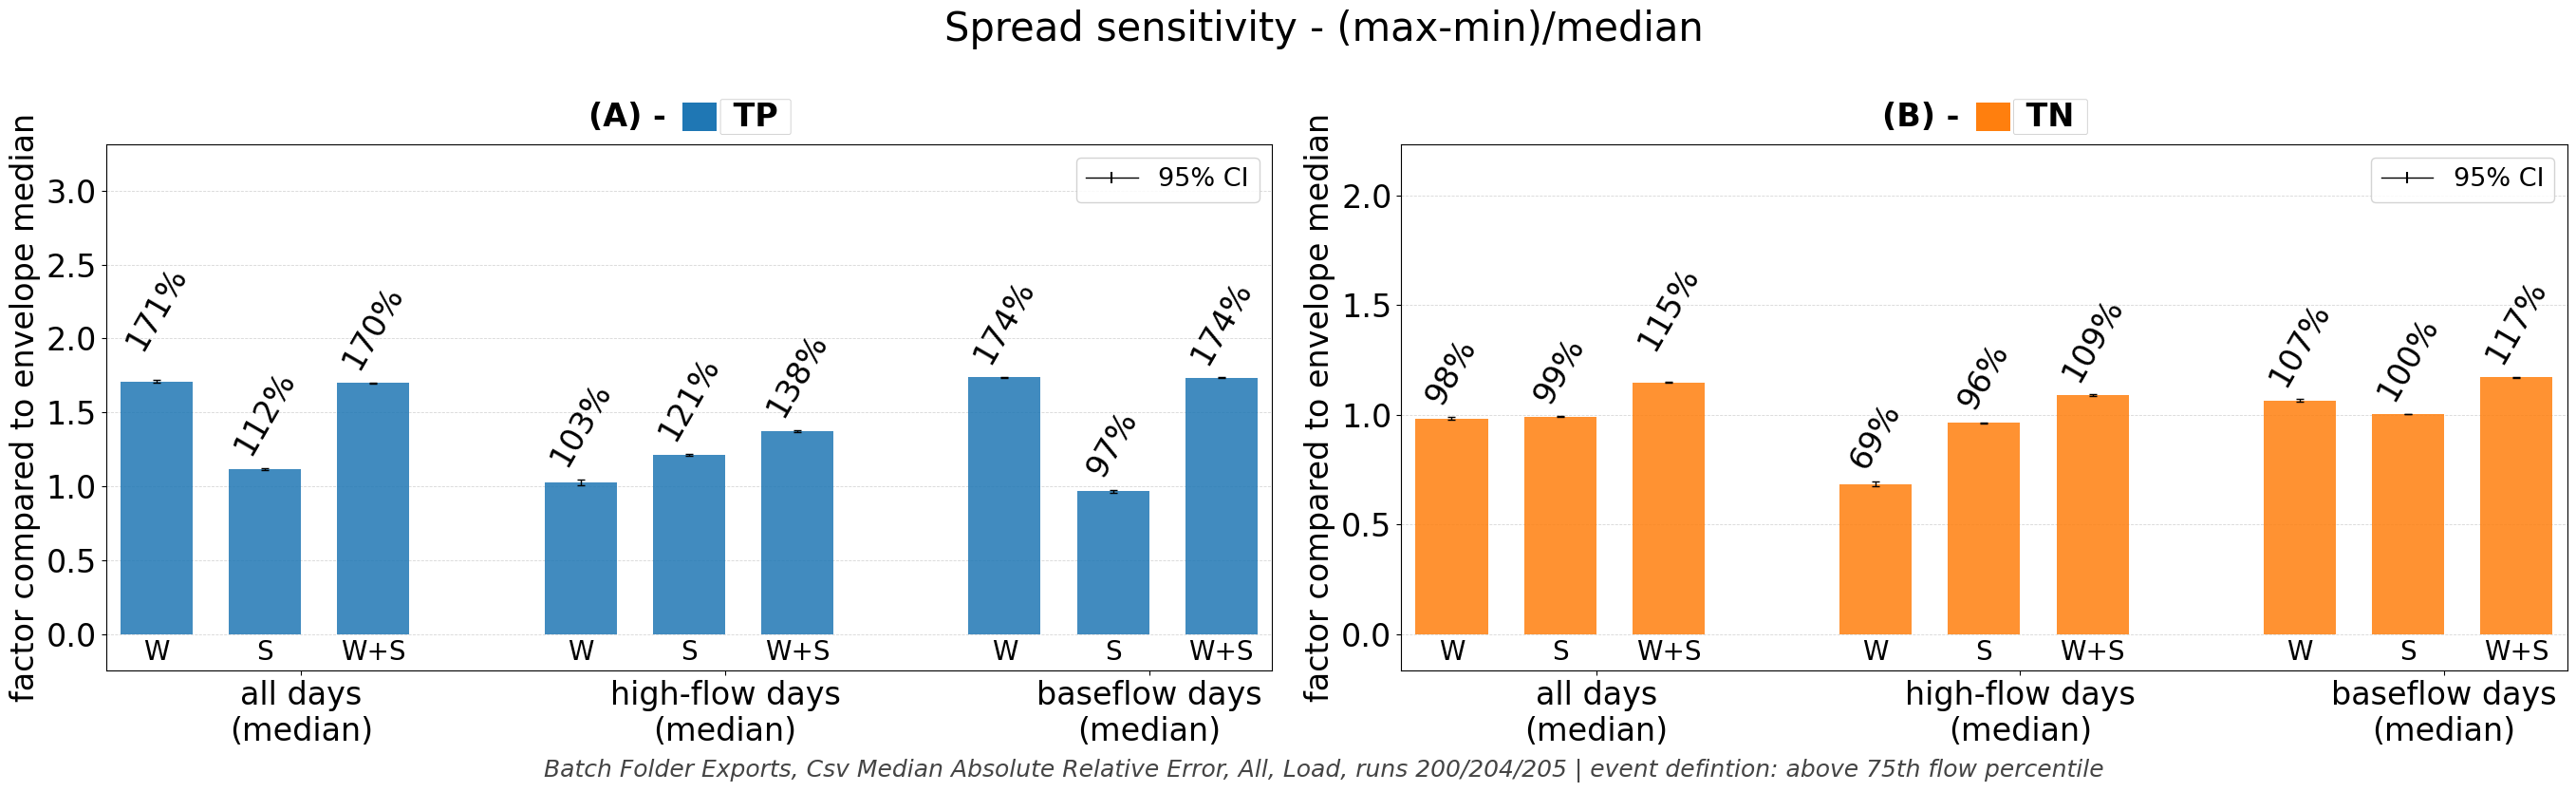


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Spread sensitivity - (max-min)/median
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Load, runs 200/204/205 | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Median (max-min/median) (all days),scenario,WASTE / TP,SOIL / TP,+0.59,+52.8%,1.71,1.12,0.5,0.446,14245,14234,105.16,0.0000,***,1.25,+0.579,+0.601
1,Median (max-min/median) (all days),scenario,WASTE / TP,WASTE+SOIL / TP,+0.0101,+0.6%,1.71,1.7,0.5,0.183,14245,14245,2.27,0.0232,*,0.03,+0.00138,+0.0189
2,Median (max-min/median) (all days),scenario,SOIL / TP,WASTE+SOIL / TP,-0.58,-34.1%,1.12,1.7,0.446,0.183,14234,14245,-143.52,0.0000,***,-1.70,-0.588,-0.572
3,Median (max-min/median) (all days),scenario,WASTE / TN,SOIL / TN,-0.00901,-0.9%,0.983,0.992,0.361,0.0819,14245,14234,-2.91,0.0036,**,-0.03,-0.0151,-0.00293
4,Median (max-min/median) (all days),scenario,WASTE / TN,WASTE+SOIL / TN,-0.164,-14.3%,0.983,1.15,0.361,0.127,14245,14245,-51.17,0.0000,***,-0.61,-0.17,-0.158
5,Median (max-min/median) (all days),scenario,SOIL / TN,WASTE+SOIL / TN,-0.155,-13.5%,0.992,1.15,0.0819,0.127,14234,14245,-122.16,0.0000,***,-1.45,-0.157,-0.152
6,Median (max-min/median) (all days),variable,WASTE / TP,WASTE / TN,+0.726,+73.8%,1.71,0.983,0.5,0.361,14245,14245,140.58,0.0000,***,1.67,+0.716,+0.736
7,Median (max-min/median) (all days),variable,SOIL / TP,SOIL / TN,+0.126,+12.7%,1.12,0.992,0.446,0.0819,14234,14234,33.28,0.0000,***,0.39,+0.119,+0.134
8,Median (max-min/median) (all days),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.552,+48.1%,1.7,1.15,0.183,0.127,14245,14245,294.99,0.0000,***,3.50,+0.548,+0.555
9,Median (max-min/median) (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.186,-15.3%,1.03,1.21,0.629,0.209,3930,3925,-17.61,0.0000,***,-0.40,-0.207,-0.166


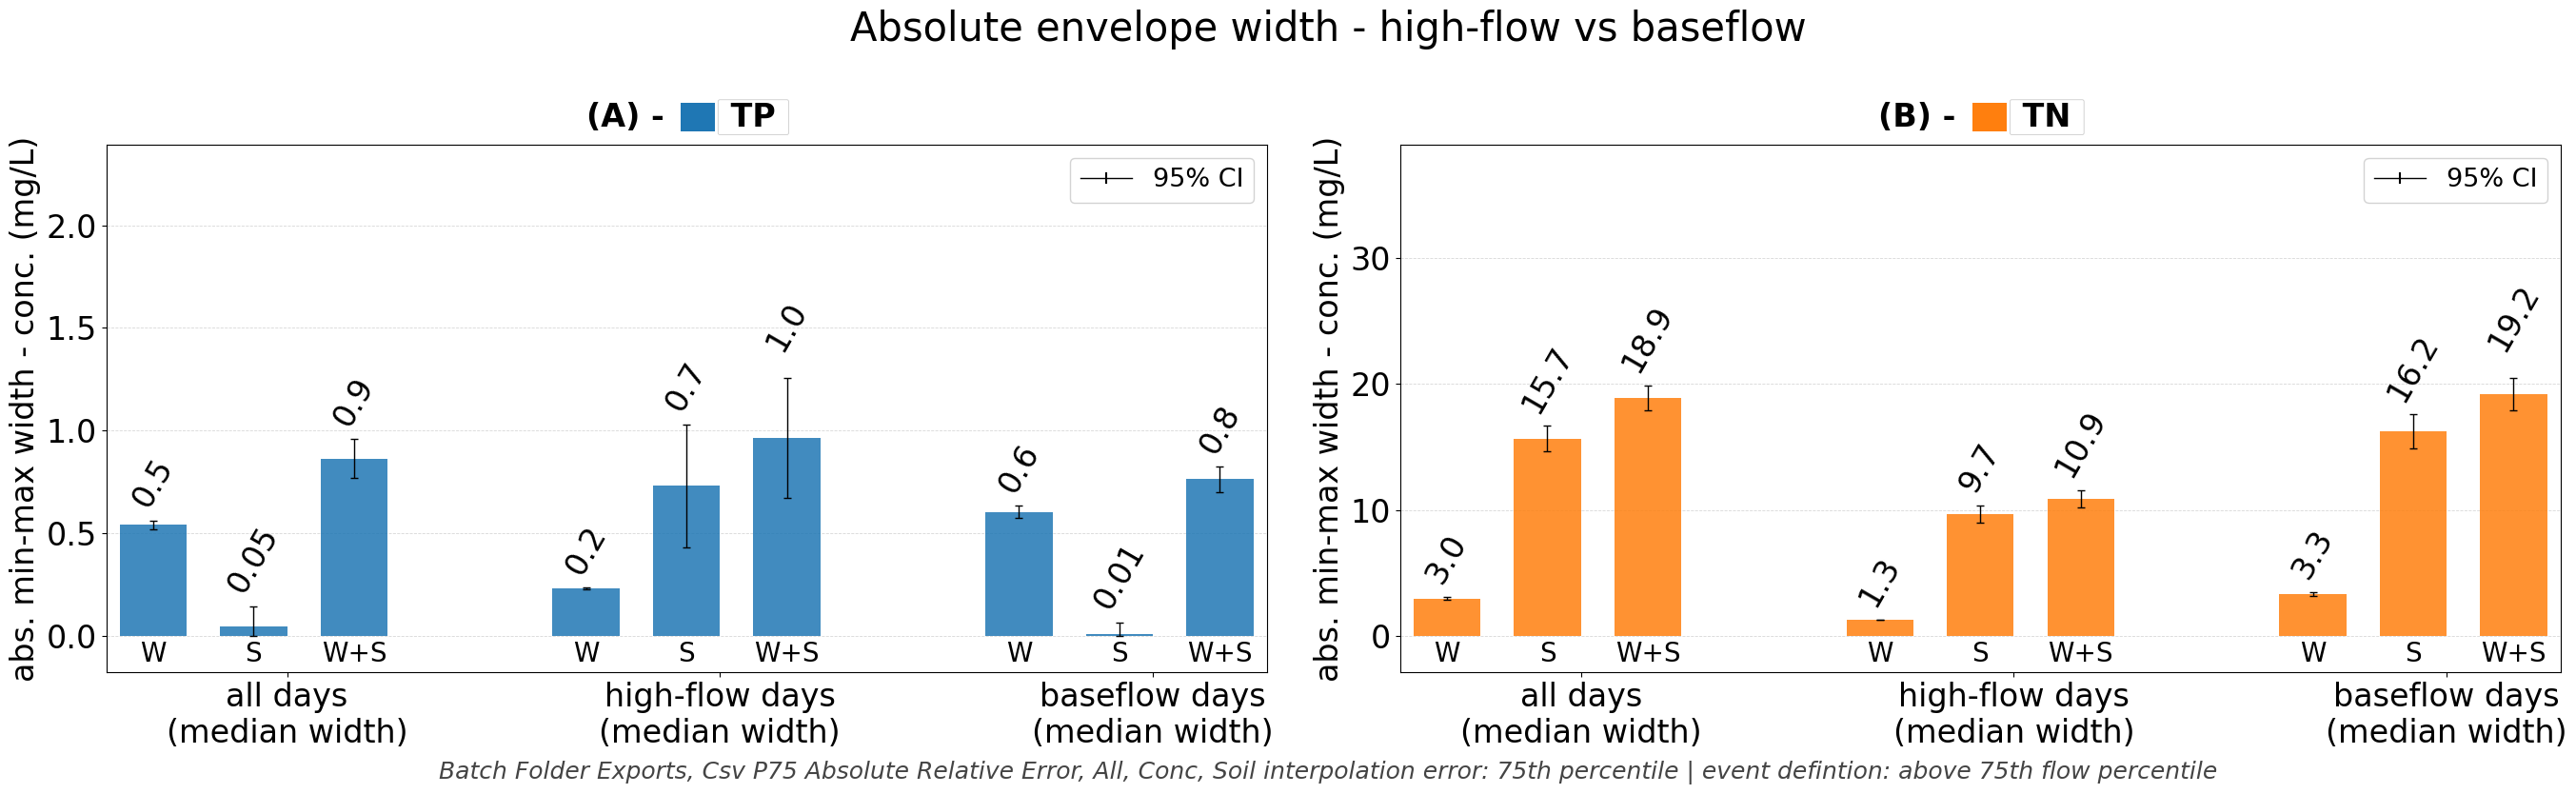


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Absolute envelope width - high-flow vs baseflow
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Model raw width median (W),scenario,WASTE / TP,SOIL / TP,+0.492,+1007.1%,0.541,0.0489,1.36,5.81,14245,14234,9.85,0.0000,***,0.12,+0.394,+0.59
1,Model raw width median (W),scenario,WASTE / TP,WASTE+SOIL / TP,-0.323,-37.4%,0.541,0.864,1.36,5.77,14245,14245,-6.51,0.0000,***,-0.08,-0.421,-0.226
2,Model raw width median (W),scenario,SOIL / TP,WASTE+SOIL / TP,-0.815,-94.3%,0.0489,0.864,5.81,5.77,14234,14245,-11.89,0.0000,***,-0.14,-0.95,-0.681
3,Model raw width median (W),scenario,WASTE / TN,SOIL / TN,-12.7,-81.0%,2.98,15.7,7.51,61.5,14245,14234,-24.43,0.0000,***,-0.29,-13.7,-11.7
4,Model raw width median (W),scenario,WASTE / TN,WASTE+SOIL / TN,-15.9,-84.3%,2.98,18.9,7.51,58.7,14245,14245,-32.10,0.0000,***,-0.38,-16.9,-15
5,Model raw width median (W),scenario,SOIL / TN,WASTE+SOIL / TN,-3.24,-17.1%,15.7,18.9,61.5,58.7,14234,14245,-4.55,0.0000,***,-0.05,-4.64,-1.84
6,Model raw width median (W),variable,WASTE / TP,WASTE / TN,-2.44,-81.8%,0.541,2.98,1.36,7.51,14245,14245,-38.10,0.0000,***,-0.45,-2.56,-2.31
7,Model raw width median (W),variable,SOIL / TP,SOIL / TN,-15.6,-99.7%,0.0489,15.7,5.81,61.5,14234,14234,-30.16,0.0000,***,-0.36,-16.6,-14.6
8,Model raw width median (W),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-18,-95.4%,0.864,18.9,5.77,58.7,14245,14245,-36.48,0.0000,***,-0.43,-19,-17.1
9,Ensemble median W (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.5,-68.3%,0.232,0.732,0.089,9.54,3930,3919,-3.28,0.0010,**,-0.07,-0.799,-0.201


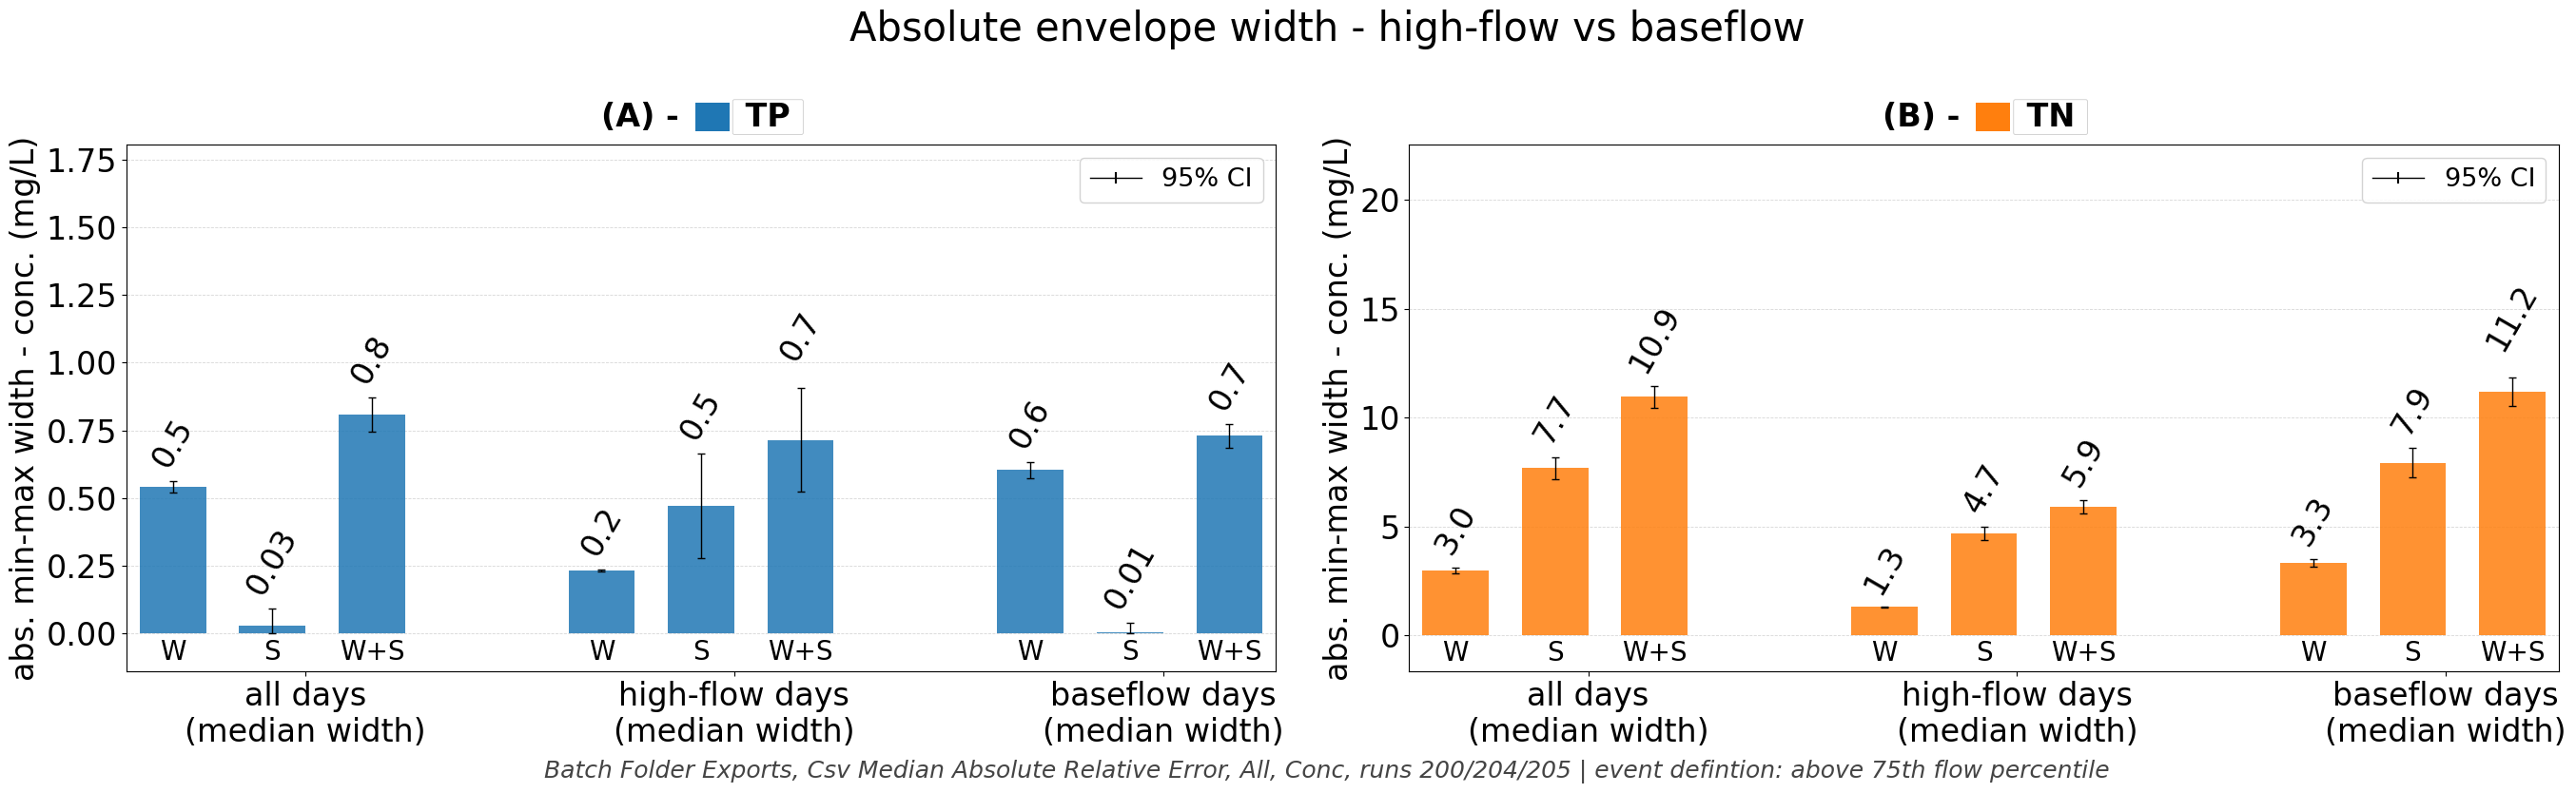


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Absolute envelope width - high-flow vs baseflow
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Conc, runs 200/204/205 | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Model raw width median (W),scenario,WASTE / TP,SOIL / TP,+0.511,+1710.5%,0.541,0.0299,1.36,3.71,14245,14234,15.42,0.0000,***,0.18,+0.446,+0.576
1,Model raw width median (W),scenario,WASTE / TP,WASTE+SOIL / TP,-0.268,-33.1%,0.541,0.809,1.36,3.85,14245,14245,-7.84,0.0000,***,-0.09,-0.335,-0.201
2,Model raw width median (W),scenario,SOIL / TP,WASTE+SOIL / TP,-0.779,-96.3%,0.0299,0.809,3.71,3.85,14234,14245,-17.38,0.0000,***,-0.21,-0.867,-0.691
3,Model raw width median (W),scenario,WASTE / TN,SOIL / TN,-4.71,-61.2%,2.98,7.68,7.51,30.3,14245,14234,-18.00,0.0000,***,-0.21,-5.22,-4.19
4,Model raw width median (W),scenario,WASTE / TN,WASTE+SOIL / TN,-7.97,-72.8%,2.98,10.9,7.51,30.8,14245,14245,-30.03,0.0000,***,-0.36,-8.49,-7.45
5,Model raw width median (W),scenario,SOIL / TN,WASTE+SOIL / TN,-3.27,-29.8%,7.68,10.9,30.3,30.8,14234,14245,-9.03,0.0000,***,-0.11,-3.97,-2.56
6,Model raw width median (W),variable,WASTE / TP,WASTE / TN,-2.44,-81.8%,0.541,2.98,1.36,7.51,14245,14245,-38.10,0.0000,***,-0.45,-2.56,-2.31
7,Model raw width median (W),variable,SOIL / TP,SOIL / TN,-7.65,-99.6%,0.0299,7.68,3.71,30.3,14234,14234,-29.93,0.0000,***,-0.35,-8.15,-7.15
8,Model raw width median (W),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-10.1,-92.6%,0.809,10.9,3.85,30.8,14245,14245,-39.02,0.0000,***,-0.46,-10.6,-9.63
9,Ensemble median W (high-flow days),scenario,WASTE / TP,SOIL / TP,-0.24,-50.8%,0.232,0.472,0.089,6.17,3930,3925,-2.43,0.0151,*,-0.05,-0.433,-0.0464


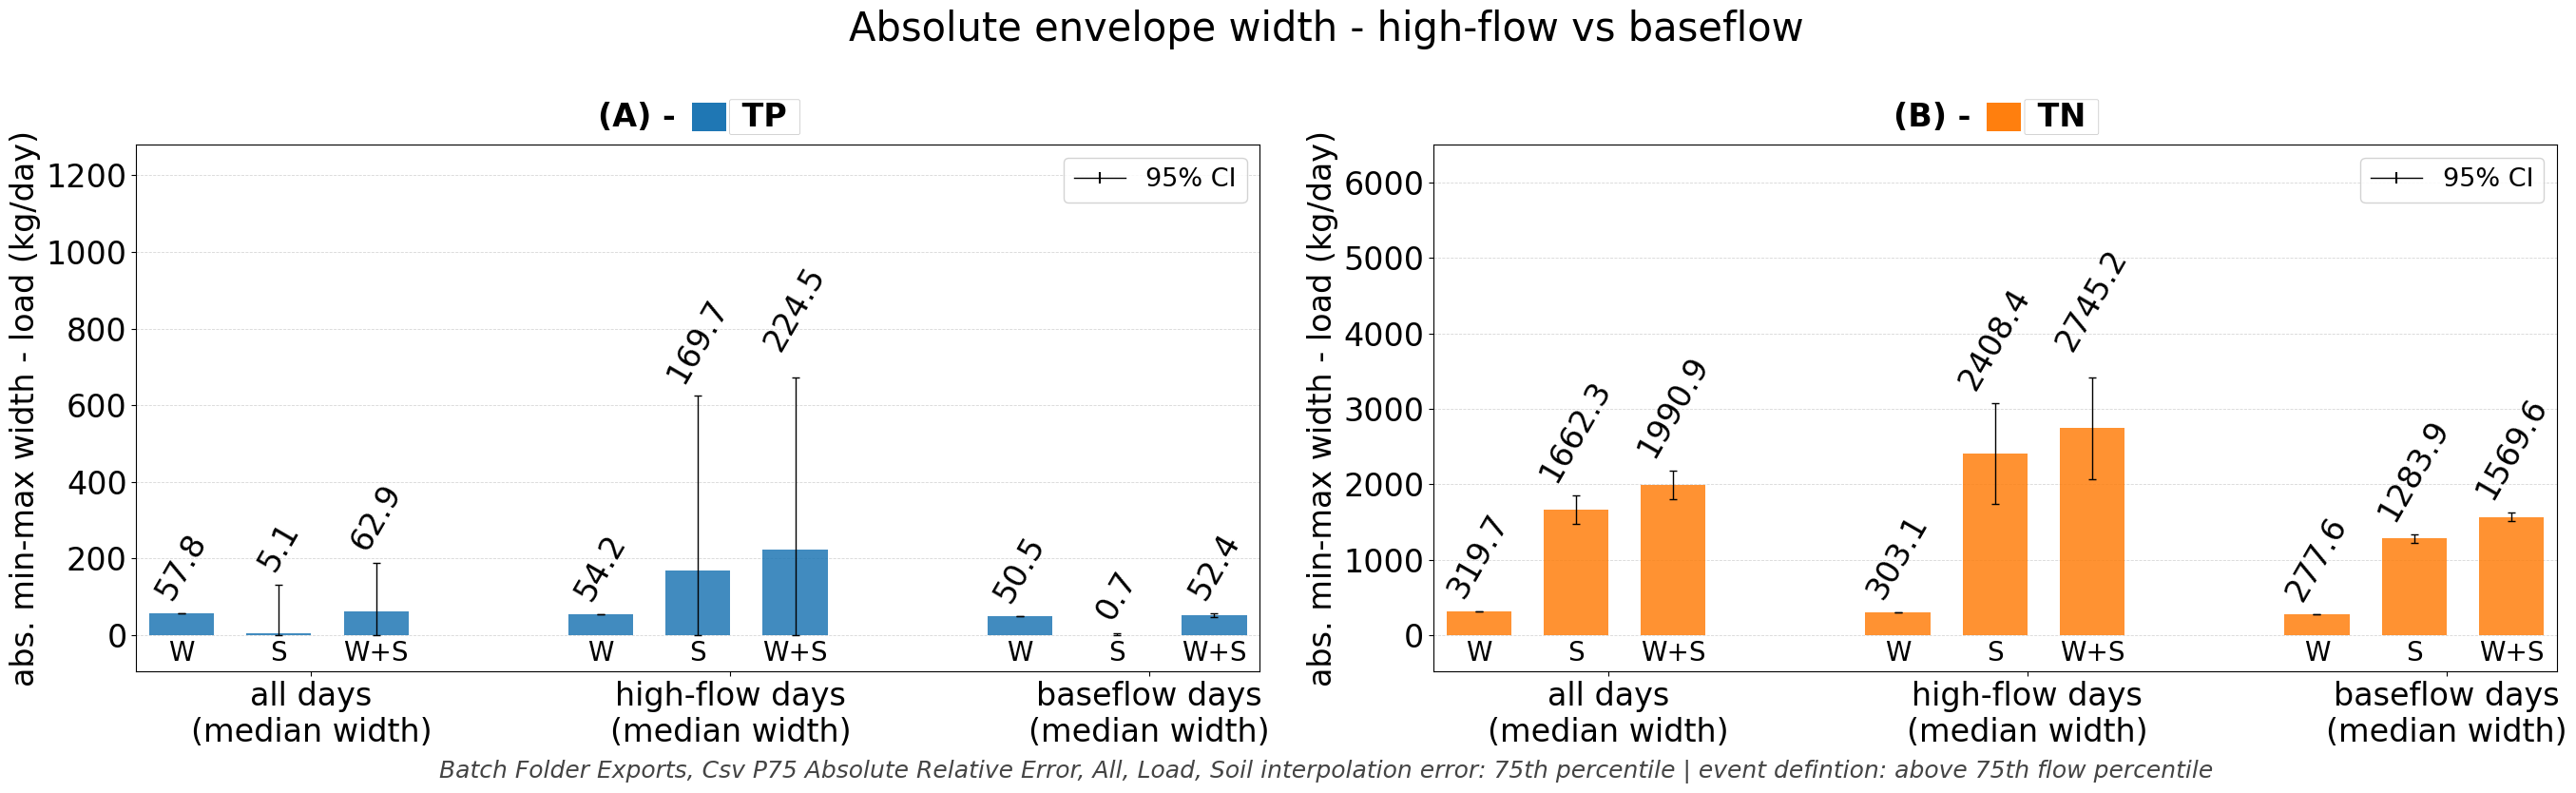


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Absolute envelope width - high-flow vs baseflow
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Model raw width median (W),scenario,WASTE / TP,SOIL / TP,+52.7,+1042.1%,57.8,5.06,6.5,7.71e+03,14245,14245,0.82,0.4142,ns,0.01,-73.9,+179
1,Model raw width median (W),scenario,WASTE / TP,WASTE+SOIL / TP,-5.05,-8.0%,57.8,62.9,6.5,7.64e+03,14245,14245,-0.08,0.9372,ns,-0.00,-131,+120
2,Model raw width median (W),scenario,SOIL / TP,WASTE+SOIL / TP,-57.8,-91.9%,5.06,62.9,7.71e+03,7.64e+03,14245,14245,-0.64,0.5252,ns,-0.01,-236,+120
3,Model raw width median (W),scenario,WASTE / TN,SOIL / TN,-1.34e+03,-80.8%,320,1.66e+03,64.4,1.16e+04,14245,14245,-13.81,0.0000,***,-0.16,-1.53e+03,-1.15e+03
4,Model raw width median (W),scenario,WASTE / TN,WASTE+SOIL / TN,-1.67e+03,-83.9%,320,1.99e+03,64.4,1.18e+04,14245,14245,-16.90,0.0000,***,-0.20,-1.87e+03,-1.48e+03
5,Model raw width median (W),scenario,SOIL / TN,WASTE+SOIL / TN,-329,-16.5%,1.66e+03,1.99e+03,1.16e+04,1.18e+04,14245,14245,-2.37,0.0178,*,-0.03,-600,-56.8
6,Model raw width median (W),variable,WASTE / TP,WASTE / TN,-262,-81.9%,57.8,320,6.5,64.4,14245,14245,-483.12,0.0000,***,-5.72,-263,-261
7,Model raw width median (W),variable,SOIL / TP,SOIL / TN,-1.66e+03,-99.7%,5.06,1.66e+03,7.71e+03,1.16e+04,14245,14245,-14.20,0.0000,***,-0.17,-1.89e+03,-1.43e+03
8,Model raw width median (W),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-1.93e+03,-96.8%,62.9,1.99e+03,7.64e+03,1.18e+04,14245,14245,-16.36,0.0000,***,-0.19,-2.16e+03,-1.7e+03
9,Ensemble median W (high-flow days),scenario,WASTE / TP,SOIL / TP,-116,-68.1%,54.2,170,6.29,1.45e+04,3930,3919,-0.50,0.6185,ns,-0.01,-570,+339


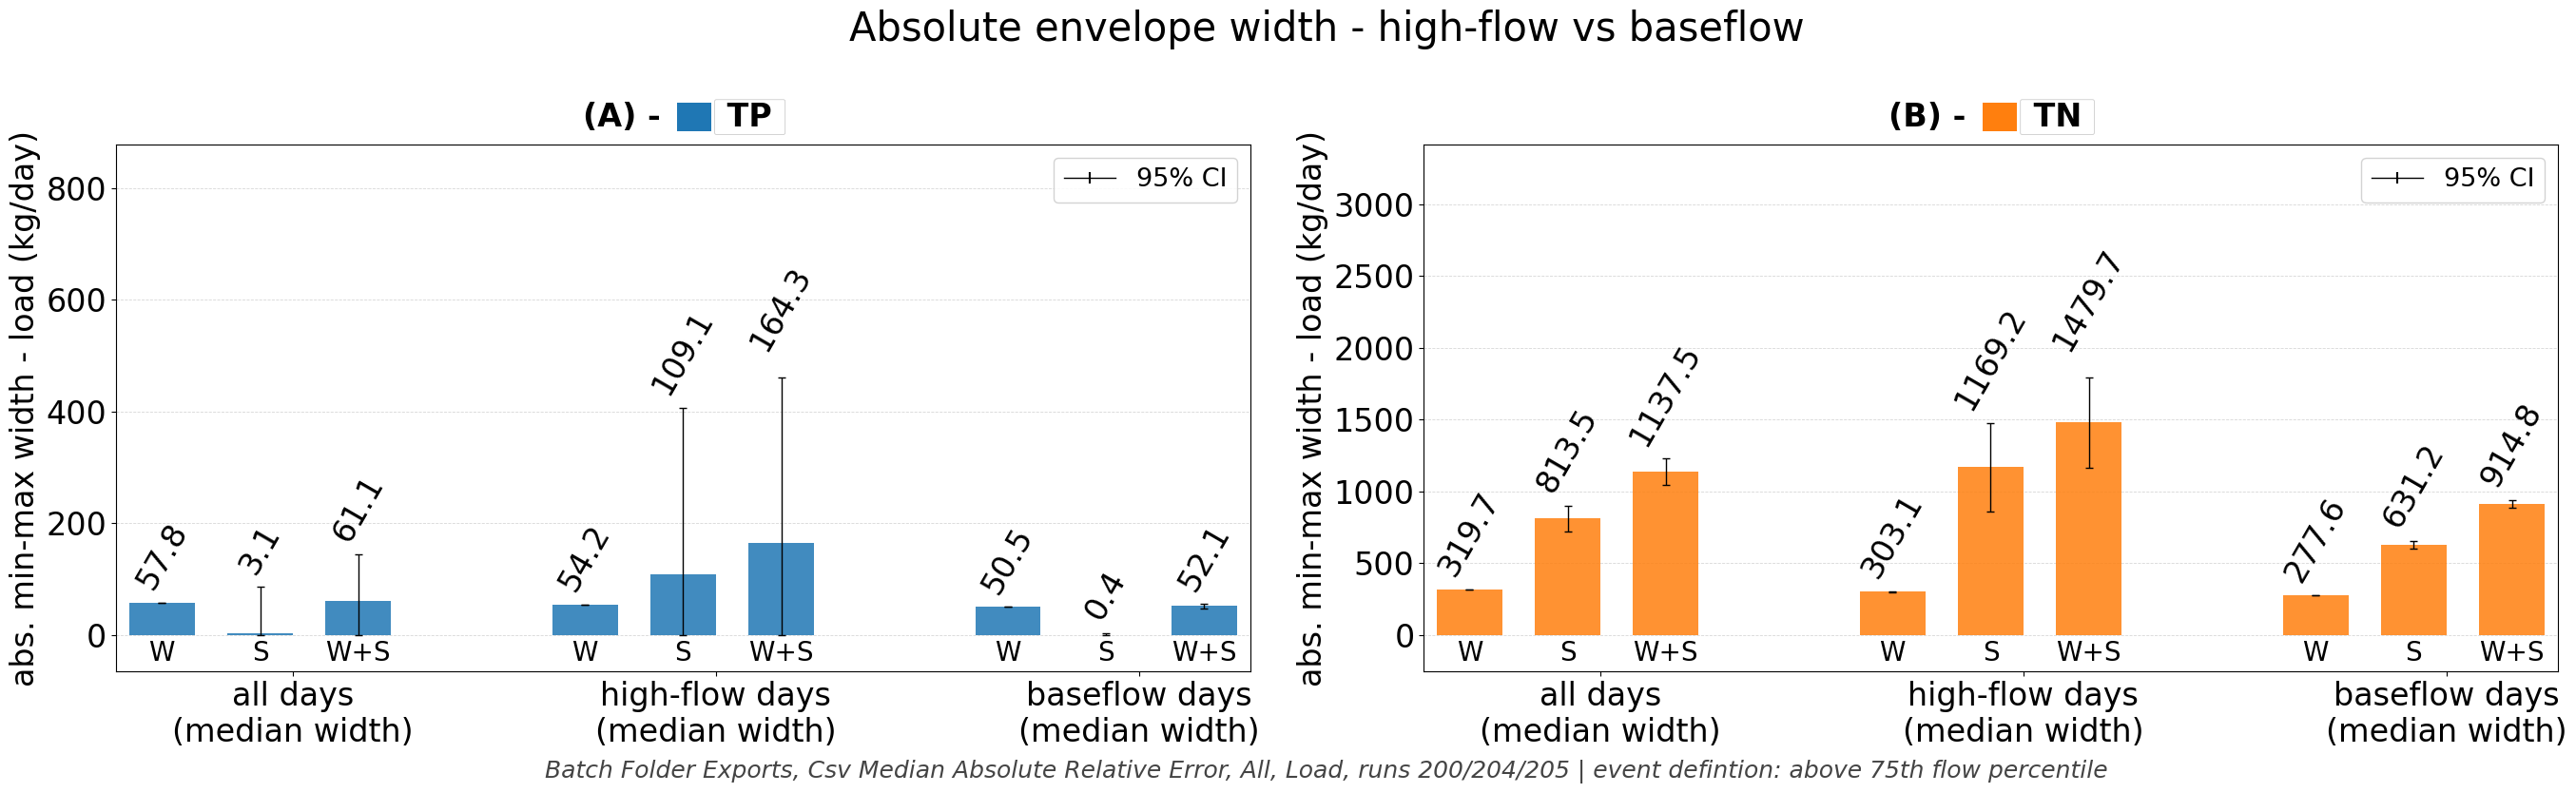


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Absolute envelope width - high-flow vs baseflow
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Load, runs 200/204/205 | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Model raw width median (W),scenario,WASTE / TP,SOIL / TP,+54.7,+1753.8%,57.8,3.12,6.5,5.06e+03,14245,14245,1.29,0.1972,ns,0.02,-28.4,+138
1,Model raw width median (W),scenario,WASTE / TP,WASTE+SOIL / TP,-3.33,-5.5%,57.8,61.1,6.5,5.06e+03,14245,14245,-0.08,0.9374,ns,-0.00,-86.5,+79.8
2,Model raw width median (W),scenario,SOIL / TP,WASTE+SOIL / TP,-58,-94.9%,3.12,61.1,5.06e+03,5.06e+03,14245,14245,-0.97,0.3334,ns,-0.01,-176,+59.5
3,Model raw width median (W),scenario,WASTE / TN,SOIL / TN,-494,-60.7%,320,814,64.4,5.41e+03,14245,14245,-10.90,0.0000,***,-0.13,-583,-405
4,Model raw width median (W),scenario,WASTE / TN,WASTE+SOIL / TN,-818,-71.9%,320,1.14e+03,64.4,5.54e+03,14245,14245,-17.61,0.0000,***,-0.21,-909,-727
5,Model raw width median (W),scenario,SOIL / TN,WASTE+SOIL / TN,-324,-28.5%,814,1.14e+03,5.41e+03,5.54e+03,14245,14245,-4.99,0.0000,***,-0.06,-451,-197
6,Model raw width median (W),variable,WASTE / TP,WASTE / TN,-262,-81.9%,57.8,320,6.5,64.4,14245,14245,-483.12,0.0000,***,-5.72,-263,-261
7,Model raw width median (W),variable,SOIL / TP,SOIL / TN,-810,-99.6%,3.12,814,5.06e+03,5.41e+03,14245,14245,-13.06,0.0000,***,-0.15,-932,-689
8,Model raw width median (W),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-1.08e+03,-94.6%,61.1,1.14e+03,5.06e+03,5.54e+03,14245,14245,-17.12,0.0000,***,-0.20,-1.2e+03,-953
9,Ensemble median W (high-flow days),scenario,WASTE / TP,SOIL / TP,-54.8,-50.3%,54.2,109,6.29,9.53e+03,3930,3925,-0.36,0.7184,ns,-0.01,-353,+243



Finished chart 1 (a/b/c/d) for all configured folders.


In [16]:
chart_1_metrics_by_folder = {}
chart_1_logs = []

# "-- Chart configuration for 4 sub-charts "----------------------------------
_chart_1_variants = [
    # {
    #     "slug": "chart_1a_relative_width_median",
    #     "labels": ch1a_semantic_labels,
    #     "descriptor": "Relative sensitivity - median((p95ˆ'p05)/p50)",
    #     "y_label": "factor compared to envelope median",
    #     "stat_label_map": {
    #         "Model relative width median((p95-p05)/p50)": "all days",
    #         "Relative width (high-flow days)": "high flow",
    #         "Relative width (baseflow days)": "baseflow",
    #         "Flow ratio (ensemble spread)": "flow ratio",
    #     },
    #     "figsize": (16, 8),
    # },

    {
        "slug": "chart_1d_maxmin_over_median",
        "labels": ch1d_semantic_labels,
        "descriptor": "Spread sensitivity - (max-min)/median",
        "y_label": "factor compared to envelope median",
        "stat_label_map": {
            "Median (max-min/median) (all days)": "all days\n(median)",
            #"Mean (max-min/median) (all days)": "mean\n(all days)",
            "Median (max-min/median) (high-flow days)": "high-flow days\n(median)",
            "Median (max-min/median) (baseflow days)": "baseflow days\n(median)",
            #"Mean (max-min/median) (high-flow days)": "mean\n(high-flow days)",
            #"Mean (max-min/median) (baseflow days)": "mean\n(baseflow days)",
        },
        "figsize": (20, 8),
    },

    {
        "slug": "chart_1b_absolute_width",
        "labels": ch1b_semantic_labels,
        "descriptor": "Absolute envelope width - high-flow vs baseflow",
        "y_label": "min-max width",
        "y_label_mode_map": {
            "conc": {"suffix": "conc.", "units": "mg/L"},
            "load": {"suffix": "load", "units": "kg/day"},
        },
        "stat_label_map": {
            "Model raw width median (W)": "all days\n(median width)",
            "Ensemble median W (high-flow days)": "high-flow days\n(median width)",
            "Ensemble median W (baseflow days)": "baseflow days\n(median width)",
            #"Absolute width flow ratio (ensemble)": "flow ratio",
        },
        "figsize": (14, 8),
    },
    # {
    #     "slug": "chart_1c_relative_width_mean",
    #     "labels": ch1c_semantic_labels,
    #     "descriptor": "Relative sensitivity" mean-based relative width",
    #     "y_label": "factor compared to envelope mean",
    #     "stat_label_map": {
    #         "Mean relative width (all days)": "all days",
    #         "Mean relative width (high-flow days)": "high-flow days",
    #         "Mean relative width (baseflow days)": "baseflow days",
    #     },
    #     "figsize": (14, 8),
    # },

]

ch_1_title_metadata_parts = [
    "folder_label",
    "event_threshold",
]

ch_1_title_folder_label_map = {
    "runs_187_200_202":      "Soil interpolation error: relative median",
    "runs_205_200_204":      "Soil interpolation error: absolute median",
    "runs_189_200_203":      "Soil interpolation error: relative RMSE",
    "runs_188_200_201":      "Soil interpolation error: 75th percentile",
    "runs_153_155_157":      "Original TFM (relative RMSE)",
    "drop_mdl":              None,
    "half_mdl":              None,
}

EVENT_THRESHOLD_TITLE_ALIASES = {
    "p50": "event defintion: above 50th flow percentile",
    "p75": "event defintion: above 75th flow percentile",
    "p90": "event defintion: above 90th flow percentile",
    "abs": "event defintion: above absolute flow value",
}

# "-- Pass 1: pre-compute specs & metrics per folder "------------------------
_ch1_folder_data = {}
_last_ch1_compare_mode = None
for batch_folder in _ch12_batch_folders:
    _ch1_compare_mode = _resolve_batch_folder_compare_mode(batch_folder)
    if _ch1_compare_mode != _last_ch1_compare_mode:
        _print_graph_group_separator(_ch1_compare_mode, chart_label='Chart 1')
        _last_ch1_compare_mode = _ch1_compare_mode
    _folder_key = str(batch_folder)
    generated_specs, build_log = _capture_stdout(
        build_export_specs_from_folder,
        batch_folder,
        run_to_scenario,
        variable_map,
        verbose=True,
    )

    _ch1_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))
    _ch1_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))
    _ch1_selected_scenarios = _ordered_present_values(_ch1_actual_scenarios, chart_scenario_order)
    _ch1_selected_variables = _ordered_present_values(_ch1_actual_variables, chart_variable_order)

    ch_1_auto_metrics = build_metrics_dict_from_stat_exports(
        generated_specs,
        ch1_semantic_labels,
        semantic_label_map=example_semantic_label_map,
        scenario_order=_ch1_selected_scenarios,
        variable_order=_ch1_selected_variables,
        format_mode="metadata",
        verbose=False,
    )

    _ch1_folder_data[_folder_key] = {
        "batch_folder": batch_folder,
        "generated_specs": generated_specs,
        "build_log": build_log,
        "selected_scenarios": _ch1_selected_scenarios,
        "selected_variables": _ch1_selected_variables,
        "auto_metrics": ch_1_auto_metrics,
    }

    chart_1_metrics_by_folder[batch_folder.name] = ch_1_auto_metrics
    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_1_metrics"] = ch_1_auto_metrics

    chart_1_logs.append(f"Chart 1 folder: {batch_folder.name}")
    chart_1_logs.append(f"  scenarios: {_ch1_selected_scenarios}")
    chart_1_logs.append(f"  variables: {_ch1_selected_variables}")
    if build_log.strip():
        chart_1_logs.append(build_log.rstrip())
    chart_1_logs.append("")

# "-- Pass 2: for each variant, render all folders "--------------------------
for variant in _chart_1_variants:
    for fname, fdata in _ch1_folder_data.items():
        batch_folder = fdata["batch_folder"]
        generated_specs = fdata["generated_specs"]
        _ch1_selected_scenarios = fdata["selected_scenarios"]
        _ch1_selected_variables = fdata["selected_variables"]
        ch_1_auto_metrics = fdata["auto_metrics"]

        variant_metrics = {
            "metrics": {
                k: v for k, v in ch_1_auto_metrics["metrics"].items()
                if k in variant["labels"]
            }
        }

        chart_title, chart_subtitle = build_semantic_chart_title(
            batch_folder, generated_specs,
            variant["descriptor"],
            title_metadata_parts=ch_1_title_metadata_parts,
            title_folder_label_map=ch_1_title_folder_label_map,
        )


        # Use stat_label_map keys for error data to improve label mapping success
        _ch1_error_metric_labels = list(variant.get("stat_label_map", {}).keys()) if "stat_label_map" in variant else variant["labels"]
        _ch1_error_data = build_error_data_from_extended_stats(
            generated_specs, _ch1_error_metric_labels,
            error_mode="ci95",
        )

        # "-- Build per-panel y-axis labels when the variant defines a mode map "-
        _ch1_per_panel_y_labels = None
        _ylm = variant.get("y_label_mode_map")
        if _ylm:
            _mode = _resolve_batch_folder_compare_mode(batch_folder)
            _mi = _ylm.get(_mode)
            if _mi:
                _ch1_per_panel_y_labels = {
                    v: f"abs. {variant['y_label']} - {_mi['suffix']} ({_mi['units']})"
                    for v in _ch1_selected_variables
                }

        fig, ax = plot_nested_sensitivity_bars(
            variant_metrics,
            variables_order=_ch1_selected_variables,
            title=chart_title,
            subtitle=chart_subtitle,
            y_label=variant["y_label"],
            small_value_threshold = 0.1,
            small_value_decimals = 2,
            figsize=variant["figsize"],
            scenarios_order=_ch1_selected_scenarios,
            stats_order=variant["labels"],
            stat_label_map=variant["stat_label_map"],
            abbreviations=chart_abbreviations,
            annotate_rotation=60,
            annot_fs=24,
            tick_fs=24,
            label_fs=24,
            title_fs=30,
            subtitle_fs=18,
            legend_fs=26,
            legend_outside=False,
            legend_loc="upper right",
            legend_bbox=(0.98, 0.98),
            tight_layout_rect=(0.0, 0.02, 0.98, 0.98),
            inside_legend_top_margin_scale=0.82,
            edge_bar_padding=0.70,
            subtitle_y=-0.0075,
            scenario_fs=20,
            scenario_label_rotation=0,
            scenario_spacing=0.06,
            bottom_margin_for_labels=0.14,
            label_offset_scale=0.03,
            label_separation_scale=0.08,
            label_x_nudge_scale=0.09,
            scenario_label_y_scale=0.02,
            split_variable_panels=chart_split_variable_panels,
            split_panel_figsize=chart_split_panel_figsize,
            split_panel_wspace=chart_split_panel_wspace,
            split_panel_suptitle_y=chart_split_panel_suptitle_y,
            split_panel_suptitle_fs=chart_split_panel_suptitle_fs,
            split_panel_variable_title=chart_split_panel_variable_title,
            split_panel_variable_title_fs=chart_split_panel_variable_title_fs,
            split_panel_variable_title_bg=chart_split_panel_variable_title_bg,
            split_panel_variable_title_pad=chart_split_panel_variable_title_pad,
            split_panel_left_y_label_only=chart_split_panel_left_y_label_only,
            split_panel_per_panel_y_labels=_ch1_per_panel_y_labels,
            split_panel_legend_panel=chart_split_panel_legend_panel,
            split_panel_legend_side=chart_split_panel_legend_side,
            split_panel_tight_rect=chart_split_panel_tight_rect,
            error_data=_ch1_error_data,
            error_bar_legend_label="95% CI",
        )
        plt.show()


        # "-- Significance table for this chart variant "--
        display_chart_significance_tables(
            variant_metrics,
            generated_specs,
            chart_title=f"Table: {chart_title}",
            chart_subtitle=chart_subtitle,
            comparison_modes=("scenarios", "variables"),
            scenarios=_ch1_selected_scenarios,
            variables=_ch1_selected_variables,
            metric_labels=variant["labels"],
        )
        saved_path, save_log = _capture_stdout(
            _save_chart_figure,
            fig,
            batch_folder.name,
            variant["slug"],
            save_enabled=save_individual_chart_images,
            output_root=saved_chart_root,
            dpi=saved_chart_dpi,
        )
        plt.close(fig)

        chart_results_by_folder.setdefault(batch_folder.name, {})[variant["slug"] + "_metrics"] = variant_metrics
        chart_results_by_folder[batch_folder.name][variant["slug"] + "_saved_path"] = saved_path

        if save_log.strip():
            chart_1_logs.append(save_log.rstrip())

print("\nFinished chart 1 (a/b/c/d) for all configured folders.")

In [17]:
# DEBUG: Check if ch1d metrics are in ch_1_auto_metrics
print("Checking Chart 1d metrics availability...")
ch1d_in_metrics = [label in ch_1_auto_metrics["metrics"] for label in ch1d_semantic_labels]
print(f"  ch1d_semantic_labels in ch_1_auto_metrics: {ch1d_in_metrics}")
if not all(ch1d_in_metrics):
    print("  WARNING: Some ch1d metrics are missing!")
    missing = [l for l in ch1d_semantic_labels if l not in ch_1_auto_metrics["metrics"]]
    print(f"  Missing: {missing}")
    print("\n  REBUILDING metrics with ch1_semantic_labels (which includes ch1d)...")
    
    # Get the first folder's data to rebuild
    if _ch1_folder_data:
        first_key = list(_ch1_folder_data.keys())[0]
        fdata = _ch1_folder_data[first_key]
        batch_folder = fdata["batch_folder"]
        generated_specs = fdata["generated_specs"]
        
        # Rebuild metrics including ch1d
        from contextlib import redirect_stdout
        import io
        buffer = io.StringIO()
        with redirect_stdout(buffer):
            ch_1_auto_metrics = build_metrics_dict_from_stat_exports(
                generated_specs,
                ch1_semantic_labels,
                semantic_label_map=example_semantic_label_map,
                scenario_order=fdata["selected_scenarios"],
                variable_order=fdata["selected_variables"],
                format_mode="metadata",
                verbose=False,
            )
        
        # Update all folder data with rebuilt metrics
        for fname, fd in _ch1_folder_data.items():
            fd["auto_metrics"] = ch_1_auto_metrics
            chart_1_metrics_by_folder[fd["batch_folder"].name] = ch_1_auto_metrics
        
        ch1d_in_metrics_after = [label in ch_1_auto_metrics["metrics"] for label in ch1d_semantic_labels]
        print(f"  After rebuild - ch1d_semantic_labels in ch_1_auto_metrics: {ch1d_in_metrics_after}")
        if all(ch1d_in_metrics_after):
            print("SUCCESS: All ch1d metrics now available!")
        else:
            print("-- STILL MISSING AFTER REBUILD - may indicate data extraction issue")
else:
    print("All ch1d metrics available!")


Checking Chart 1d metrics availability...
  ch1d_semantic_labels in ch_1_auto_metrics: [True, True, True]
All ch1d metrics available!


In [18]:
# FIX: Ensure variant metrics are properly extracted - add fallback metric extraction
def _get_or_extract_metric(batch_folder, generated_specs, semantic_labels, display_label, scenario_order, variable_order):
    """Get a metric from local cache or extract it from specs if missing."""
    # Try to get from cache first
    if display_label in ch_1_auto_metrics["metrics"]:
        return ch_1_auto_metrics["metrics"][display_label]
    
    # If not in cache, extract this specific metric
    print(f"  Extracting missing metric: '{display_label}'")
    try:
        result = build_metrics_dict_from_stat_exports(
            generated_specs,
            [display_label],  # Extract just this one label
            semantic_label_map=example_semantic_label_map,
            scenario_order=scenario_order,
            variable_order=variable_order,
            format_mode="metadata",
            verbose=False,
        )
        if display_label in result["metrics"]:
            return result["metrics"][display_label]
    except Exception as e:
        print(f"  Error extracting metric '{display_label}': {e}")
    
    # Return empty placeholder if extraction fails
    return {scenario: {var: float('nan') for var in variable_order} for scenario in scenario_order}

# Rebuild variant metrics with proper fallback
_original_ch1_auto_metrics = ch_1_auto_metrics.copy()  # Keep original

print("Verifying all variant metrics are available...")
_all_labels = set()
for variant in _chart_1_variants:
    _all_labels.update(variant["labels"])

missing_labels = [l for l in _all_labels if l not in ch_1_auto_metrics["metrics"]]
if missing_labels:
    print(f"Missing {len(missing_labels)} metrics from ch_1_auto_metrics: {missing_labels[:3]}...")
    print("  ' Will extract missing metrics on-demand during rendering")
else:
    print("All variant metrics available in ch_1_auto_metrics")


Verifying all variant metrics are available...
All variant metrics available in ch_1_auto_metrics



----------------------------------------------------------------------------------------
Chart 2: Concentration graphs
----------------------------------------------------------------------------------------


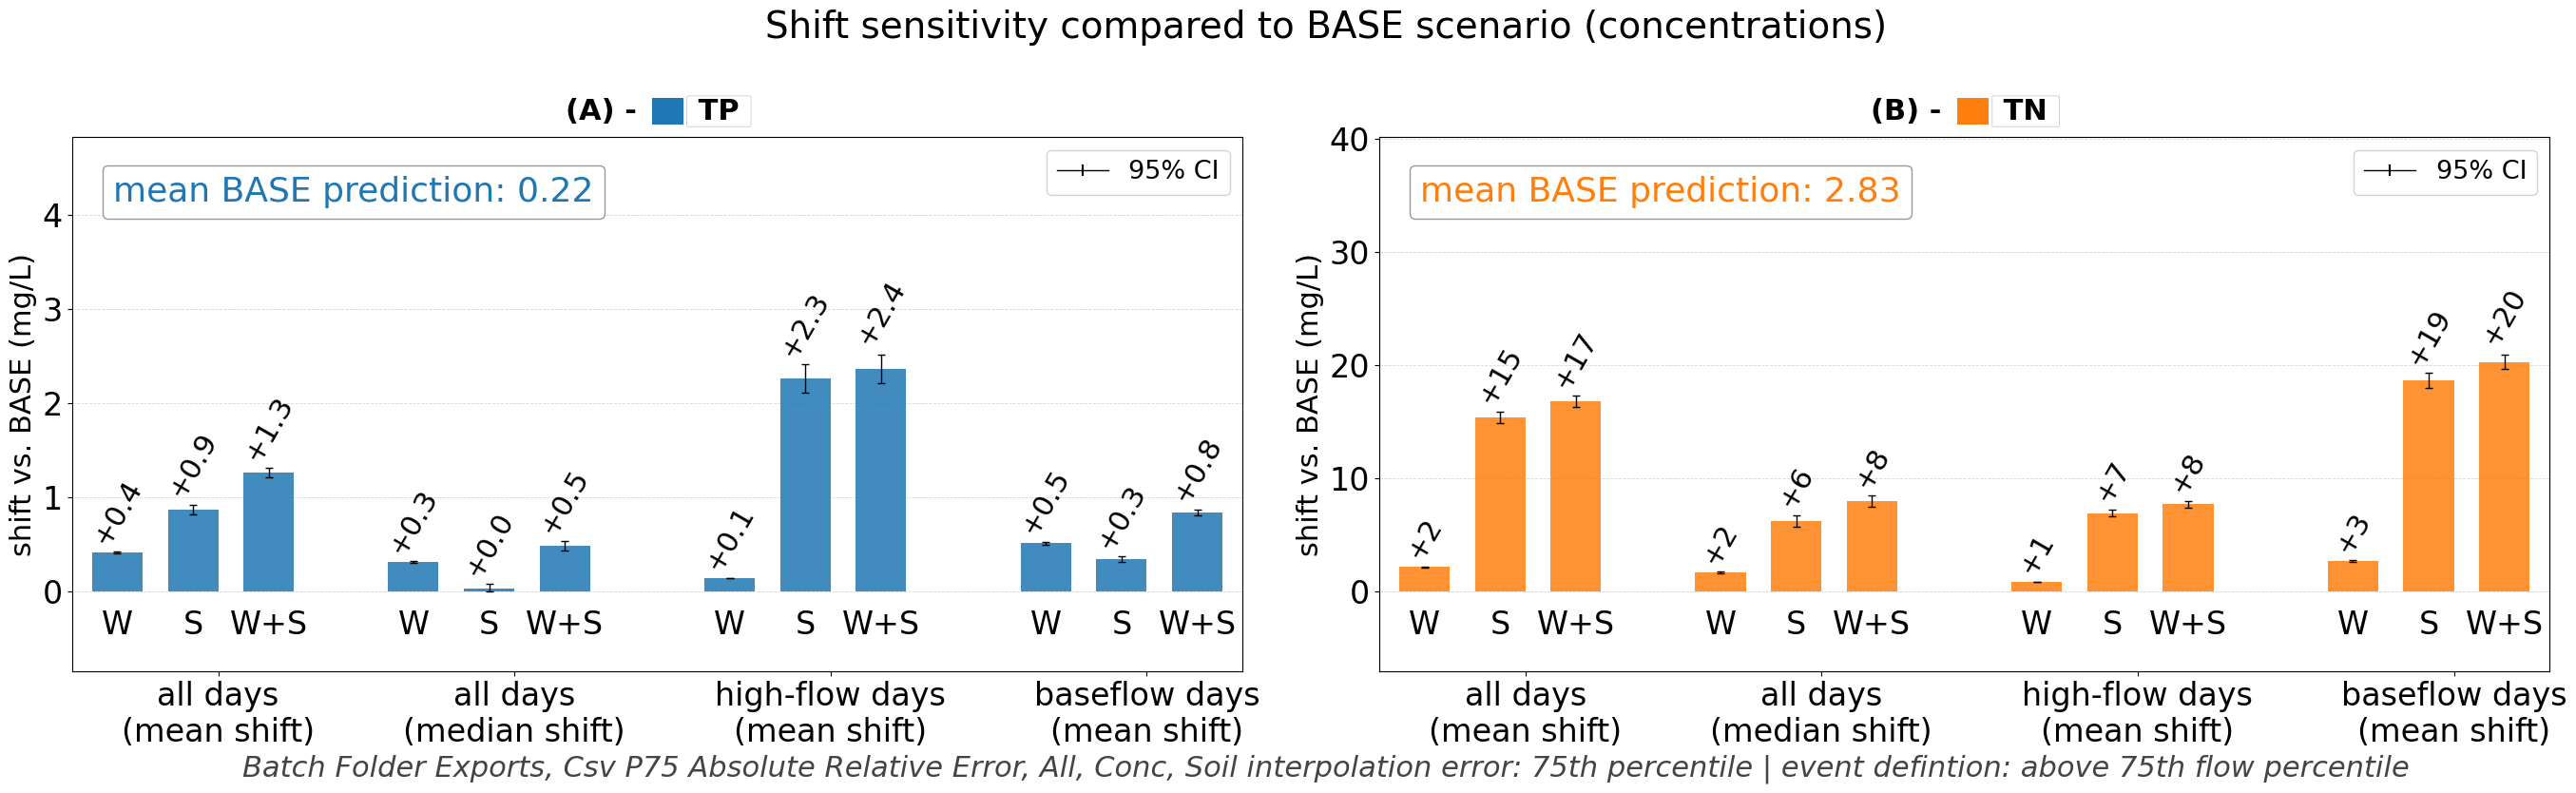


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Shift sensitivity compared to BASE scenario (concentrations)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Mean shift (vs. BASE),scenario,WASTE / TP,SOIL / TP,-0.459,-52.9%,0.409,0.867,0.698,3.02,14234,14234,-17.65,0.0000,***,-0.21,-0.51,-0.408
1,Mean shift (vs. BASE),scenario,WASTE / TP,WASTE+SOIL / TP,-0.849,-67.5%,0.409,1.26,0.698,2.98,14234,14234,-33.11,0.0000,***,-0.39,-0.899,-0.799
2,Mean shift (vs. BASE),scenario,SOIL / TP,WASTE+SOIL / TP,-0.39,-31.0%,0.867,1.26,3.02,2.98,14234,14234,-10.98,0.0000,***,-0.13,-0.46,-0.321
3,Mean shift (vs. BASE),scenario,WASTE / TN,SOIL / TN,-13.3,-86.2%,2.13,15.4,3.72,31,14234,14234,-50.68,0.0000,***,-0.60,-13.8,-12.8
4,Mean shift (vs. BASE),scenario,WASTE / TN,WASTE+SOIL / TN,-14.7,-87.3%,2.13,16.8,3.72,29.6,14234,14234,-58.74,0.0000,***,-0.70,-15.2,-14.2
5,Mean shift (vs. BASE),scenario,SOIL / TN,WASTE+SOIL / TN,-1.4,-8.3%,15.4,16.8,31,29.6,14234,14234,-3.90,0.0001,***,-0.05,-2.11,-0.698
6,Mean shift (vs. BASE),variable,WASTE / TP,WASTE / TN,-1.72,-80.8%,0.409,2.13,0.698,3.72,14234,14234,-54.11,0.0000,***,-0.64,-1.78,-1.66
7,Mean shift (vs. BASE),variable,SOIL / TP,SOIL / TN,-14.5,-94.4%,0.867,15.4,3.02,31,14234,14234,-55.63,0.0000,***,-0.66,-15,-14
8,Mean shift (vs. BASE),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-15.5,-92.5%,1.26,16.8,2.98,29.6,14234,14234,-62.40,0.0000,***,-0.74,-16,-15
9,Mean shift (vs. BASE),baseline_zero,WASTE / TP,BASE reference (0 shift),+0.409,,0.409,0,0.698,,14234,,69.88,0.0000,***,0.59,+0.397,+0.42


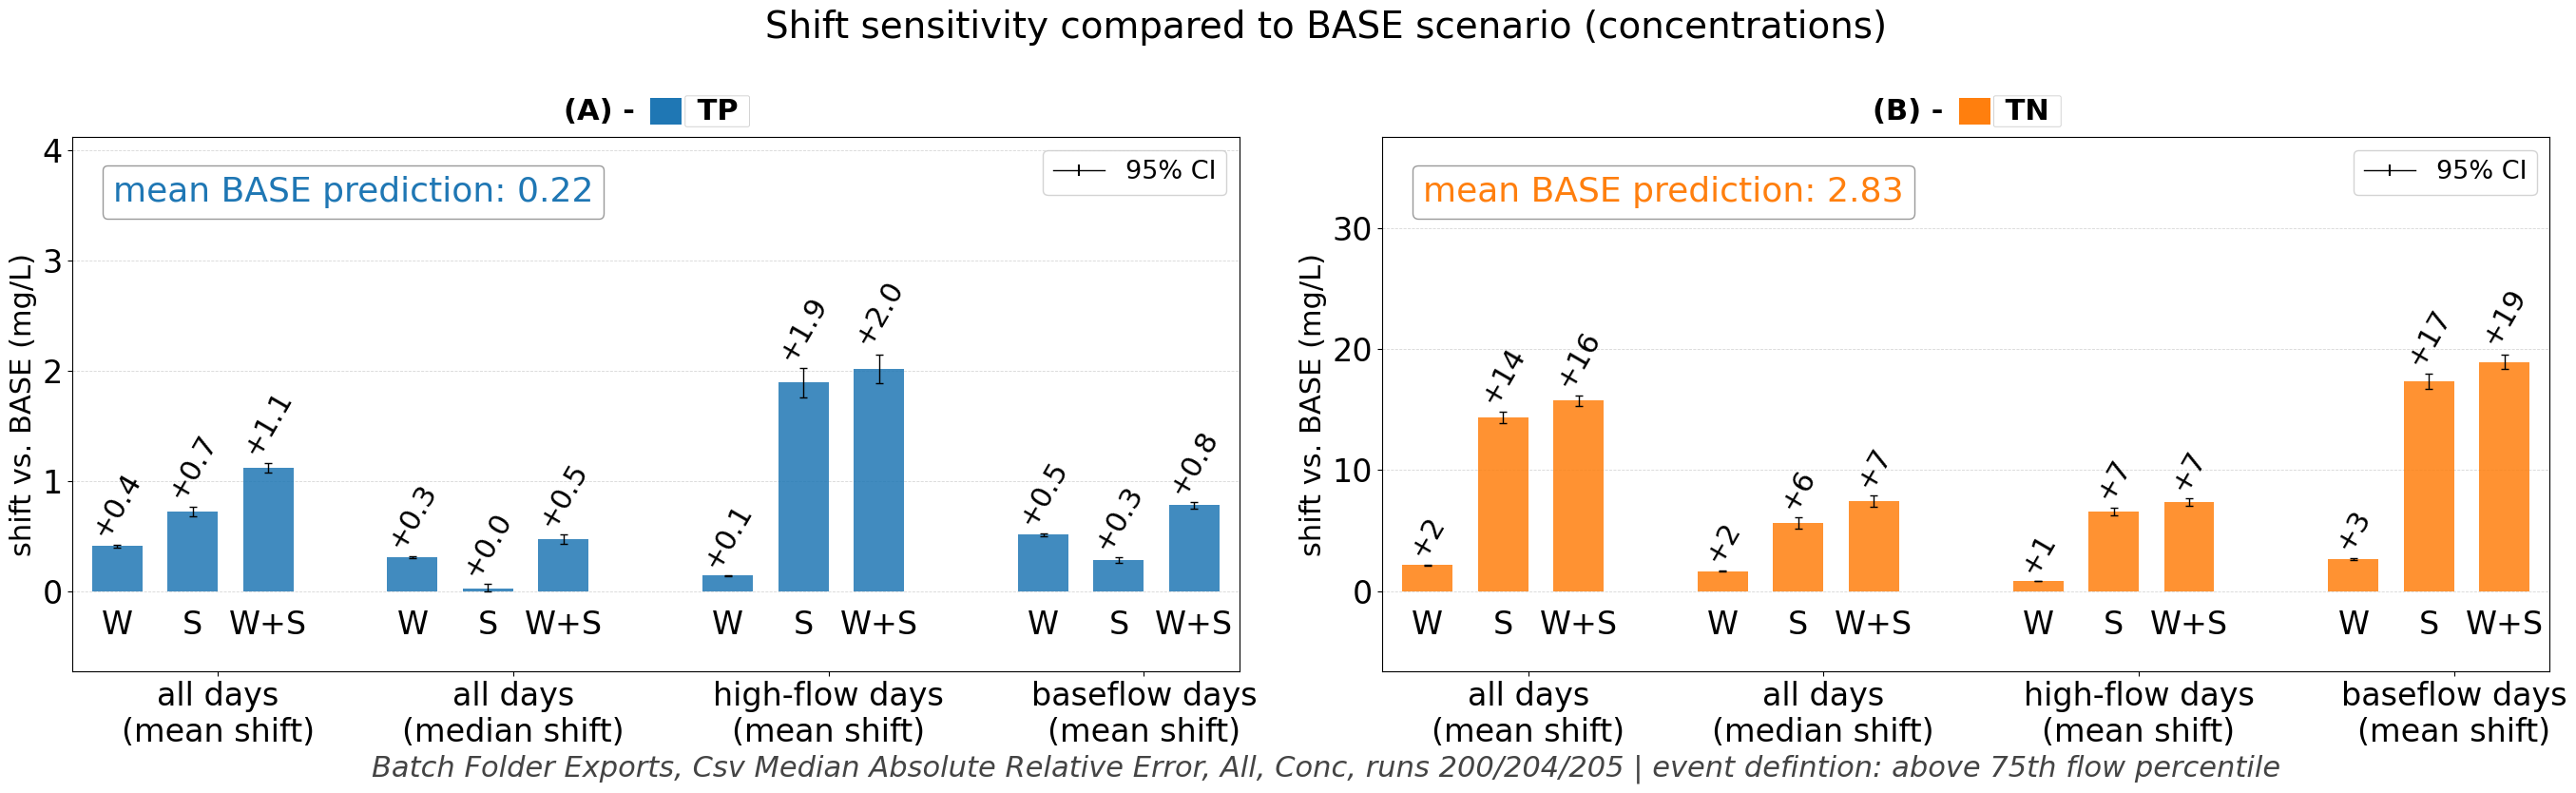


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Shift sensitivity compared to BASE scenario (concentrations)
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Conc, runs 200/204/205 | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Mean shift (vs. BASE),scenario,WASTE / TP,SOIL / TP,-0.314,-43.4%,0.409,0.722,0.698,2.56,14234,14234,-14.10,0.0000,***,-0.17,-0.357,-0.27
1,Mean shift (vs. BASE),scenario,WASTE / TP,WASTE+SOIL / TP,-0.712,-63.5%,0.409,1.12,0.698,2.56,14234,14234,-31.95,0.0000,***,-0.38,-0.755,-0.668
2,Mean shift (vs. BASE),scenario,SOIL / TP,WASTE+SOIL / TP,-0.398,-35.5%,0.722,1.12,2.56,2.56,14234,14234,-13.09,0.0000,***,-0.16,-0.457,-0.338
3,Mean shift (vs. BASE),scenario,WASTE / TN,SOIL / TN,-12.2,-85.2%,2.13,14.4,3.72,29.2,14234,14234,-49.63,0.0000,***,-0.59,-12.7,-11.8
4,Mean shift (vs. BASE),scenario,WASTE / TN,WASTE+SOIL / TN,-13.6,-86.5%,2.13,15.7,3.72,27.6,14234,14234,-58.32,0.0000,***,-0.69,-14.1,-13.2
5,Mean shift (vs. BASE),scenario,SOIL / TN,WASTE+SOIL / TN,-1.37,-8.7%,14.4,15.7,29.2,27.6,14234,14234,-4.06,0.0000,***,-0.05,-2.03,-0.708
6,Mean shift (vs. BASE),variable,WASTE / TP,WASTE / TN,-1.72,-80.8%,0.409,2.13,0.698,3.72,14234,14234,-54.11,0.0000,***,-0.64,-1.78,-1.66
7,Mean shift (vs. BASE),variable,SOIL / TP,SOIL / TN,-13.6,-95.0%,0.722,14.4,2.56,29.2,14234,14234,-55.56,0.0000,***,-0.66,-14.1,-13.2
8,Mean shift (vs. BASE),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-14.6,-92.9%,1.12,15.7,2.56,27.6,14234,14234,-62.93,0.0000,***,-0.75,-15.1,-14.2
9,Mean shift (vs. BASE),baseline_zero,WASTE / TP,BASE reference (0 shift),+0.409,,0.409,0,0.698,,14234,,69.88,0.0000,***,0.59,+0.397,+0.42



----------------------------------------------------------------------------------------
Chart 2: Load graphs
----------------------------------------------------------------------------------------


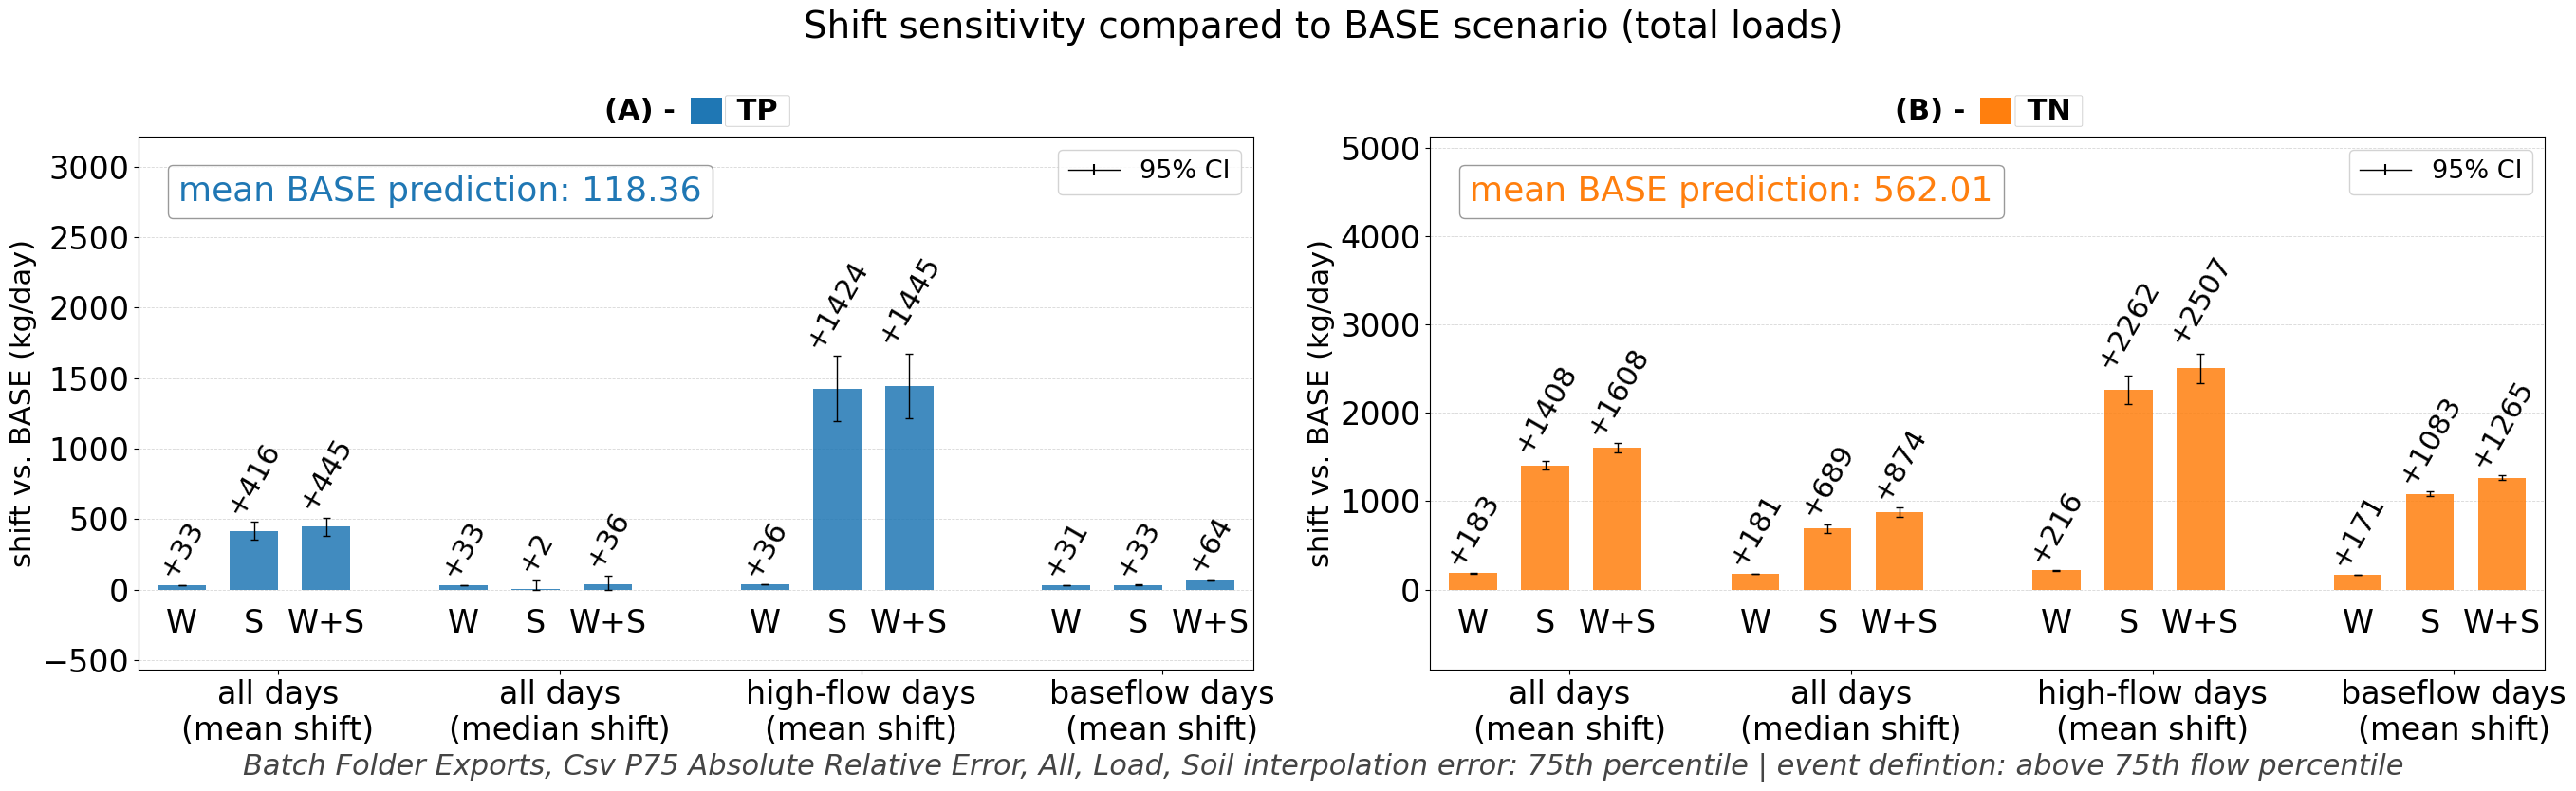


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Shift sensitivity compared to BASE scenario (total loads)
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Mean shift (vs. BASE),scenario,WASTE / TP,SOIL / TP,-383,-92.2%,32.6,416,4.51,3.94e+03,14245,14245,-11.60,0.0000,***,-0.14,-448,-318
1,Mean shift (vs. BASE),scenario,WASTE / TP,WASTE+SOIL / TP,-412,-92.7%,32.6,445,4.51,3.9e+03,14245,14245,-12.61,0.0000,***,-0.15,-476,-348
2,Mean shift (vs. BASE),scenario,SOIL / TP,WASTE+SOIL / TP,-29.3,-6.6%,416,445,3.94e+03,3.9e+03,14245,14245,-0.63,0.5288,ns,-0.01,-120,+61.8
3,Mean shift (vs. BASE),scenario,WASTE / TN,SOIL / TN,-1.22e+03,-87.0%,183,1.41e+03,55.8,3e+03,14245,14245,-48.72,0.0000,***,-0.58,-1.27e+03,-1.18e+03
4,Mean shift (vs. BASE),scenario,WASTE / TN,WASTE+SOIL / TN,-1.42e+03,-88.6%,183,1.61e+03,55.8,3.1e+03,14245,14245,-54.79,0.0000,***,-0.65,-1.48e+03,-1.37e+03
5,Mean shift (vs. BASE),scenario,SOIL / TN,WASTE+SOIL / TN,-200,-12.5%,1.41e+03,1.61e+03,3e+03,3.1e+03,14245,14245,-5.54,0.0000,***,-0.07,-271,-129
6,Mean shift (vs. BASE),variable,WASTE / TP,WASTE / TN,-151,-82.2%,32.6,183,4.51,55.8,14245,14245,-321.60,0.0000,***,-3.81,-152,-150
7,Mean shift (vs. BASE),variable,SOIL / TP,SOIL / TN,-992,-70.5%,416,1.41e+03,3.94e+03,3e+03,14245,14245,-23.91,0.0000,***,-0.28,-1.07e+03,-911
8,Mean shift (vs. BASE),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-1.16e+03,-72.3%,445,1.61e+03,3.9e+03,3.1e+03,14245,14245,-27.84,0.0000,***,-0.33,-1.24e+03,-1.08e+03
9,Mean shift (vs. BASE),baseline_zero,WASTE / TP,BASE reference (0 shift),+32.6,,32.6,0,4.51,,14245,,861.42,0.0000,***,7.22,+32.5,+32.6


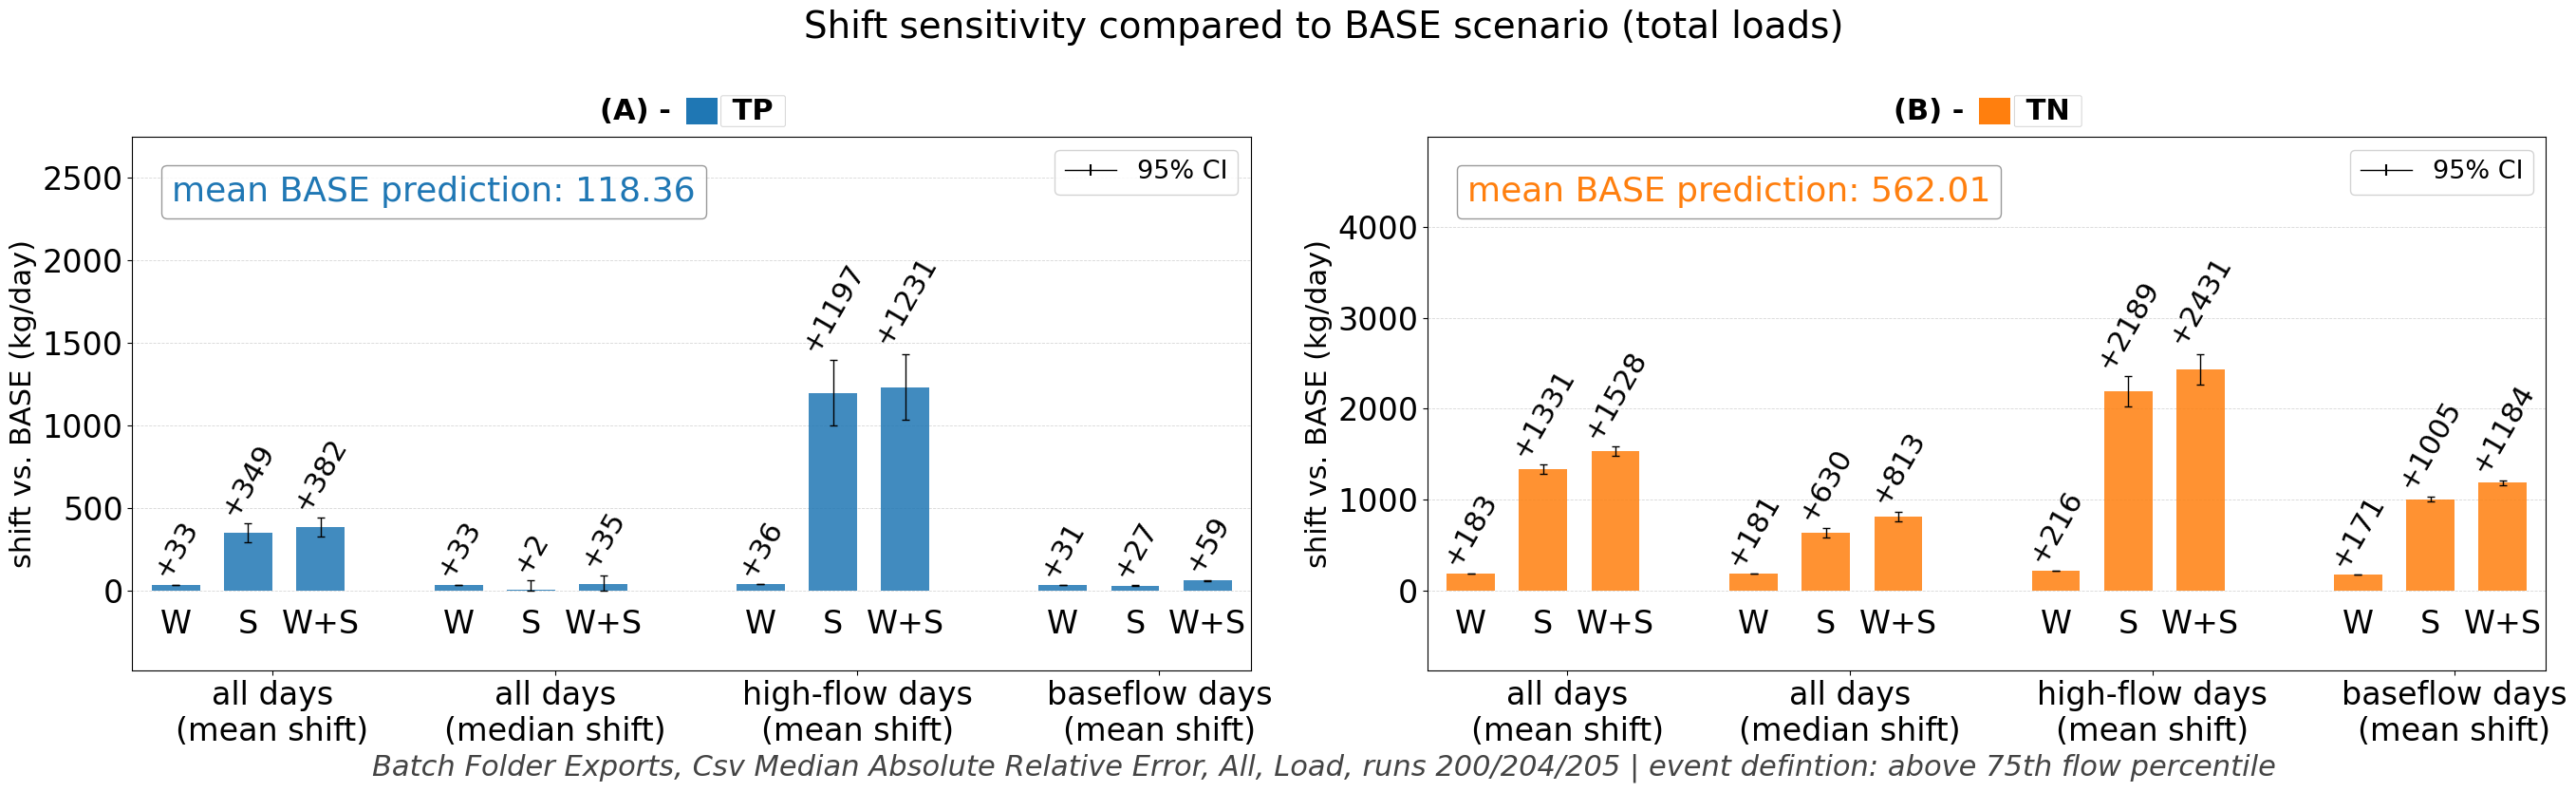


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: Shift sensitivity compared to BASE scenario (total loads)
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Load, runs 200/204/205 | event defintion: above 75th flow percentile
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Mean shift (vs. BASE),scenario,WASTE / TP,SOIL / TP,-317,-90.7%,32.6,349,4.51,3.4e+03,14245,14245,-11.11,0.0000,***,-0.13,-373,-261
1,Mean shift (vs. BASE),scenario,WASTE / TP,WASTE+SOIL / TP,-350,-91.5%,32.6,382,4.51,3.41e+03,14245,14245,-12.25,0.0000,***,-0.15,-405,-294
2,Mean shift (vs. BASE),scenario,SOIL / TP,WASTE+SOIL / TP,-32.7,-8.6%,349,382,3.4e+03,3.41e+03,14245,14245,-0.81,0.4170,ns,-0.01,-112,+46.3
3,Mean shift (vs. BASE),scenario,WASTE / TN,SOIL / TN,-1.15e+03,-86.2%,183,1.33e+03,55.8,3.07e+03,14245,14245,-44.59,0.0000,***,-0.53,-1.2e+03,-1.1e+03
4,Mean shift (vs. BASE),scenario,WASTE / TN,WASTE+SOIL / TN,-1.35e+03,-88.0%,183,1.53e+03,55.8,3.16e+03,14245,14245,-50.88,0.0000,***,-0.60,-1.4e+03,-1.29e+03
5,Mean shift (vs. BASE),scenario,SOIL / TN,WASTE+SOIL / TN,-197,-12.9%,1.33e+03,1.53e+03,3.07e+03,3.16e+03,14245,14245,-5.35,0.0000,***,-0.06,-270,-125
6,Mean shift (vs. BASE),variable,WASTE / TP,WASTE / TN,-151,-82.2%,32.6,183,4.51,55.8,14245,14245,-321.60,0.0000,***,-3.81,-152,-150
7,Mean shift (vs. BASE),variable,SOIL / TP,SOIL / TN,-982,-73.8%,349,1.33e+03,3.4e+03,3.07e+03,14245,14245,-25.55,0.0000,***,-0.30,-1.06e+03,-906
8,Mean shift (vs. BASE),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-1.15e+03,-75.0%,382,1.53e+03,3.41e+03,3.16e+03,14245,14245,-29.47,0.0000,***,-0.35,-1.22e+03,-1.07e+03
9,Mean shift (vs. BASE),baseline_zero,WASTE / TP,BASE reference (0 shift),+32.6,,32.6,0,4.51,,14245,,861.42,0.0000,***,7.22,+32.5,+32.6



Finished chart 2 for all configured folders.
Chart 2 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  compare_mode: conc
  info box overlay stat: mean
  scenarios: ['WASTE', 'SOIL', 'WASTE+SOIL']
  variables: ['TP', 'TN']
Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\batch_folder_exports\csv_p75_absolute_relative_error\half_mdl\all\conc\runs_188_200_201__vars_tot_nkg_tot_pkg
run-188: export_variable=tot-nkg scenario=SOIL, variable=TN
run-188: export_variable=tot-pkg scenario=SOIL, variable=TP
run-200: export_variable=tot-nkg scenario=WASTE, variable=TN
run-200: export_variable=tot-pkg scenario=WASTE, variable=TP
run-201: export_variable=tot-nkg scenario=WASTE+SOIL, variable=TN
run-201: export_variable=tot-pkg scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 189, 202, 203, 204, 205]

Built 6 export s

In [19]:
chart_2_metrics_by_folder = {}

chart_2_logs = []

# "-- Info-box configuration (external BASE overlay metric shown per variable) "--
ch2_info_box_overlay_stat = "mean"                            # switch to "mean" to display the external BASE mean
_ch2_info_box_metric_options = {
    "median": {
        "metric_name": "overlay_p50",
        "label": "median BASE prediction",
    },
    "mean": {
        "metric_name": "overlay_mean",
        "label": "mean BASE prediction",
    },
}
ch2_info_box_overlay_stat = str(ch2_info_box_overlay_stat).strip().lower()
if ch2_info_box_overlay_stat not in _ch2_info_box_metric_options:
    raise ValueError(
        f"Unsupported ch2_info_box_overlay_stat={ch2_info_box_overlay_stat!r}. "
        f"Choose one of: {sorted(_ch2_info_box_metric_options)}"
    )
_ch2_info_box_metric_cfg = _ch2_info_box_metric_options[ch2_info_box_overlay_stat]
ch2_info_box_prefix = f"{_ch2_info_box_metric_cfg['label']}:"   # text before the numeric value
ch2_info_box_metric_name = _ch2_info_box_metric_cfg["metric_name"]
ch2_info_box_x = 0.025                                           # horizontal position (0-1 in axes coords)
ch2_info_box_y = 0.95                                            # vertical position (0-1 in axes coords)
ch2_info_box_metric_path = ("overlay_comparison", "BASE", ch2_info_box_metric_name)



_last_ch2_compare_mode = None
for batch_folder in _ch12_batch_folders:
    _ch2_compare_mode = _resolve_batch_folder_compare_mode(batch_folder)
    if _ch2_compare_mode != _last_ch2_compare_mode:
        _print_graph_group_separator(_ch2_compare_mode, chart_label='Chart 2')
        _last_ch2_compare_mode = _ch2_compare_mode

    generated_specs, build_log = _capture_stdout(

        build_export_specs_from_folder,

        batch_folder,

        run_to_scenario,

        variable_map,

        verbose=True,

    )



    _ch2_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))

    _ch2_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))

    _ch2_selected_scenarios = _ordered_present_values(_ch2_actual_scenarios, chart_scenario_order)

    _ch2_selected_variables = _ordered_present_values(_ch2_actual_variables, chart_variable_order)



    ch_2_auto_metrics = build_metrics_dict_from_stat_exports(

        generated_specs,

        ch2_semantic_labels,

        semantic_label_map=example_semantic_label_map,

        scenario_order=_ch2_selected_scenarios,

        variable_order=_ch2_selected_variables,

        format_mode="metadata",

        verbose=False,

    )

    # Extract the selected external BASE overlay summary for the info box (first JSON per variable)
    _ch2_overlay_reference_value = {}
    for _spec in generated_specs:
        _loaded = _load_stat_export(_spec, verbose=False)
        _var = _loaded["variable"]
        if _var not in _ch2_overlay_reference_value:
            _val = _extract_metric_value(
                _loaded["stats"], ch2_info_box_metric_name,
                explicit_path=ch2_info_box_metric_path,
                verbose=False,
            )
            _ch2_overlay_reference_value[_var] = _val
    _ch2_var_colors = {"TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c", "TON": "#d62728", "PP": "#9467bd"}
    _ch2_info_box_lines = [
        (f"{var}: {ch2_info_box_prefix} {_ch2_overlay_reference_value[var]:.2f}", _ch2_var_colors.get(var, "black"))
        for var in _ch2_selected_variables
        if var in _ch2_overlay_reference_value
    ]



    _ch2_example_export = _load_stat_export(generated_specs[0], verbose=False)

    _ch2_dashboard_state = (

        _ch2_example_export["payload"].get("metadata", {}).get("dashboard_state")

        or _ch2_example_export["payload"].get("dashboard_state")

        or {}

    )

    _ch2_compare_mode = str(_ch2_dashboard_state.get("compare_mode") or "load").strip().lower()

    if _ch2_compare_mode == "conc":

        ch_2_chart_descriptor = "Shift sensitivity compared to BASE scenario (concentrations)"
        ch_2_y_label = "shift vs. BASE (mg/L)"

        def _ch2_annotation_formatter(value, stat, scenario, variable, default_text):
            if variable == "TP":
                return f"{value:+.1f}"
            return default_text

    else:

        ch_2_chart_descriptor = "Shift sensitivity compared to BASE scenario (total loads)"
        ch_2_y_label = "shift vs. BASE (kg/day)"
        _ch2_annotation_formatter = None



    ch_2_title_metadata_parts = [

    "folder_label",           # represents interpolation error and MDL handling policy

    #"view",                   # represents event vs non-event vs all days

    "event_threshold",        # defines event definition (e.g. P75, abs)

    #"measured_selection",     # summarises which chemicals and stations were included in the measured data for this chart (e.g. "measured: TKN + Nitrate; Station: 30304")

    #"n",                      # number of measurements considere by above filter and mapping

    #"reach",                  # represents the reach being analysed (e.g. 13)

    #"measured_nonnum_policy", 

    ]



    ch_2_title_folder_label_map = {

        # exact-match shorthand  (token: label)

        "runs_187_200_202":      "Soil interpolation error: relative median",

        "runs_205_200_204":      "Soil interpolation error: absolute median",

        "runs_189_200_203":      "Soil interpolation error: relative RMSE",

        "runs_188_200_201":      "Soil interpolation error: 75th percentile",

        "runs_153_155_157":      "Original TFM (relative RMSE)",

        "drop_mdl":              None, #"drop-below-DL",

        "half_mdl":              None, #"half-DL",

    }





    EVENT_THRESHOLD_TITLE_ALIASES = {

    "p50": "event defintion: above 50th flow percentile",

    "p75": "event defintion: above 75th flow percentile",

    "p90": "event defintion: above 90th flow percentile",

    "abs": "event defintion: above absolute flow value",

    }       



    chart_title, chart_subtitle = build_semantic_chart_title(

        batch_folder, generated_specs,

        ch_2_chart_descriptor,

        title_metadata_parts=ch_2_title_metadata_parts,

        title_folder_label_map=ch_2_title_folder_label_map,

    )




    _ch2_error_data = build_error_data_from_extended_stats(
        generated_specs, ch2_semantic_labels,
        error_mode="ci95",
    )

    fig, ax = plot_nested_sensitivity_bars(

        ch_2_auto_metrics,

        title=chart_title,

        subtitle=chart_subtitle,

        small_value_threshold = 0.1,
        small_value_decimals = 2,

        variables_order=_ch2_selected_variables,

        scenarios_order=_ch2_selected_scenarios,

        abbreviations=chart_abbreviations,

        y_label=ch_2_y_label,

        figsize=(20, 8),

        stats_order=ch2_semantic_labels,
        stat_label_map={
            "Mean shift (vs. BASE)":  "all days\n(mean shift)",
            "Median shift (vs. BASE)": "all days\n(median shift)",
            "Mean shift (high-flow days)":      "high-flow days\n(mean shift)",
            "Mean shift (baseflow days)":  "baseflow days\n(mean shift)",
        },

        annotate_rotation=60,

        scenario_label_rotation=0,


        annot_fs=22,

        scenario_fs=24,

        tick_fs=24,

        label_fs=22,

        title_fs=28,

        legend_fs=26,

        legend_outside=False,

        legend_loc="upper right",

        legend_bbox=(0.98, 0.98),

        tight_layout_rect=(0.0, 0.02, 0.98, 0.98),

        inside_legend_top_margin_scale=0.90,

        edge_bar_padding=0.90,

        label_separation_scale=0.02,
        label_offset_scale=0.01,
        label_x_nudge_scale=0.29,

        subtitle_y=-0.0075, # the smaller the lower the subtitle (can be negative to go below the plot area

        bottom_margin_for_labels=0.34,  # for scenario labels

        annotation_formatter=_ch2_annotation_formatter,

        info_box_lines=_ch2_info_box_lines,
        info_box_x=ch2_info_box_x,
        info_box_y=ch2_info_box_y,

        split_variable_panels=chart_split_variable_panels,
        split_panel_figsize=chart_split_panel_figsize,
        split_panel_wspace=chart_split_panel_wspace,
        split_panel_suptitle_y=chart_split_panel_suptitle_y,
        split_panel_suptitle_fs=chart_split_panel_suptitle_fs,
        split_panel_variable_title=chart_split_panel_variable_title,
        split_panel_variable_title_fs=chart_split_panel_variable_title_fs,
        split_panel_variable_title_bg=chart_split_panel_variable_title_bg,
        split_panel_variable_title_pad=chart_split_panel_variable_title_pad,
        split_panel_left_y_label_only=chart_split_panel_left_y_label_only,
        split_panel_legend_panel=chart_split_panel_legend_panel,
        split_panel_legend_side=chart_split_panel_legend_side,
        split_panel_tight_rect=chart_split_panel_tight_rect,

        error_data=_ch2_error_data,
        error_bar_legend_label="95% CI",
    )

    plt.show()


    # "-- Significance table for Chart 2 "--
    display_chart_significance_tables(
        ch_2_auto_metrics,
        generated_specs,
        chart_title=f"Table: {chart_title}",
        chart_subtitle=chart_subtitle,
        comparison_modes=("scenarios", "variables"),
        scenarios=_ch2_selected_scenarios,
        variables=_ch2_selected_variables,
        metric_labels=ch2_semantic_labels,
    )


    saved_path, save_log = _capture_stdout(

        _save_chart_figure,

        fig,

        batch_folder.name,

        "chart_2_shift",

        save_enabled=save_individual_chart_images,

        output_root=saved_chart_root,

        dpi=saved_chart_dpi,

    )

    plt.close(fig)



    chart_2_metrics_by_folder[batch_folder.name] = ch_2_auto_metrics

    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_2_metrics"] = ch_2_auto_metrics

    chart_results_by_folder[batch_folder.name]["chart_2_saved_path"] = saved_path



    chart_2_logs.append(f"Chart 2 folder: {batch_folder.name}")

    chart_2_logs.append(f"  compare_mode: {_ch2_compare_mode}")

    chart_2_logs.append(f"  info box overlay stat: {ch2_info_box_overlay_stat}")

    chart_2_logs.append(f"  scenarios: {_ch2_selected_scenarios}")

    chart_2_logs.append(f"  variables: {_ch2_selected_variables}")

    if build_log.strip():

        chart_2_logs.append(build_log.rstrip())

    if save_log.strip():

        chart_2_logs.append(save_log.rstrip())

    chart_2_logs.append("")



print("\nFinished chart 2 for all configured folders.")

print("\n".join(line for line in chart_2_logs if line is not None))


----------------------------------------------------------------------------------------
Chart 3: Concentration graphs
----------------------------------------------------------------------------------------


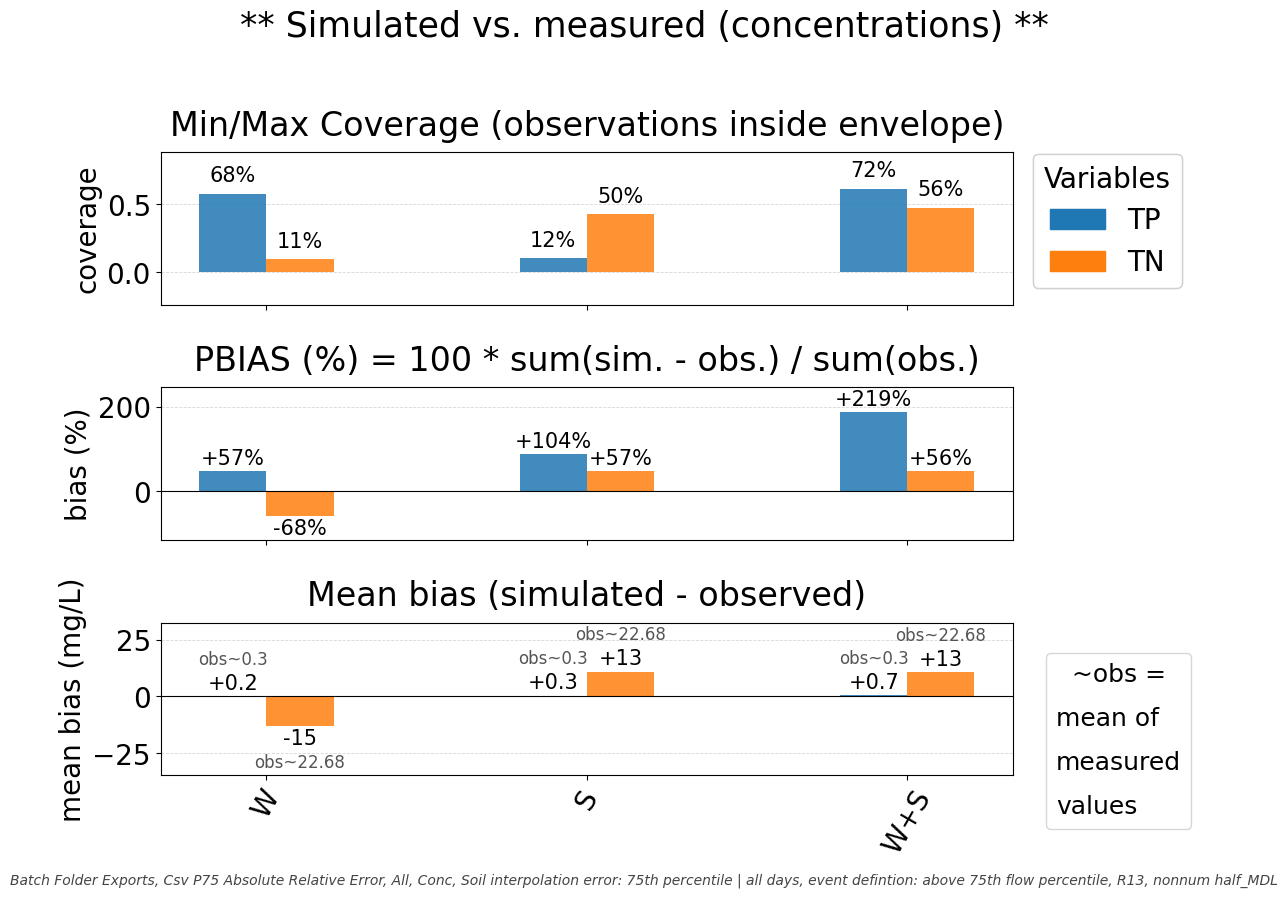


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | all days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.56,+466.7%,0.68,0.12,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.04,-5.6%,0.68,0.72,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.6,-83.3%,0.12,0.72,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.389,-77.8%,0.111,0.5,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.444,-80.0%,0.111,0.556,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,-0.0556,-10.0%,0.5,0.556,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.569,+512.0%,0.68,0.111,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.38,-76.0%,0.12,0.5,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.164,+29.6%,0.72,0.556,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-46.8,-45.1%,57.1,104,,,,,,,,,,


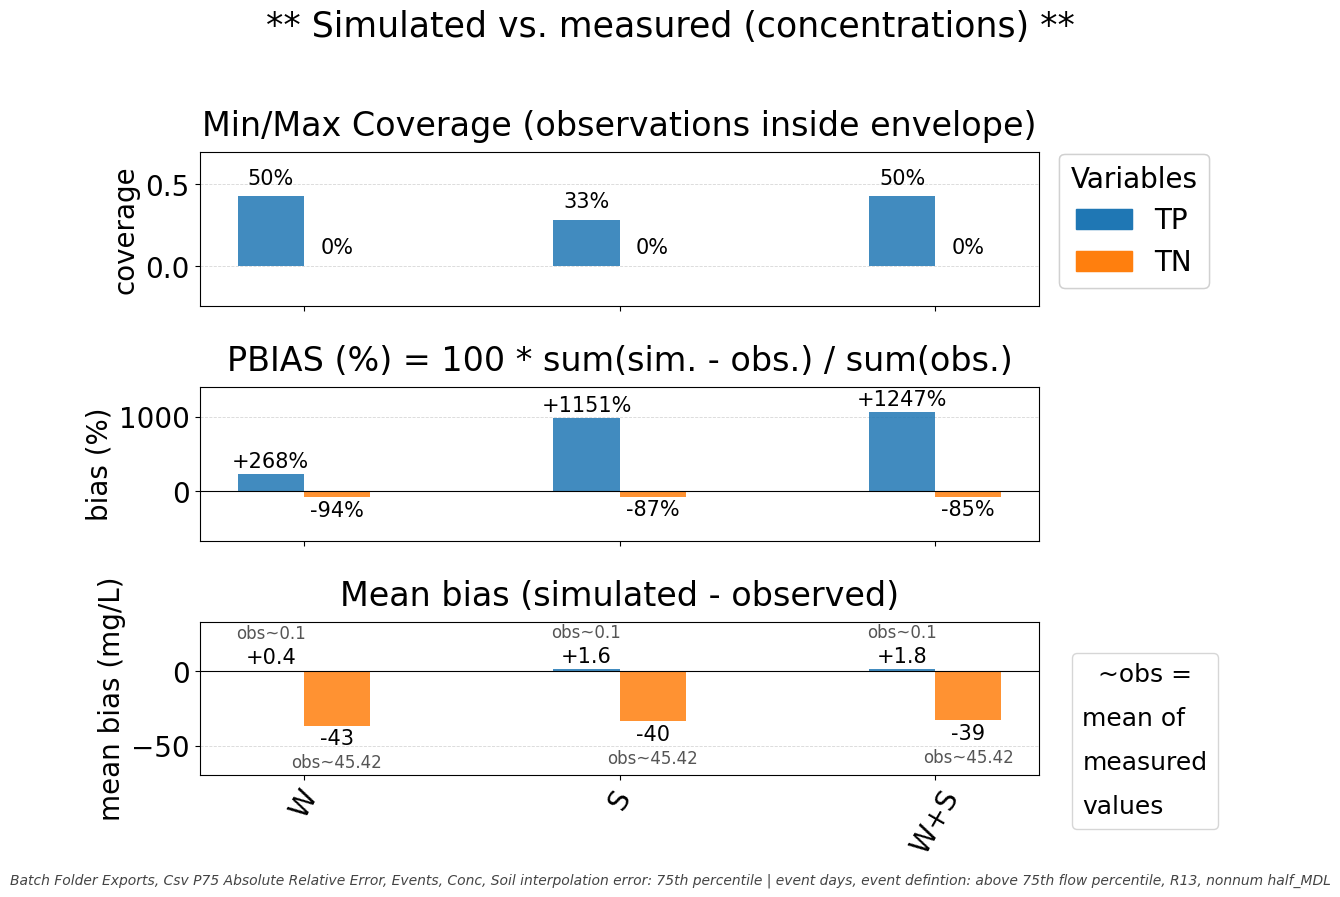


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Events, Conc, Soil interpolation error: 75th percentile | event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.167,+50.0%,0.5,0.333,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.167,-33.3%,0.333,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.333,,0.333,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-884,-76.8%,268,1.15e+03,,,,,,,,,,


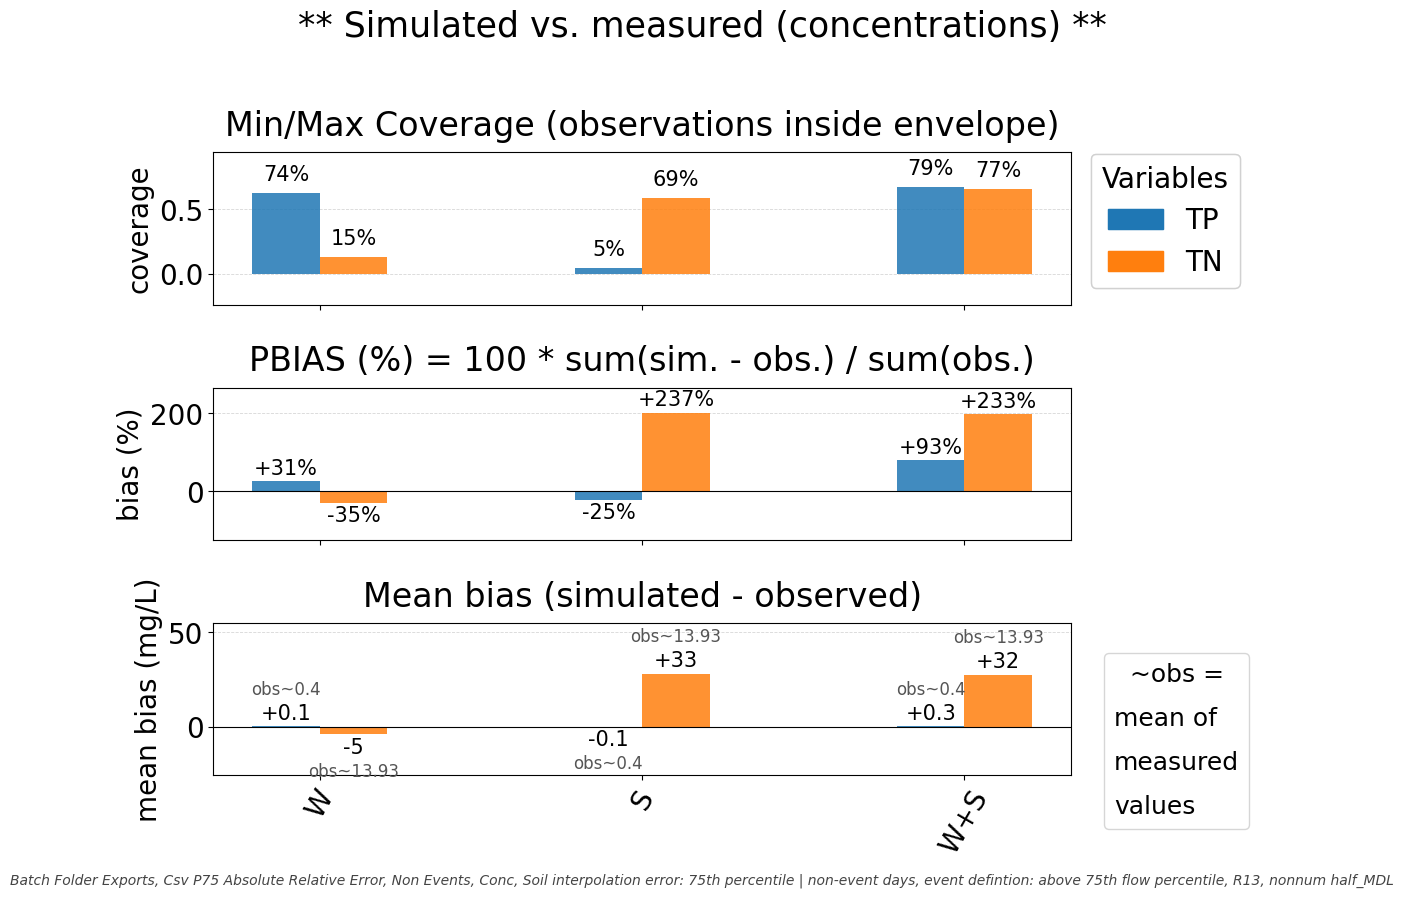


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Non Events, Conc, Soil interpolation error: 75th percentile | non-event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.684,+1300.0%,0.737,0.0526,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0526,-6.7%,0.737,0.789,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.737,-93.3%,0.0526,0.789,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.538,-77.8%,0.154,0.692,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.615,-80.0%,0.154,0.769,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,-0.0769,-10.0%,0.692,0.769,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.583,+378.9%,0.737,0.154,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.64,-92.4%,0.0526,0.692,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.0202,+2.6%,0.789,0.769,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+56.3,+223.5%,31.1,-25.2,,,,,,,,,,


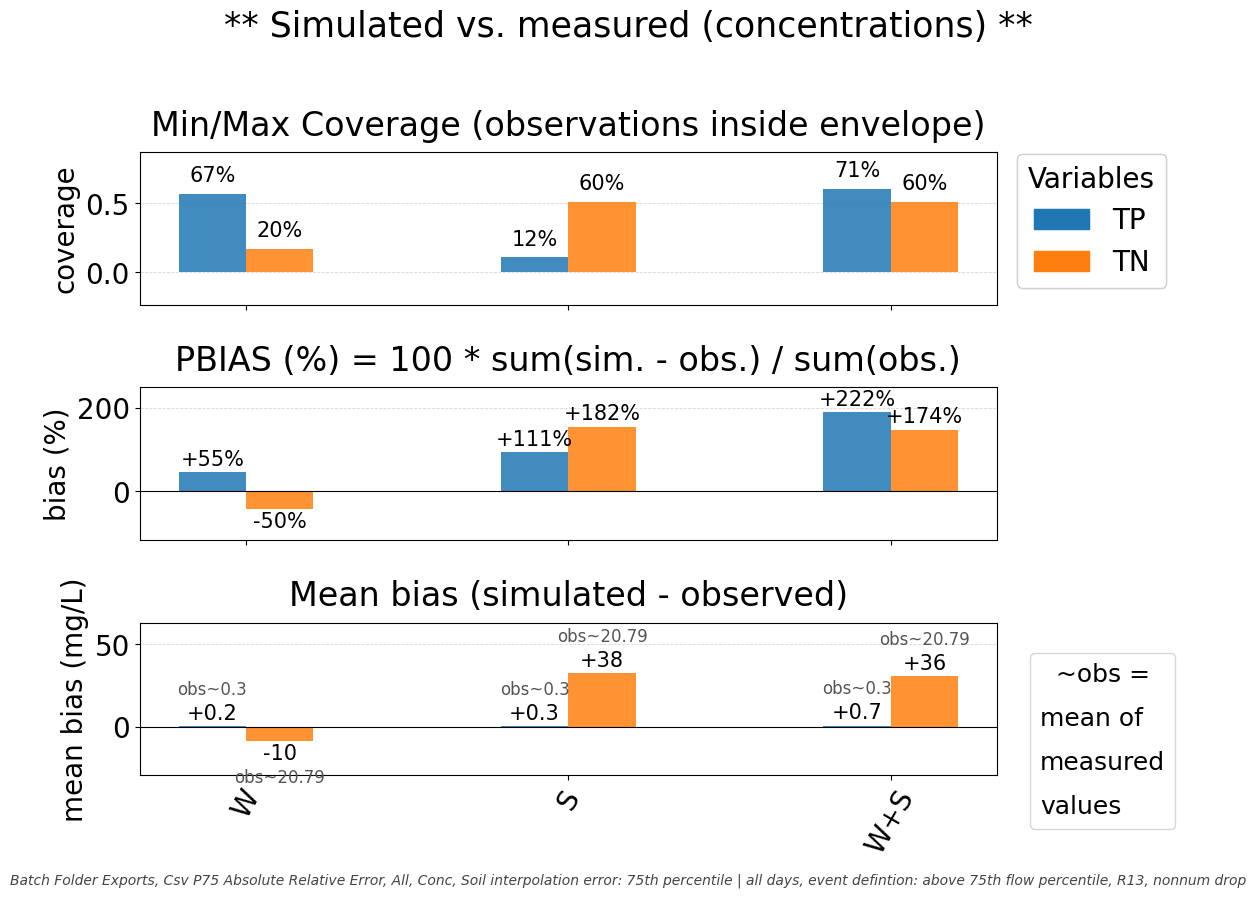


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Conc, Soil interpolation error: 75th percentile | all days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.542,+433.3%,0.667,0.125,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0417,-5.9%,0.667,0.708,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.583,-82.4%,0.125,0.708,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.4,-66.7%,0.2,0.6,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.4,-66.7%,0.2,0.6,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.6,0.6,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.467,+233.3%,0.667,0.2,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.475,-79.2%,0.125,0.6,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.108,+18.1%,0.708,0.6,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-56,-50.6%,54.6,111,,,,,,,,,,


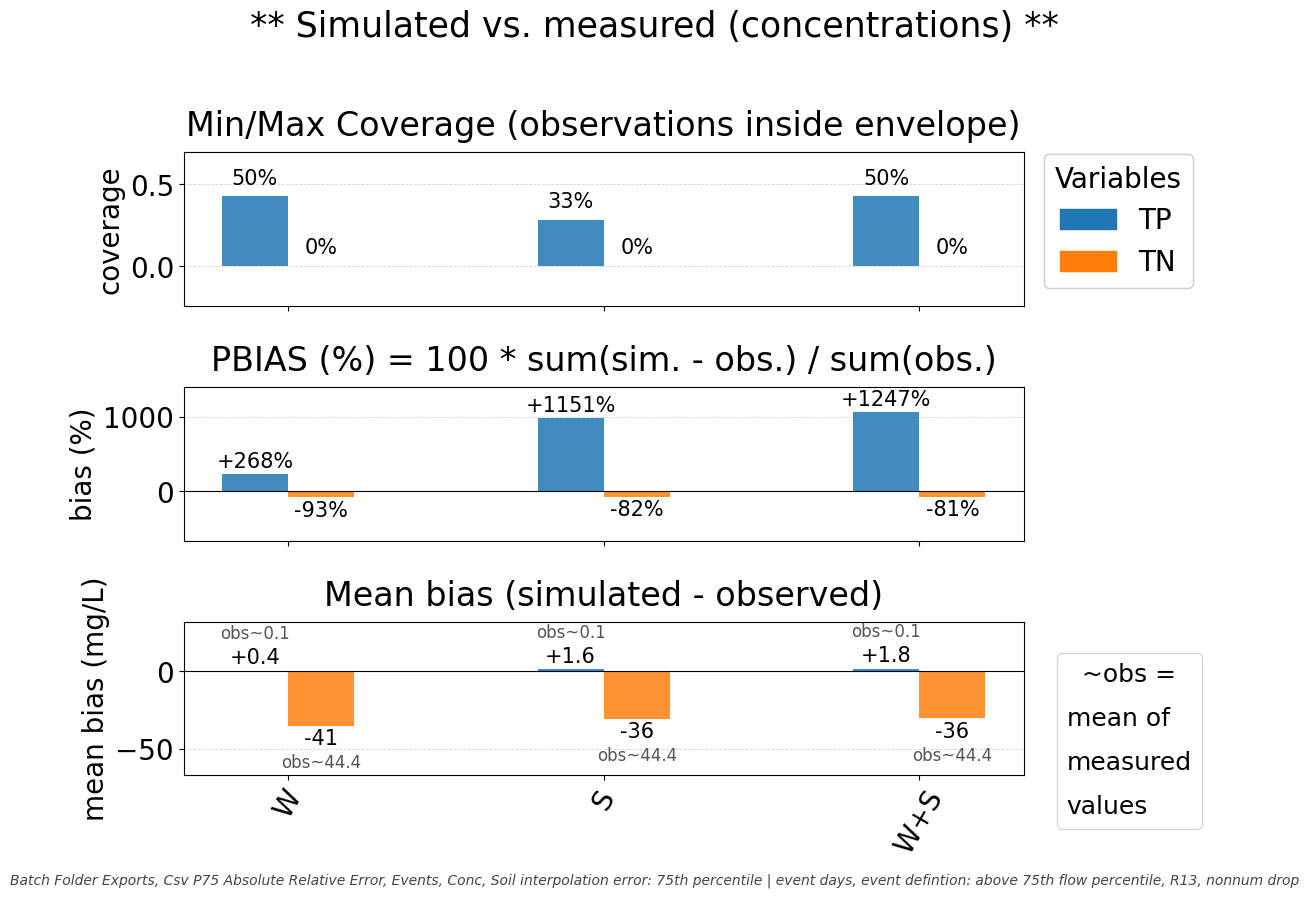


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Events, Conc, Soil interpolation error: 75th percentile | event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.167,+50.0%,0.5,0.333,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.167,-33.3%,0.333,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.333,,0.333,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-884,-76.8%,268,1.15e+03,,,,,,,,,,


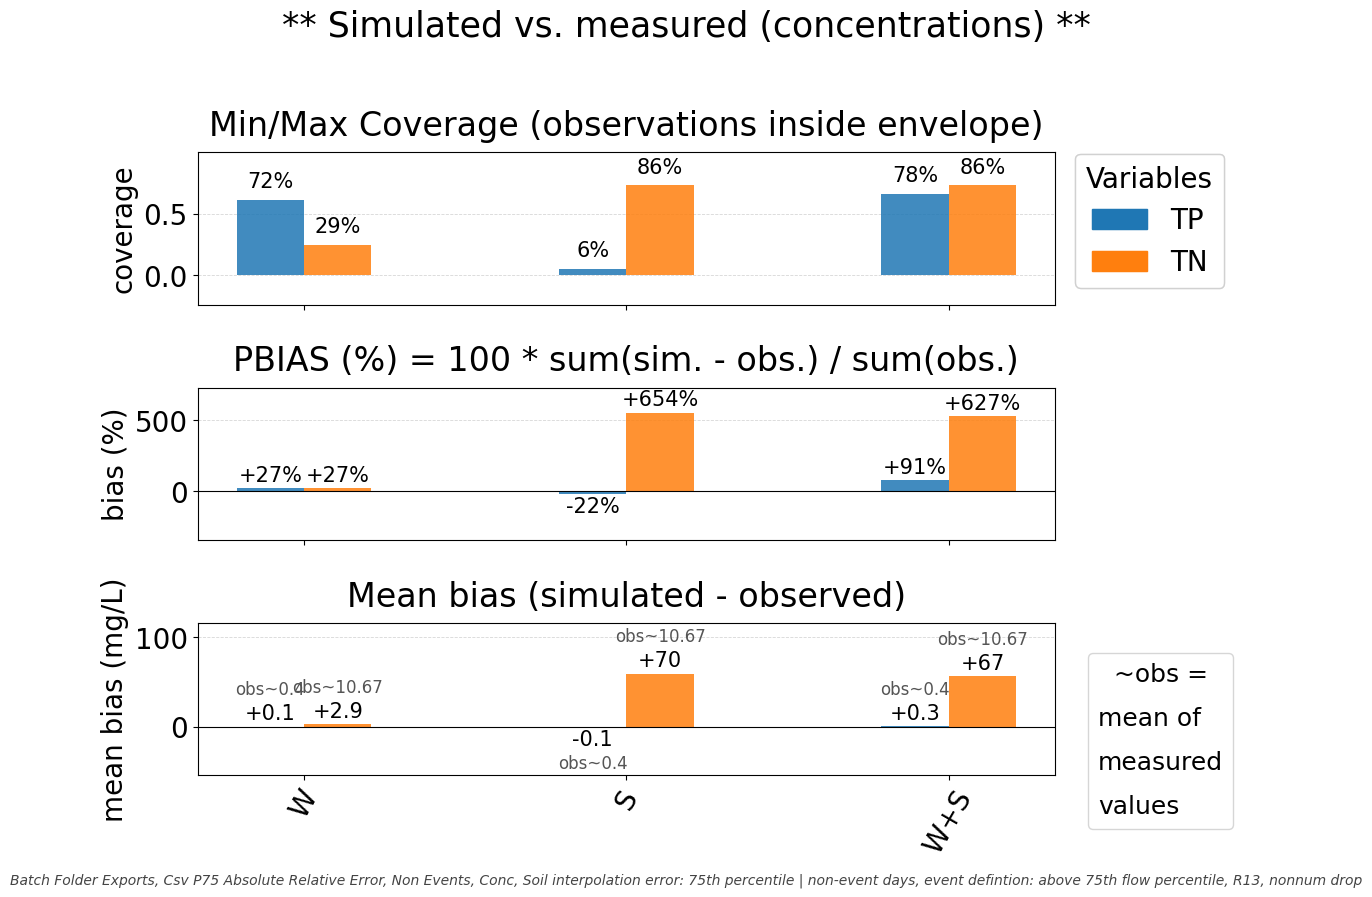


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Non Events, Conc, Soil interpolation error: 75th percentile | non-event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.667,+1200.0%,0.722,0.0556,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0556,-7.1%,0.722,0.778,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.722,-92.9%,0.0556,0.778,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.571,-66.7%,0.286,0.857,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.571,-66.7%,0.286,0.857,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.857,0.857,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.437,+152.8%,0.722,0.286,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.802,-93.5%,0.0556,0.857,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-0.0794,-9.3%,0.778,0.857,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+49.8,+222.1%,27.4,-22.4,,,,,,,,,,


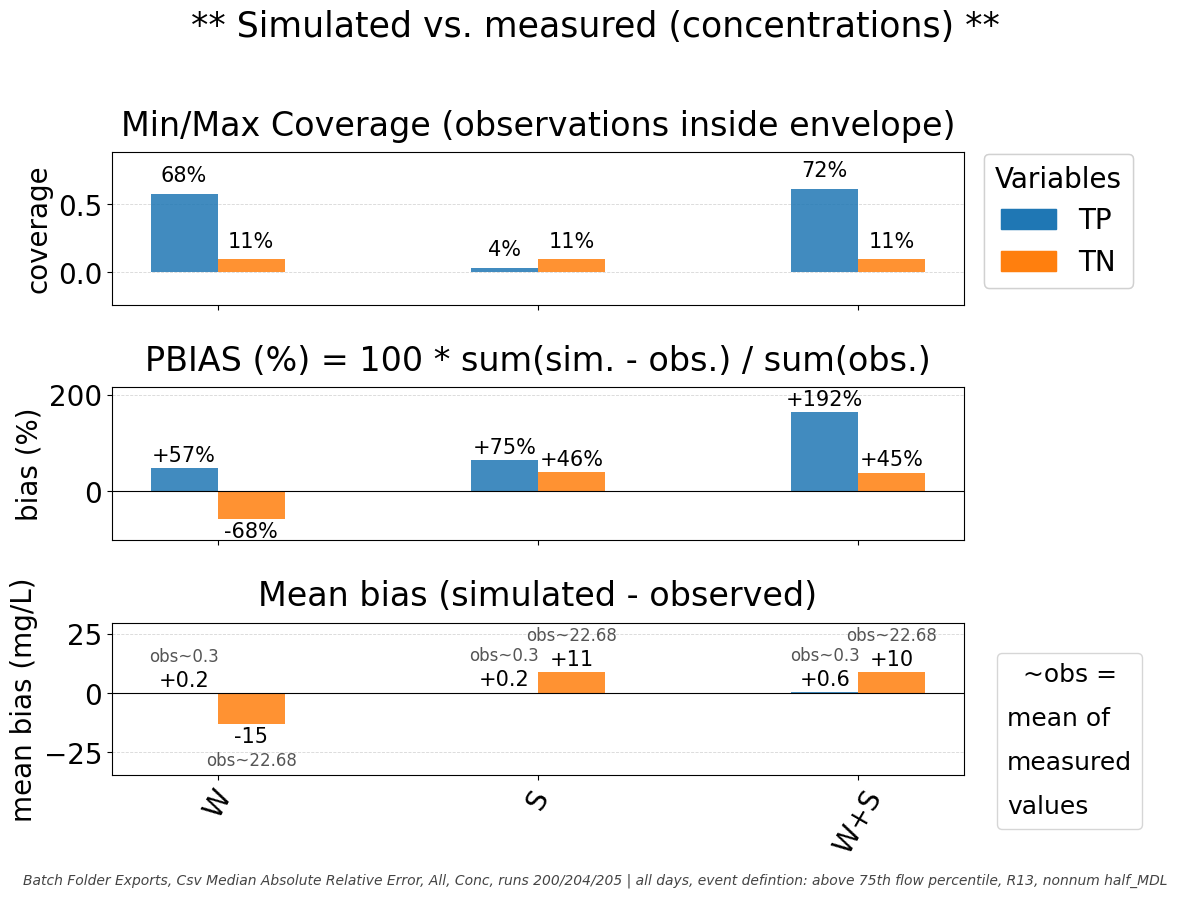


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Conc, runs 200/204/205 | all days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.64,+1600.0%,0.68,0.04,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.04,-5.6%,0.68,0.72,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.68,-94.4%,0.04,0.72,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.111,0.111,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.111,0.111,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.111,0.111,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.569,+512.0%,0.68,0.111,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.0711,-64.0%,0.04,0.111,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.609,+548.0%,0.72,0.111,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-18.2,-24.1%,57.1,75.2,,,,,,,,,,


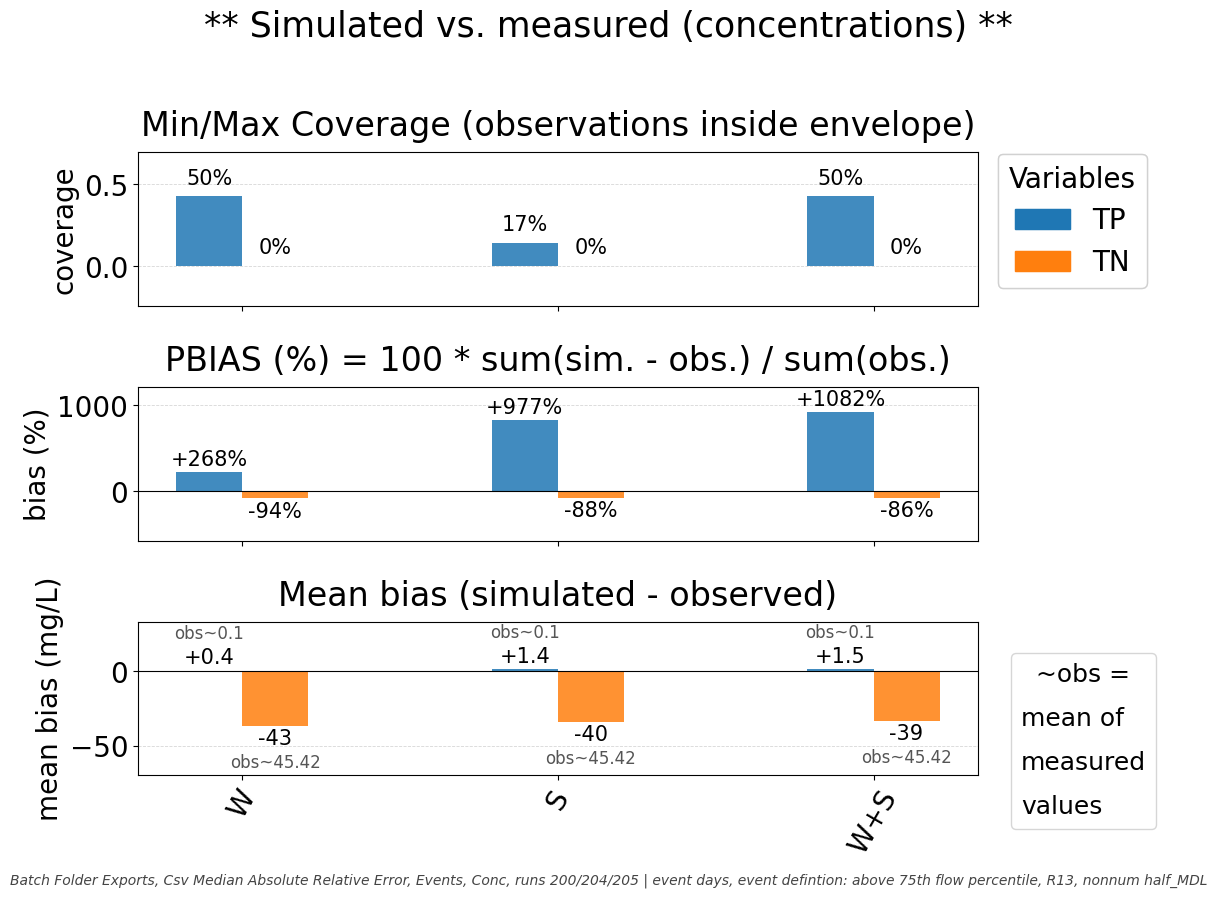


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Events, Conc, runs 200/204/205 | event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.333,+200.0%,0.5,0.167,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.333,-66.7%,0.167,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.167,,0.167,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-709,-72.6%,268,977,,,,,,,,,,


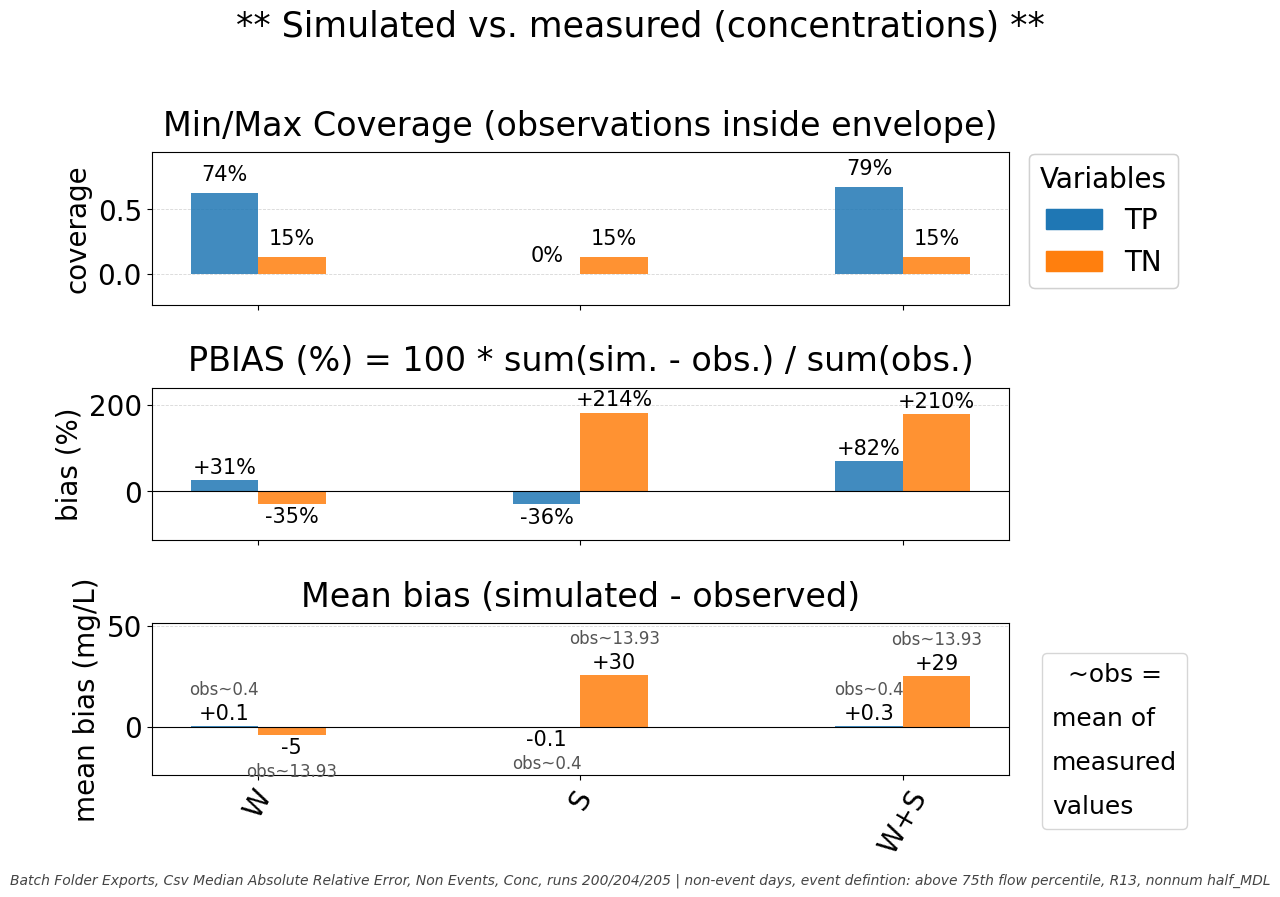


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Non Events, Conc, runs 200/204/205 | non-event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.737,,0.737,0,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0526,-6.7%,0.737,0.789,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.789,-100.0%,0,0.789,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.154,0.154,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.154,0.154,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.154,0.154,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.583,+378.9%,0.737,0.154,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.154,-100.0%,0,0.154,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.636,+413.2%,0.789,0.154,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+67,+186.6%,31.1,-35.9,,,,,,,,,,


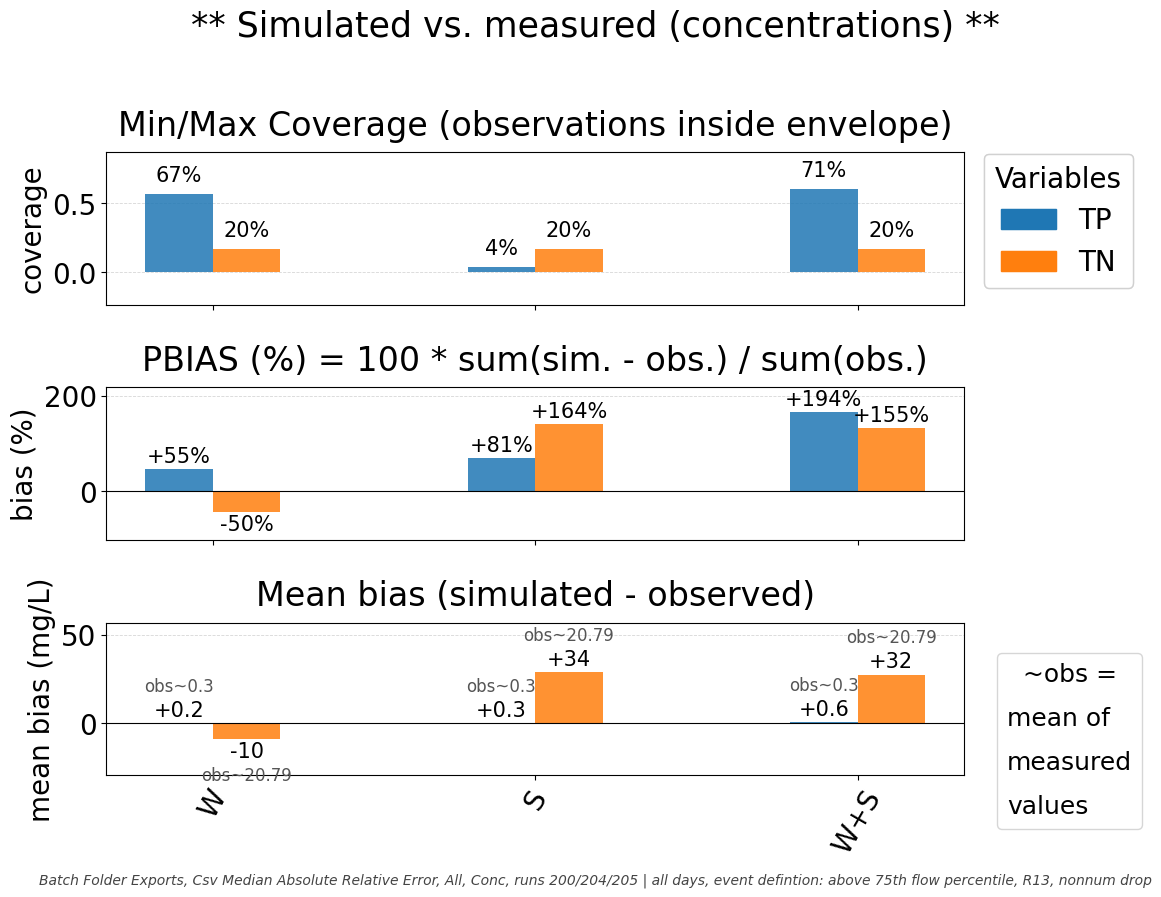


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Conc, runs 200/204/205 | all days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.625,+1500.0%,0.667,0.0417,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0417,-5.9%,0.667,0.708,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.667,-94.1%,0.0417,0.708,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.2,0.2,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.2,0.2,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.2,0.2,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.467,+233.3%,0.667,0.2,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.158,-79.2%,0.0417,0.2,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.508,+254.2%,0.708,0.2,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-26.4,-32.6%,54.6,81,,,,,,,,,,


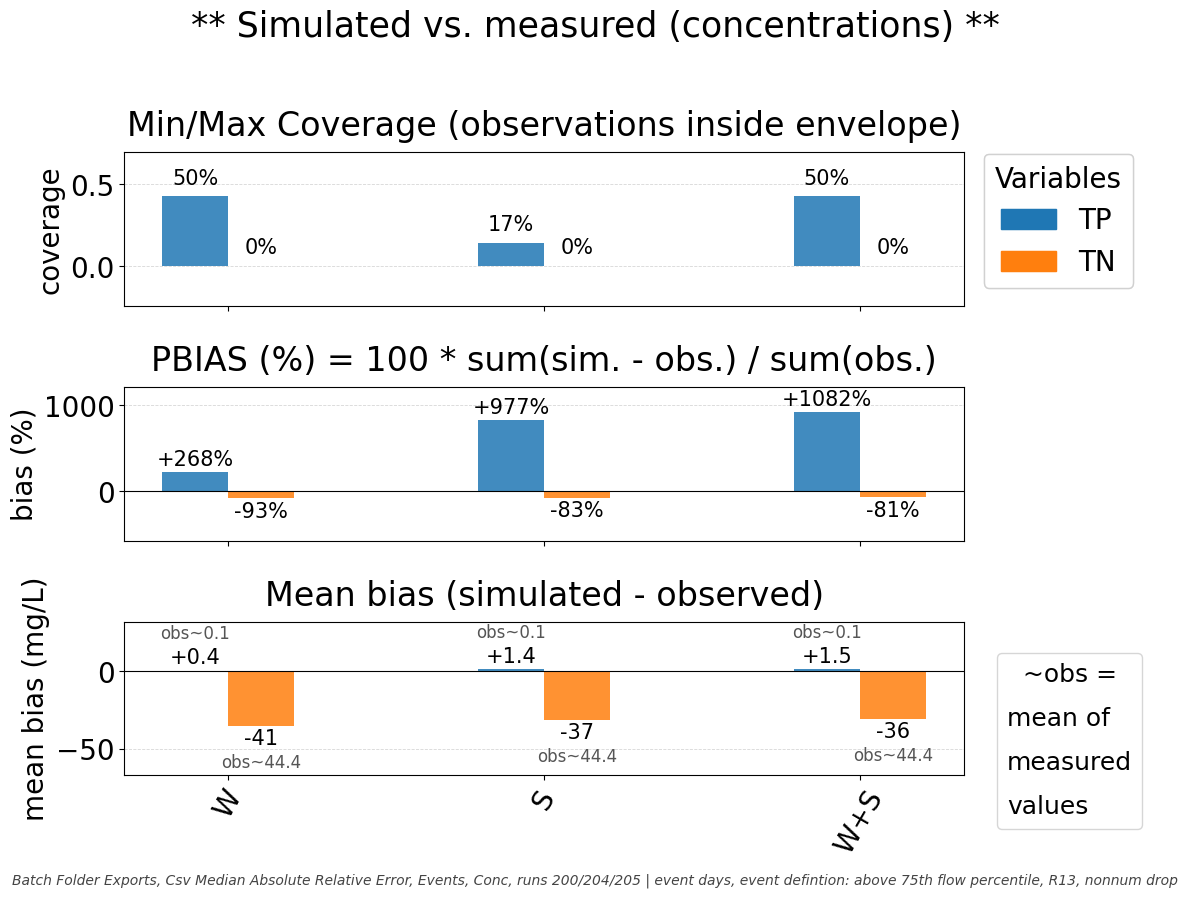


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Events, Conc, runs 200/204/205 | event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.333,+200.0%,0.5,0.167,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.333,-66.7%,0.167,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.167,,0.167,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-709,-72.6%,268,977,,,,,,,,,,


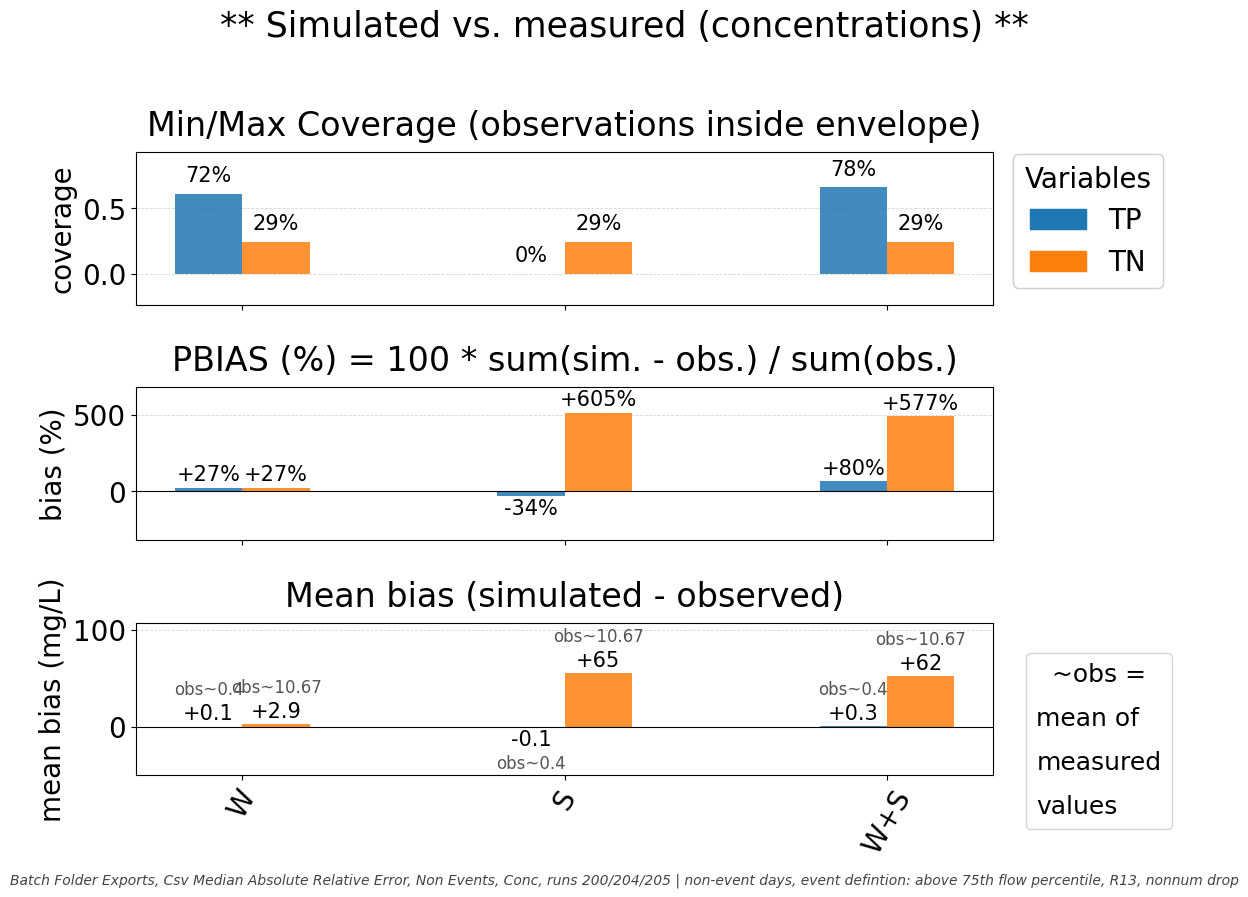


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (concentrations) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Non Events, Conc, runs 200/204/205 | non-event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.722,,0.722,0,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0556,-7.1%,0.722,0.778,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.778,-100.0%,0,0.778,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.286,0.286,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.286,0.286,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.286,0.286,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.437,+152.8%,0.722,0.286,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.286,-100.0%,0,0.286,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.492,+172.2%,0.778,0.286,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+60.9,+181.6%,27.4,-33.5,,,,,,,,,,



----------------------------------------------------------------------------------------
Chart 3: Load graphs
----------------------------------------------------------------------------------------


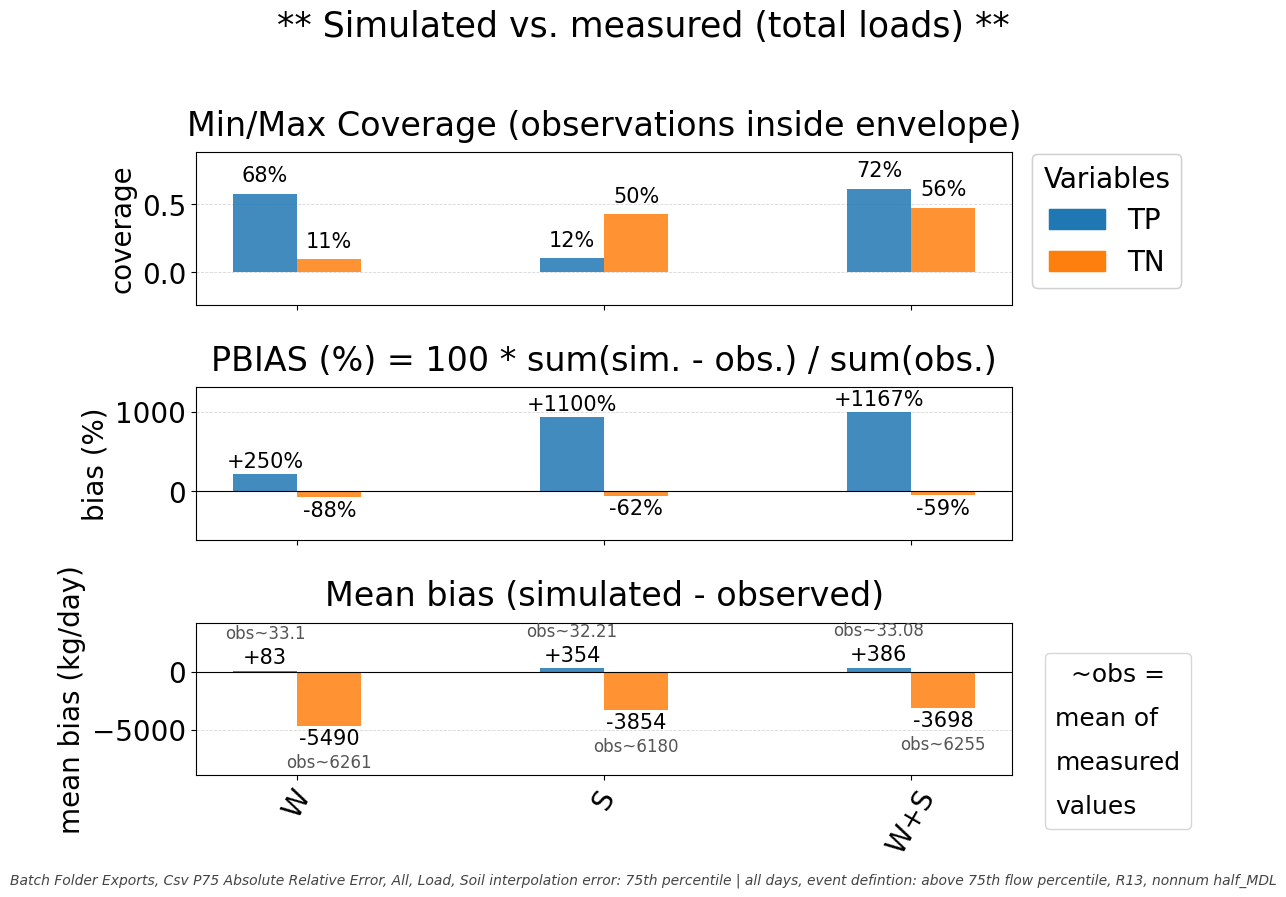


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | all days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.56,+466.7%,0.68,0.12,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.04,-5.6%,0.68,0.72,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.6,-83.3%,0.12,0.72,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.389,-77.8%,0.111,0.5,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.444,-80.0%,0.111,0.556,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,-0.0556,-10.0%,0.5,0.556,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.569,+512.0%,0.68,0.111,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.38,-76.0%,0.12,0.5,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.164,+29.6%,0.72,0.556,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-850,-77.2%,250,1.1e+03,,,,,,,,,,


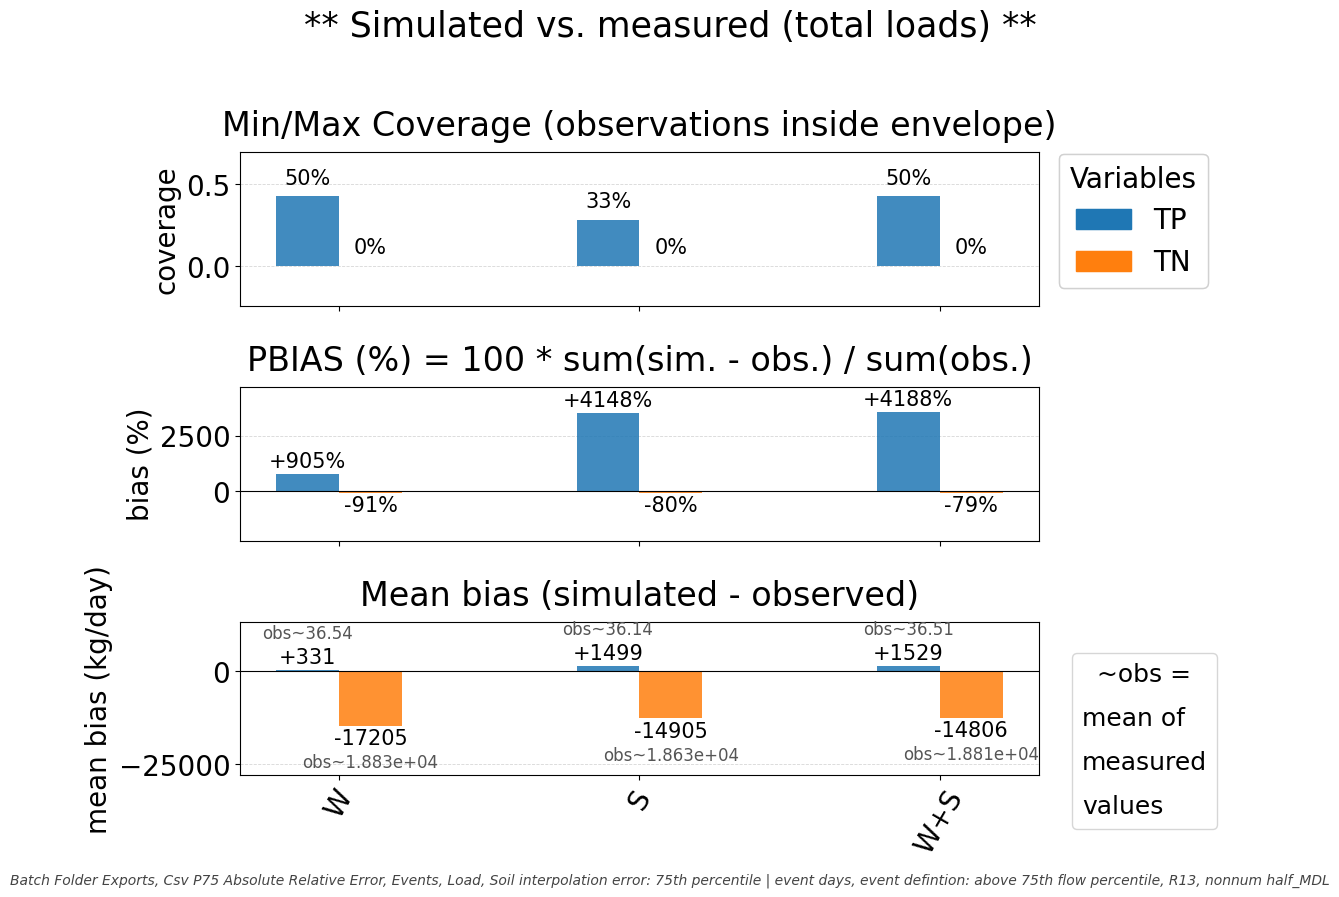


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Events, Load, Soil interpolation error: 75th percentile | event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.167,+50.0%,0.5,0.333,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.167,-33.3%,0.333,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.333,,0.333,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-3.24e+03,-78.2%,905,4.15e+03,,,,,,,,,,


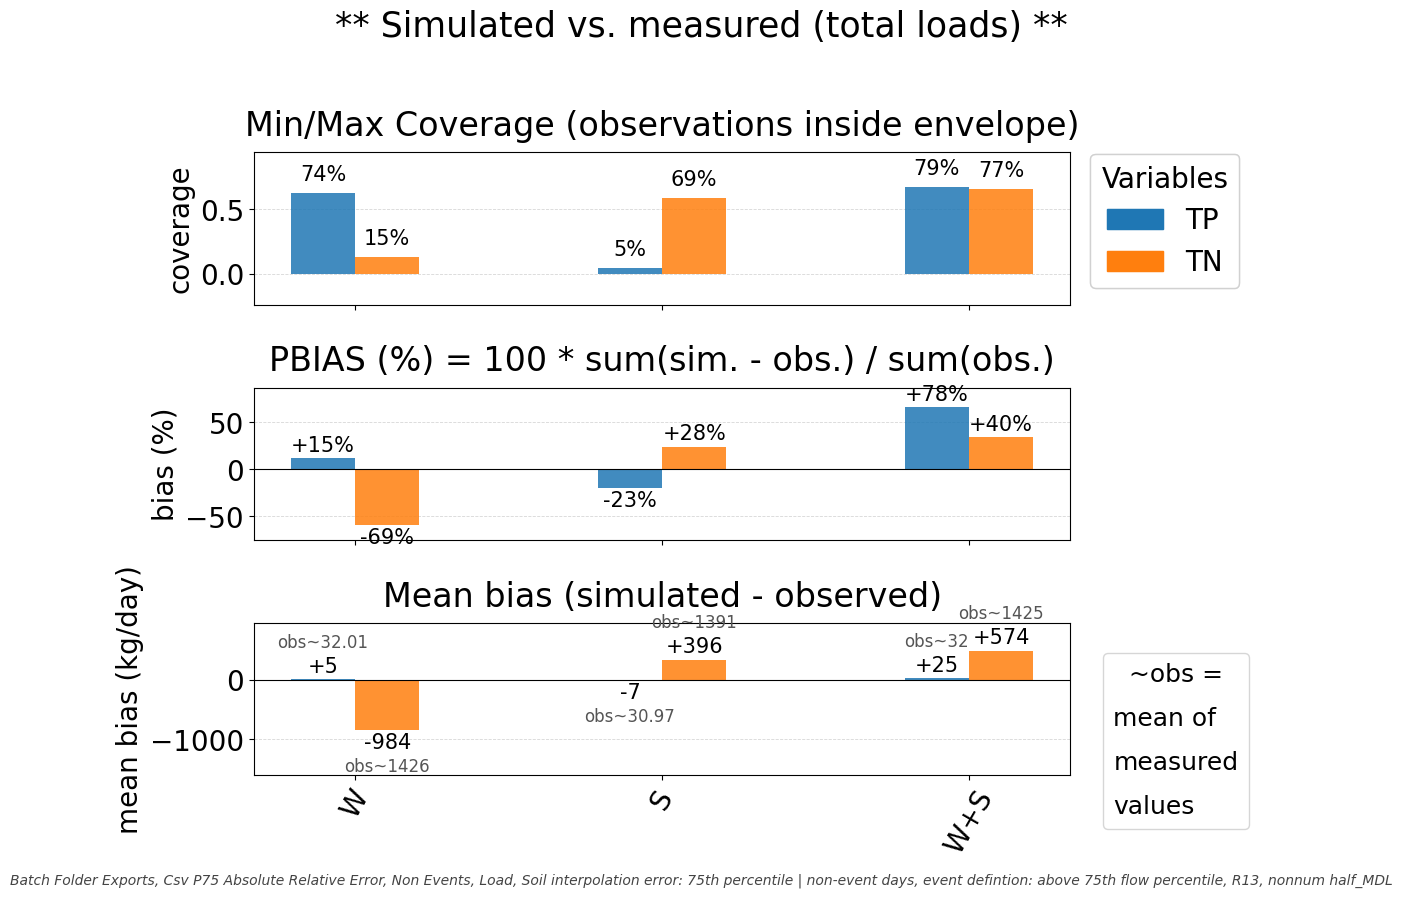


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Non Events, Load, Soil interpolation error: 75th percentile | non-event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.684,+1300.0%,0.737,0.0526,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0526,-6.7%,0.737,0.789,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.737,-93.3%,0.0526,0.789,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.538,-77.8%,0.154,0.692,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.615,-80.0%,0.154,0.769,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,-0.0769,-10.0%,0.692,0.769,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.583,+378.9%,0.737,0.154,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.64,-92.4%,0.0526,0.692,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.0202,+2.6%,0.789,0.769,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+37.3,+163.7%,14.5,-22.8,,,,,,,,,,


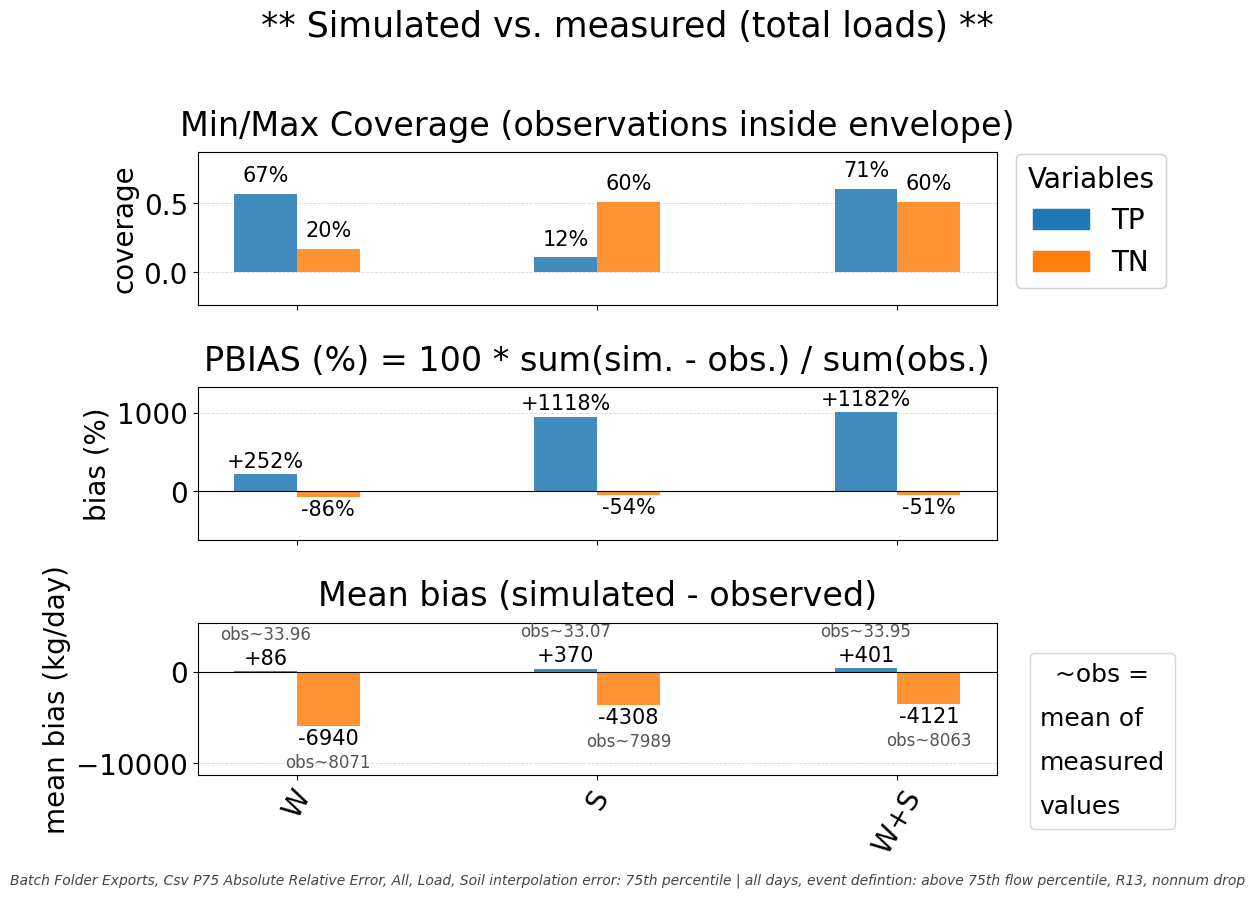


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, All, Load, Soil interpolation error: 75th percentile | all days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.542,+433.3%,0.667,0.125,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0417,-5.9%,0.667,0.708,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.583,-82.4%,0.125,0.708,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.4,-66.7%,0.2,0.6,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.4,-66.7%,0.2,0.6,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.6,0.6,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.467,+233.3%,0.667,0.2,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.475,-79.2%,0.125,0.6,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.108,+18.1%,0.708,0.6,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-866,-77.4%,252,1.12e+03,,,,,,,,,,


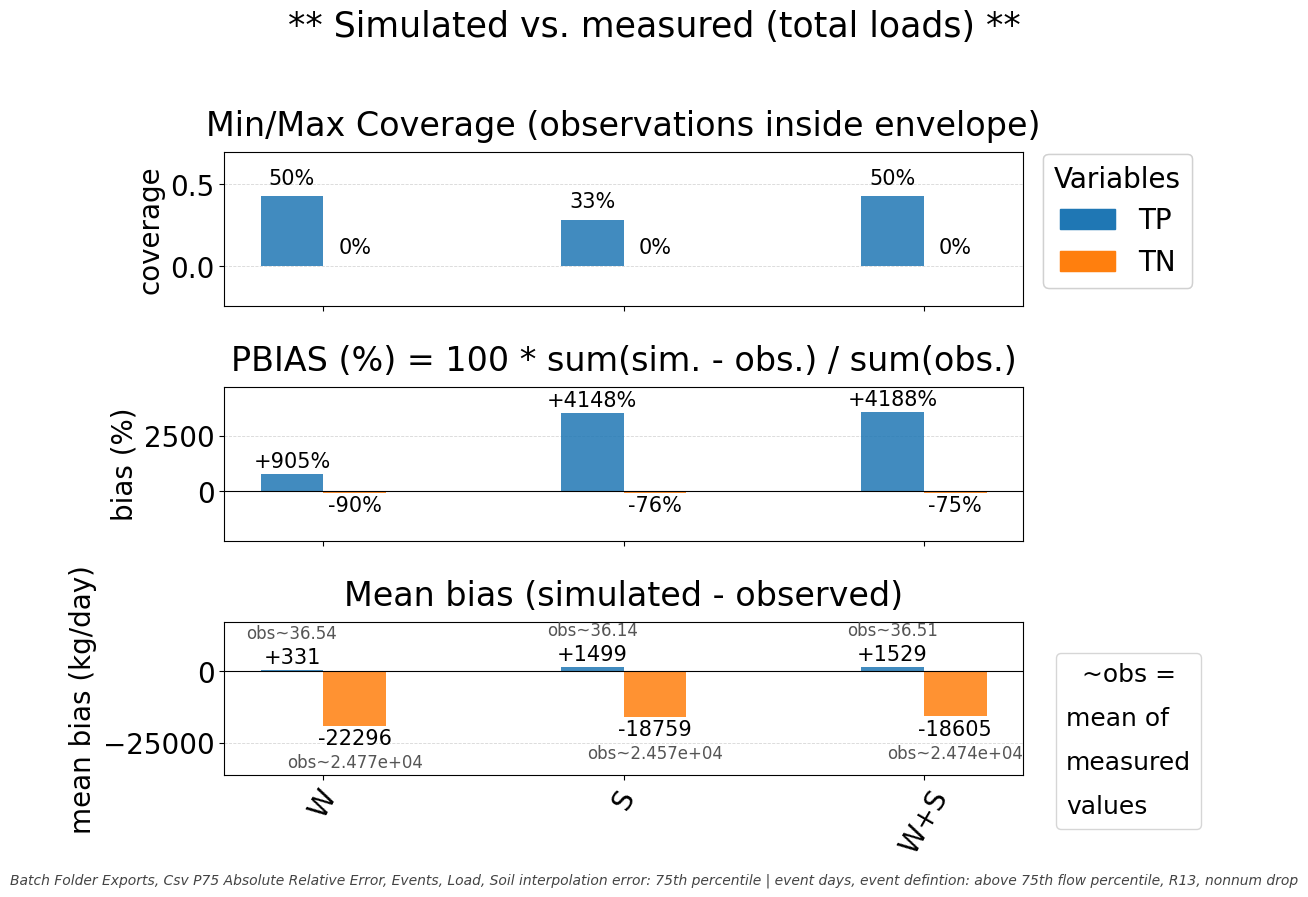


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Events, Load, Soil interpolation error: 75th percentile | event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.167,+50.0%,0.5,0.333,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.167,-33.3%,0.333,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.333,,0.333,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-3.24e+03,-78.2%,905,4.15e+03,,,,,,,,,,


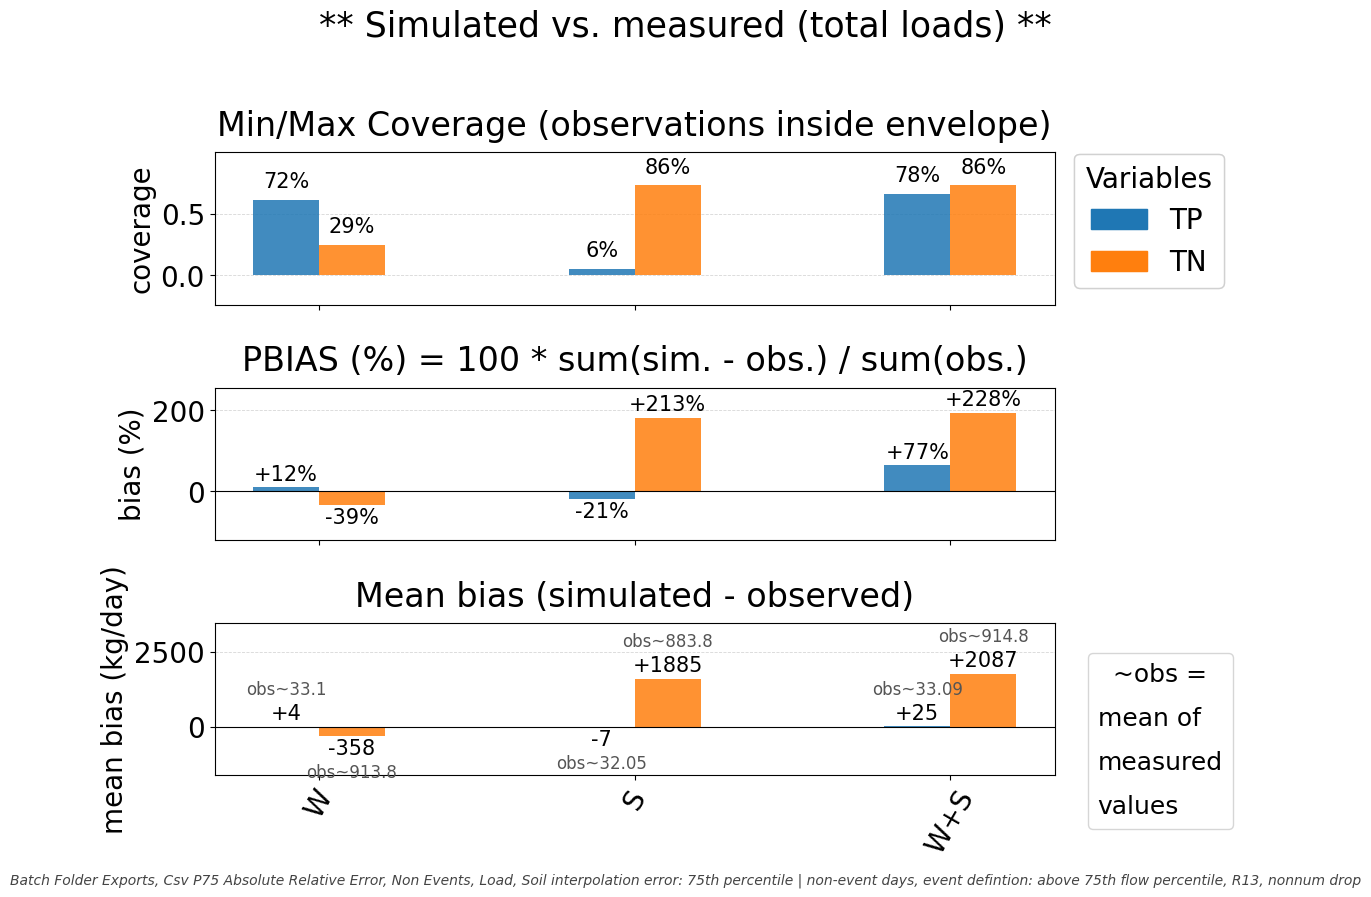


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv P75 Absolute Relative Error, Non Events, Load, Soil interpolation error: 75th percentile | non-event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.667,+1200.0%,0.722,0.0556,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0556,-7.1%,0.722,0.778,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.722,-92.9%,0.0556,0.778,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,-0.571,-66.7%,0.286,0.857,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,-0.571,-66.7%,0.286,0.857,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.857,0.857,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.437,+152.8%,0.722,0.286,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.802,-93.5%,0.0556,0.857,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,-0.0794,-9.3%,0.778,0.857,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+33.3,+156.9%,12.1,-21.2,,,,,,,,,,


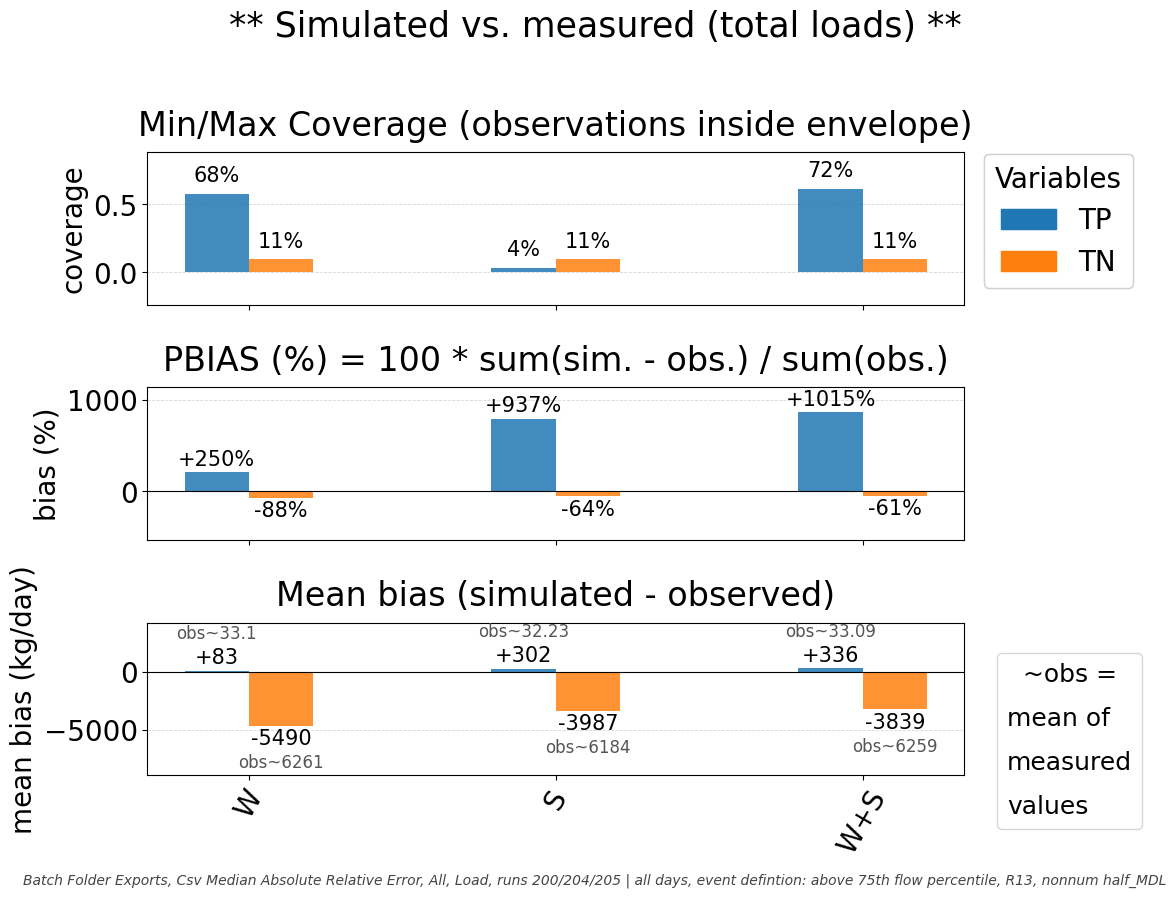


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Load, runs 200/204/205 | all days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.64,+1600.0%,0.68,0.04,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.04,-5.6%,0.68,0.72,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.68,-94.4%,0.04,0.72,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.111,0.111,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.111,0.111,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.111,0.111,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.569,+512.0%,0.68,0.111,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.0711,-64.0%,0.04,0.111,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.609,+548.0%,0.72,0.111,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-687,-73.3%,250,937,,,,,,,,,,


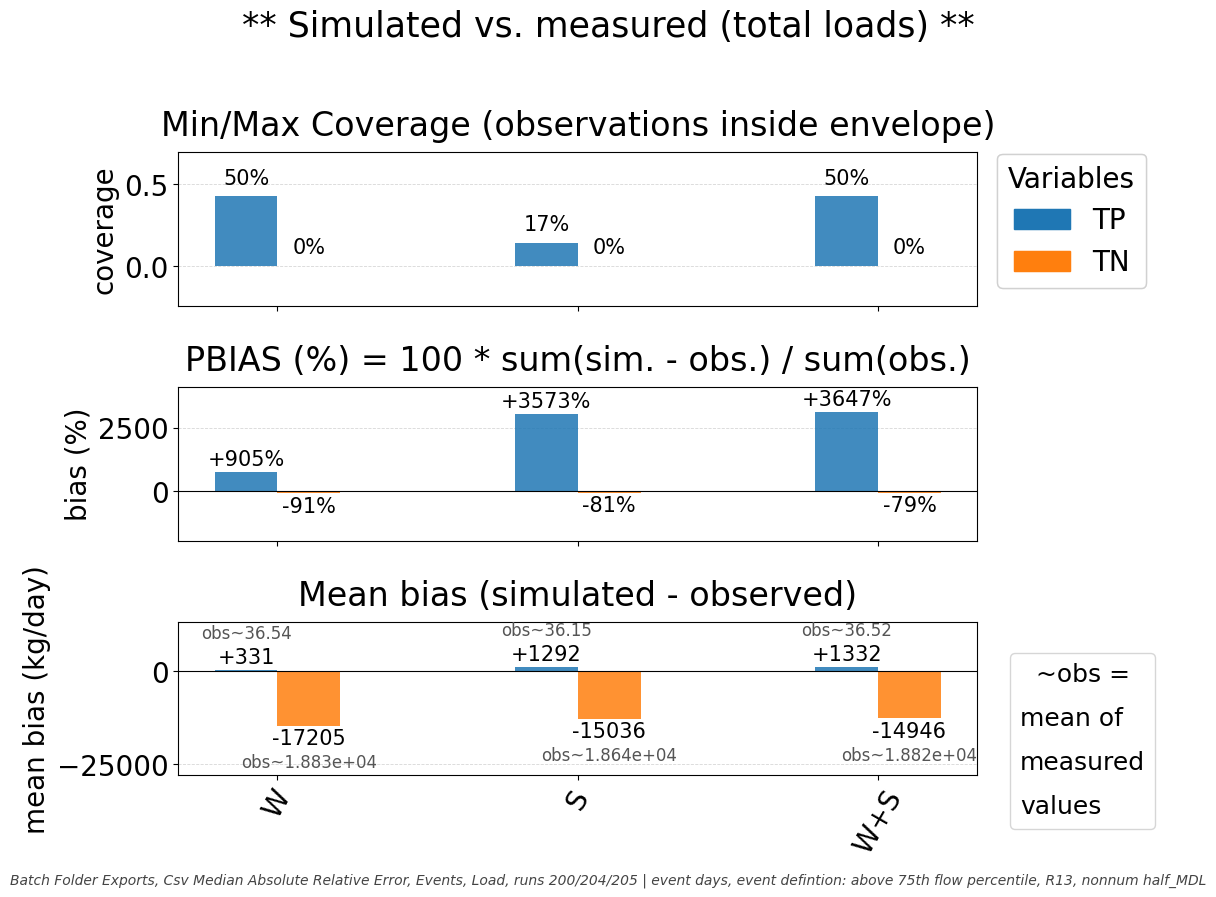


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Events, Load, runs 200/204/205 | event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.333,+200.0%,0.5,0.167,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.333,-66.7%,0.167,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.167,,0.167,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-2.67e+03,-74.7%,905,3.57e+03,,,,,,,,,,


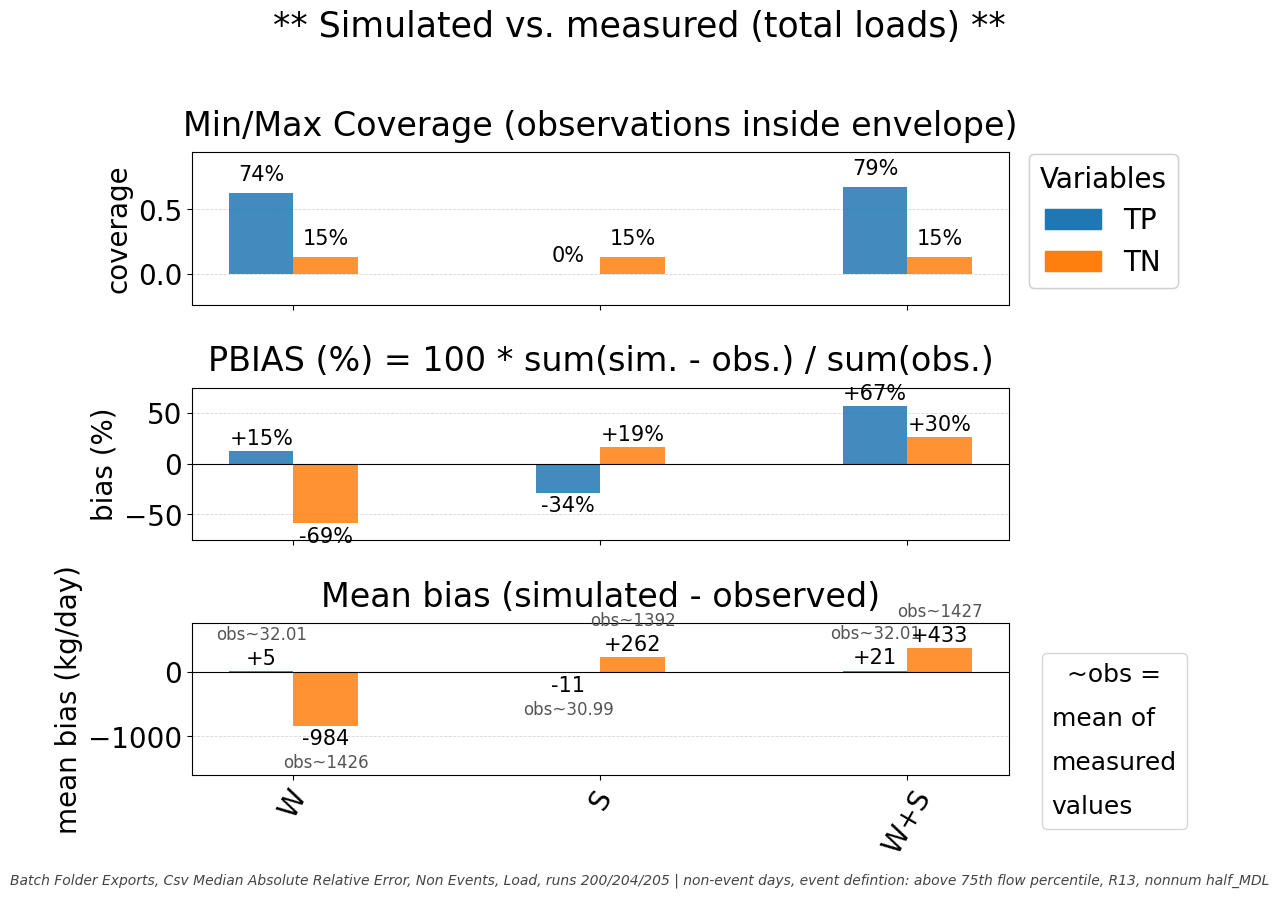


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Non Events, Load, runs 200/204/205 | non-event days, event defintion: above 75th flow percentile, R13, nonnum half_MDL
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.737,,0.737,0,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0526,-6.7%,0.737,0.789,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.789,-100.0%,0,0.789,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.154,0.154,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.154,0.154,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.154,0.154,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.583,+378.9%,0.737,0.154,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.154,-100.0%,0,0.154,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.636,+413.2%,0.789,0.154,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+48.4,+142.8%,14.5,-33.9,,,,,,,,,,


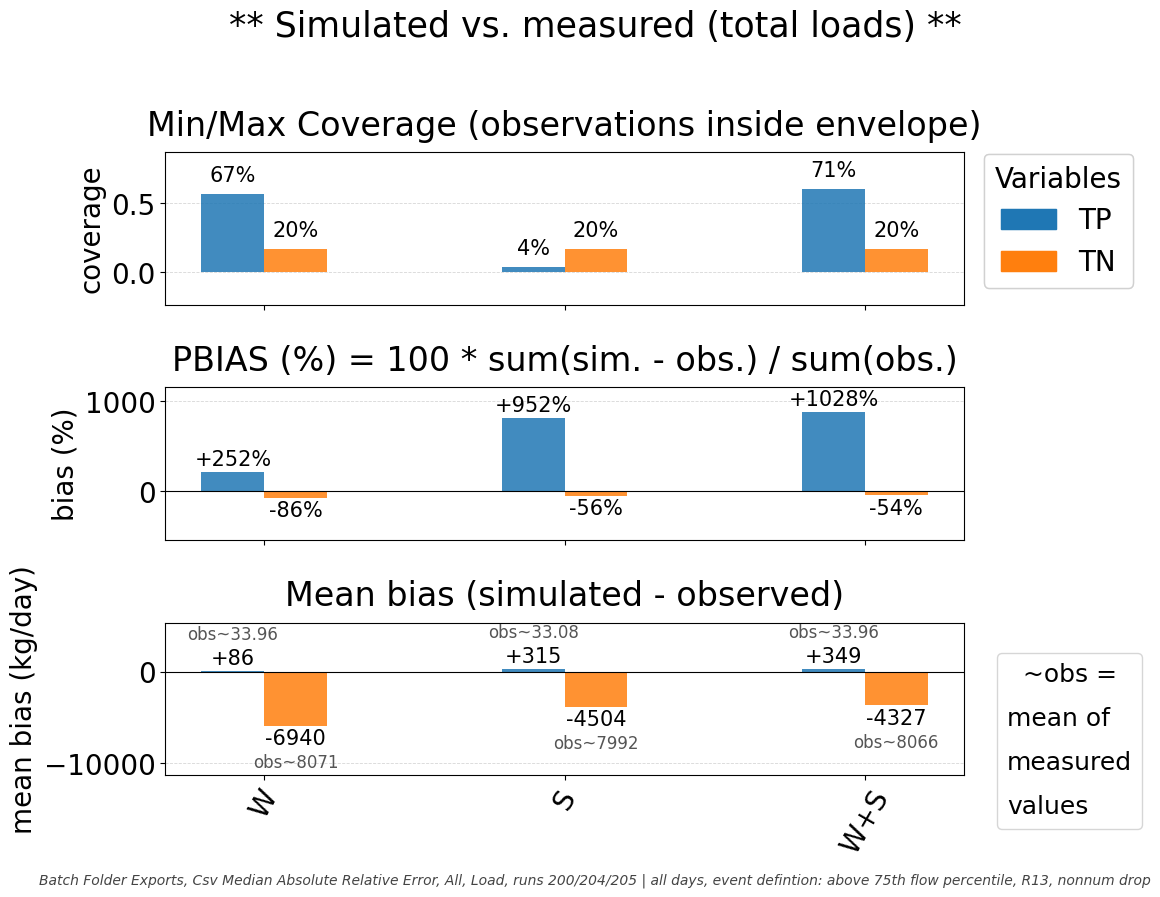


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv Median Absolute Relative Error, All, Load, runs 200/204/205 | all days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.625,+1500.0%,0.667,0.0417,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0417,-5.9%,0.667,0.708,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.667,-94.1%,0.0417,0.708,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.2,0.2,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.2,0.2,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.2,0.2,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.467,+233.3%,0.667,0.2,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.158,-79.2%,0.0417,0.2,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.508,+254.2%,0.708,0.2,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-700,-73.5%,252,952,,,,,,,,,,


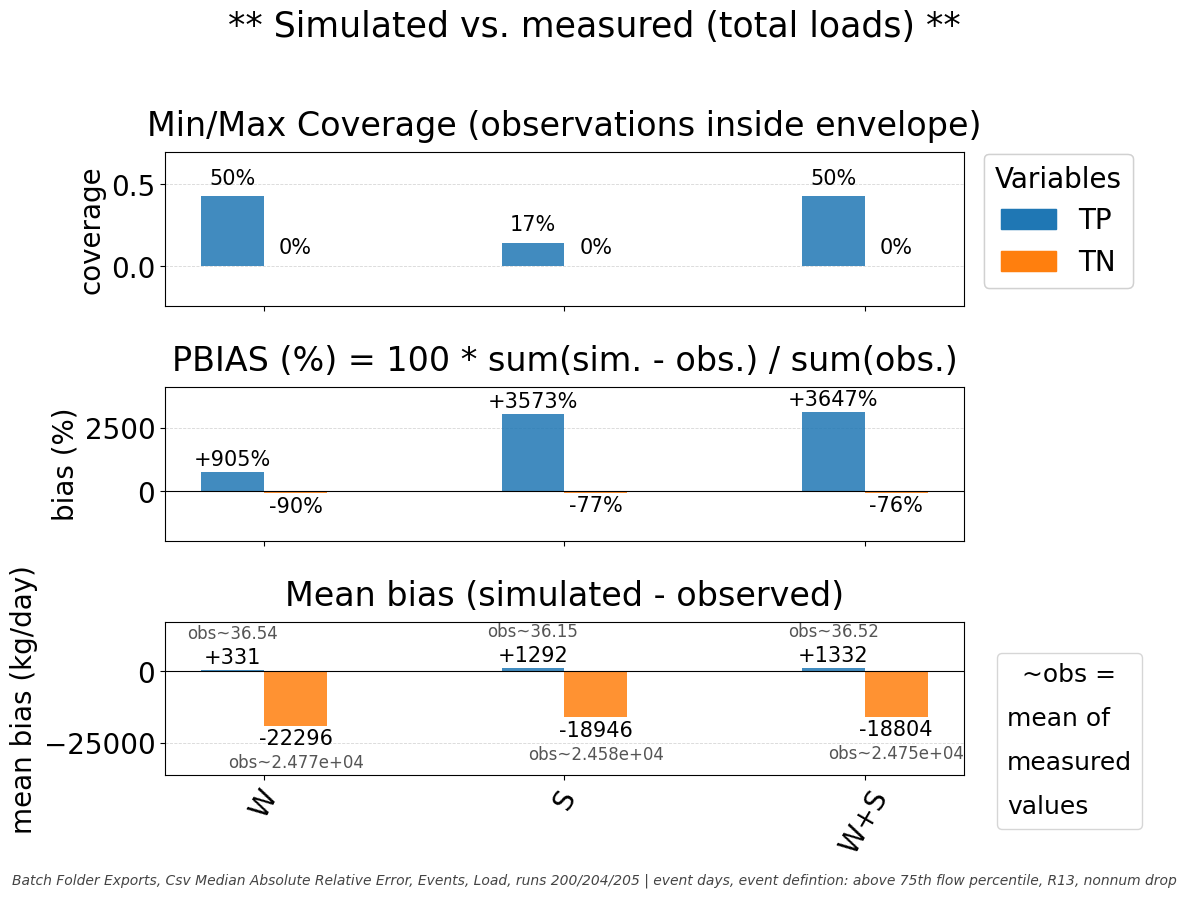


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Events, Load, runs 200/204/205 | event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.333,+200.0%,0.5,0.167,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,+0,+0.0%,0.5,0.5,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.333,-66.7%,0.167,0.5,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,,0,0,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,,0,0,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.5,,0.5,0,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,+0.167,,0.167,0,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.5,,0.5,0,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,-2.67e+03,-74.7%,905,3.57e+03,,,,,,,,,,


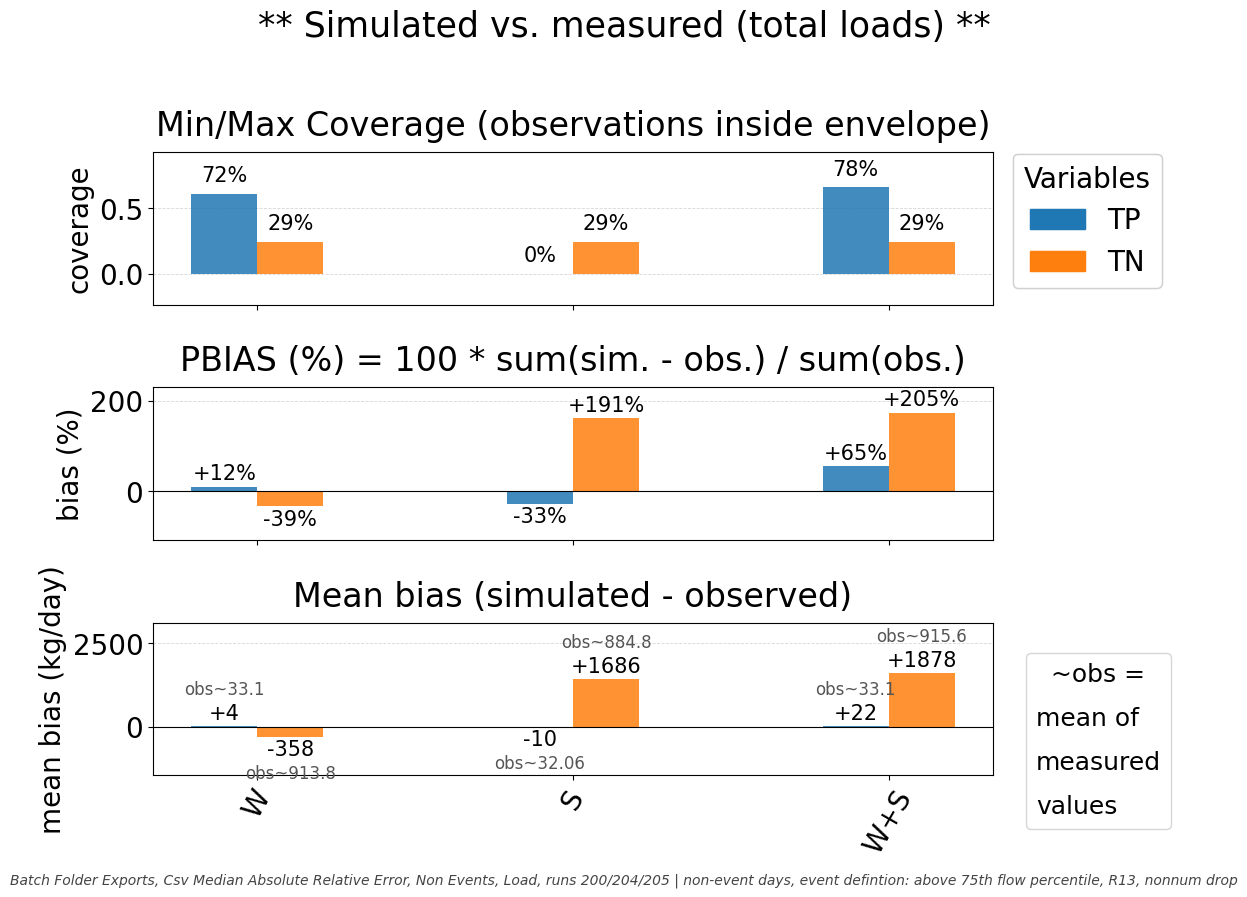


"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-
  Table: ** Simulated vs. measured (total loads) **
  Batch Folder Exports, Csv Median Absolute Relative Error, Non Events, Load, runs 200/204/205 | non-event days, event defintion: above 75th flow percentile, R13, nonnum drop
"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-


,Metric,Comparison,Group A,Group B,Δ (A−B),Δ rel,Value A,Value B,SD(A),SD(B),n(A),n(B),t,p,sig,Cohen’s d,CI₉₅ lo,CI₉₅ hi
0,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,SOIL / TP,+0.722,,0.722,0,,,,,,,,,,
1,Min/Max Coverage (observations inside envelope),scenario,WASTE / TP,WASTE+SOIL / TP,-0.0556,-7.1%,0.722,0.778,,,,,,,,,,
2,Min/Max Coverage (observations inside envelope),scenario,SOIL / TP,WASTE+SOIL / TP,-0.778,-100.0%,0,0.778,,,,,,,,,,
3,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,SOIL / TN,+0,+0.0%,0.286,0.286,,,,,,,,,,
4,Min/Max Coverage (observations inside envelope),scenario,WASTE / TN,WASTE+SOIL / TN,+0,+0.0%,0.286,0.286,,,,,,,,,,
5,Min/Max Coverage (observations inside envelope),scenario,SOIL / TN,WASTE+SOIL / TN,+0,+0.0%,0.286,0.286,,,,,,,,,,
6,Min/Max Coverage (observations inside envelope),variable,WASTE / TP,WASTE / TN,+0.437,+152.8%,0.722,0.286,,,,,,,,,,
7,Min/Max Coverage (observations inside envelope),variable,SOIL / TP,SOIL / TN,-0.286,-100.0%,0,0.286,,,,,,,,,,
8,Min/Max Coverage (observations inside envelope),variable,WASTE+SOIL / TP,WASTE+SOIL / TN,+0.492,+172.2%,0.778,0.286,,,,,,,,,,
9,PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.),scenario,WASTE / TP,SOIL / TP,+44.7,+137.1%,12.1,-32.6,,,,,,,,,,



Fisnished chart 3 for all configured folders.
Chart 3 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  compare_mode: conc
  scenarios: ['WASTE', 'SOIL', 'WASTE+SOIL']
  variables: ['TP', 'TN']
Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\batch_folder_exports\csv_p75_absolute_relative_error\half_mdl\all\conc\runs_188_200_201__vars_tot_nkg_tot_pkg
run-188: export_variable=tot-nkg scenario=SOIL, variable=TN
run-188: export_variable=tot-pkg scenario=SOIL, variable=TP
run-200: export_variable=tot-nkg scenario=WASTE, variable=TN
run-200: export_variable=tot-pkg scenario=WASTE, variable=TP
run-201: export_variable=tot-nkg scenario=WASTE+SOIL, variable=TN
run-201: export_variable=tot-pkg scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 189, 202, 203, 204, 205]

Built 6 export specs

Chart 3 folder: runs_18

In [20]:
chart_3_metrics_by_folder = {}

chart_3_logs = []



# For chart 3:

# - title controls the subplot title you see on the figure

# - source_title points to the exported metric label used to fetch the raw value

# - sign_multiplier lets you flip the displayed sign without changing the export files

three_metric_specs = [

    {

        "title": "Min/Max Coverage (observations inside envelope)",

    },

    {

        "source_title": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)",

        "title": "PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.)",

        "sign_multiplier": -1,

    },

    {

        "source_title": "Mean bias (observed - simulated)",

        "title": "Mean bias (simulated - observed)",

        "sign_multiplier": -1,

    },

]



# Chart 3 y-axis label options:

# - chart_3_y_labels gives one label per subplot, top to bottom

# - chart_3_shared_y_label adds one label spanning all plotted subplots

# - set chart_3_show_individual_y_labels = False if you only want the shared label

chart_3_y_labels = [

    "coverage",

    "bias (%)",

    "mg/L or kg/day",

]

chart_3_shared_y_label = None

chart_3_show_individual_y_labels = True

chart_3_shared_y_label_x = 0.02



# Implied observed baseline diagnostic for chart 3:

# - set chart_3_show_implied_observed_panel = True to restore the separate fourth panel

# - set chart_3_show_implied_observed_annotations = True to show compact labels in the mean-bias panel

# - values are suppressed as chart_3_implied_observed_low_pbias_text when |PBIAS| is below the threshold

chart_3_show_implied_observed_panel = False

chart_3_show_implied_observed_annotations = True

chart_3_implied_observed_title = "Implied mean observed baseline"

chart_3_implied_observed_y_label = "implied mean obs."

chart_3_implied_observed_format = "{:.4g}"

chart_3_implied_observed_annotation_prefix = "obs~"

chart_3_implied_observed_annotation_offset_points = 18

chart_3_implied_observed_min_abs_pbias = 5.0

chart_3_implied_observed_low_pbias_text = "obs~n/a"

chart_3_third_metric_small_value_threshold = 3.0

chart_3_third_metric_small_value_decimals = 1

chart_3_show_implied_observed_annotation_legend = True

chart_3_implied_observed_annotation_legend_title = "~obs ="

chart_3_implied_observed_annotation_legend_lines = [

    "mean of ",

    "measured",

    "values",

    #"n/a: |PBIAS| < 5%",

]

chart_3_implied_observed_annotation_legend_fs = 18

chart_3_implied_observed_annotation_legend_loc = "lower left"

chart_3_implied_observed_annotation_legend_bbox = (0.835, 0.07)



three_metric_semantic_label_map = {

    **semantic_label_map,

    **example_semantic_label_map,

    "coverage100": {

        "label": "Min/Max Coverage (observations inside envelope)",

        "path": ("same_day", "coverage100"),

    },

    "PBIAS%": {

        "label": "PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)",

        "path": ("same_day", "PBIAS%"),

    },

    "Bias(obs-pred)": {

        "label": "Mean bias (observed - simulated)",

        "path": ("same_day", "Bias(obs-pred)"),

    },

}





_last_ch3_compare_mode = None
for batch_folder in batch_folders:
    _ch3_compare_mode = _resolve_batch_folder_compare_mode(batch_folder)
    if _ch3_compare_mode != _last_ch3_compare_mode:
        _print_graph_group_separator(_ch3_compare_mode, chart_label='Chart 3')
        _last_ch3_compare_mode = _ch3_compare_mode

    generated_specs, build_log = _capture_stdout(

        build_export_specs_from_folder,

        batch_folder,

        run_to_scenario,

        variable_map,

        verbose=True,

    )



    _ch3_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))

    _ch3_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))

    _ch3_selected_scenarios = _ordered_present_values(_ch3_actual_scenarios, chart_scenario_order)

    _ch3_selected_variables = _ordered_present_values(_ch3_actual_variables, chart_variable_order)



    _ch3_example_export = _load_stat_export(generated_specs[0], verbose=False)

    _ch3_dashboard_state = (

        _ch3_example_export["payload"].get("metadata", {}).get("dashboard_state")

        or _ch3_example_export["payload"].get("dashboard_state")

        or {}

    )

    _ch3_compare_mode = str(_ch3_dashboard_state.get("compare_mode") or "load").strip().lower()

    _ch3_y_labels = list(chart_3_y_labels)

    if _ch3_compare_mode == "conc":

        ch_3_chart_descriptor = "** Simulated vs. measured (concentrations) **"

        _ch3_y_labels[2] = "mean bias (mg/L)"

    else:

        ch_3_chart_descriptor = "** Simulated vs. measured (total loads) **"

        _ch3_y_labels[2] = "mean bias (kg/day)"



    ch_3_title_metadata_parts = [

    "folder_label",           # represents interpolation error and MDL handling policy

    "view",                   # represents event vs non-event vs all days

    "event_threshold",        # defines event definition (e.g. P75, abs)

    #"measured_selection",     # summarises which chemicals and stations were included in the measured data for this chart (e.g. "measured: TKN + Nitrate; Station: 30304")

    #"n",                      # number of measurements considere by above filter and mapping

    "reach",                  # represents the reach being analysed (e.g. 13)

    "measured_nonnum_policy", 

    ]



    ch_3_title_folder_label_map = {

        # exact-match shorthand  (token: label)

        "runs_187_200_202":      "Soil interpolation error: relative median",

        "runs_205_200_204":      "Soil interpolation error: absolute median",

        "runs_189_200_203":      "Soil interpolation error: relative RMSE",

        "runs_188_200_201":      "Soil interpolation error: 75th percentile",

        "runs_153_155_157":      "Original TFM (relative RMSE)",

        "drop_mdl":              None, #"drop-below-DL",

        "half_mdl":              None, #"half-DL",

    }





    EVENT_THRESHOLD_TITLE_ALIASES = {

    "p50": "event defintion: above 50th flow percentile",

    "p75": "event defintion: above 75th flow percentile",

    "p90": "event defintion: above 90th flow percentile",

    "abs": "event defintion: above absolute flow value",

    }       



    chart_title, chart_subtitle = build_semantic_chart_title(

        batch_folder, generated_specs,

        ch_3_chart_descriptor,

        title_metadata_parts=ch_3_title_metadata_parts,

        title_folder_label_map=ch_3_title_folder_label_map,

    )





    fig, ax, three_metric_stats = plot_three_metric_comparison(

        generated_specs,

        metric_specs=three_metric_specs,

        semantic_label_map=three_metric_semantic_label_map,

        variable_order=_ch3_selected_variables,

        scenario_order=_ch3_selected_scenarios,

        title=chart_title,

        subtitle=chart_subtitle,

        y_label="compared to msrmnts",

        y_labels=_ch3_y_labels,

        shared_y_label=chart_3_shared_y_label,

        show_individual_y_labels=chart_3_show_individual_y_labels,

        shared_y_label_x=chart_3_shared_y_label_x,

        show_implied_observed_panel=chart_3_show_implied_observed_panel,

        show_implied_observed_annotations=chart_3_show_implied_observed_annotations,

        implied_observed_title=chart_3_implied_observed_title,

        implied_observed_y_label=chart_3_implied_observed_y_label,

        implied_observed_format=chart_3_implied_observed_format,

        implied_observed_annotation_prefix=chart_3_implied_observed_annotation_prefix,

        implied_observed_annotation_offset_points=chart_3_implied_observed_annotation_offset_points,

        implied_observed_min_abs_pbias=chart_3_implied_observed_min_abs_pbias,

        implied_observed_low_pbias_text=chart_3_implied_observed_low_pbias_text,

        third_metric_small_value_threshold=chart_3_third_metric_small_value_threshold,

        third_metric_small_value_decimals=chart_3_third_metric_small_value_decimals,



        show_implied_observed_annotation_legend=chart_3_show_implied_observed_annotation_legend,

        implied_observed_annotation_legend_title=chart_3_implied_observed_annotation_legend_title,

        implied_observed_annotation_legend_lines=chart_3_implied_observed_annotation_legend_lines,

        implied_observed_annotation_legend_fs=chart_3_implied_observed_annotation_legend_fs,

        implied_observed_annotation_legend_loc=chart_3_implied_observed_annotation_legend_loc,

        implied_observed_annotation_legend_bbox=chart_3_implied_observed_annotation_legend_bbox,



        figsize=(12, 9),

        abbreviations=chart_abbreviations,

        annotate_rotation=60,

        annot_fs=15,

        tick_fs=20,

        title_fs=24,

        subtitle_fs=10,

        label_fs=20,

        legend_fs=20,

        title_pad=12,

        subplot_h_pad=1.1,

        positive_bar_h_pad_scale=1.8,

        legend_outside=False,

        legend_loc="upper right",

        legend_bbox=(0.96, 0.835),

        tight_layout_rect=(0.0, 0.02, 0.82, 0.94),

        verbose=False,

        signed_positive_axis_fraction=0.32,

        signed_negative_axis_fraction=0.32,

        label_offset_scale=0.03,

        annotation_offset_points=6,

        signed_annotation_offset_points=2,

        top_margin_scale=0.22,

        height_scale=0.85,

    )

    plt.show()


    # "-- Significance table for Chart 3 "--
    display_chart_significance_tables(
        three_metric_stats,
        generated_specs,
        chart_title=f"Table: {chart_title}",
        chart_subtitle=chart_subtitle,
        comparison_modes=("scenarios", "variables"),
        scenarios=_ch3_selected_scenarios,
        variables=_ch3_selected_variables,
        metric_label_to_technical={
            "Min/Max Coverage (observations inside envelope)": "coverage100",
            "PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.)": "PBIAS%",
            "Mean bias (simulated - observed)": "Bias(obs-pred)",
        },
    )


    saved_path, save_log = _capture_stdout(

        _save_chart_figure,

        fig,

        batch_folder.name,

        "chart_3_three_metric",

        save_enabled=save_individual_chart_images,

        output_root=saved_chart_root,

        dpi=saved_chart_dpi,

    )

    plt.close(fig)



    chart_3_metrics_by_folder[batch_folder.name] = three_metric_stats

    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_3_metrics"] = three_metric_stats

    chart_results_by_folder[batch_folder.name]["chart_3_saved_path"] = saved_path



    chart_3_logs.append(f"Chart 3 folder: {batch_folder.name}")

    chart_3_logs.append(f"  compare_mode: {_ch3_compare_mode}")

    chart_3_logs.append(f"  scenarios: {_ch3_selected_scenarios}")

    chart_3_logs.append(f"  variables: {_ch3_selected_variables}")

    if build_log.strip():

        chart_3_logs.append(build_log.rstrip())

    if save_log.strip():

        chart_3_logs.append(save_log.rstrip())

    chart_3_logs.append("")



print("\nFisnished chart 3 for all configured folders.")

print("\n".join(line for line in chart_3_logs if line is not None))


In [20]:
# Debug chart-3 resolved values for the most recent folder/variant
_last_folder = next(reversed(chart_3_metrics_by_folder))
_last_metrics = chart_3_metrics_by_folder[_last_folder]["metrics"]
print("Last folder:", _last_folder)
for _metric_label, _metric_block in _last_metrics.items():
    if str(_metric_label).startswith("__"):
        continue
    print("\n", _metric_label)
    for _scenario, _var_map in _metric_block.items():
        if str(_scenario).startswith("__"):
            continue
        _shown = {k: v for k, v in _var_map.items()}
        print(" ", _scenario, _shown)

Last folder: runs_200_204_205__vars_tot_nkg_tot_pkg

 Min/Max Coverage (observations inside envelope)
  WASTE {'TN': 0.2857142857142857, 'TP': 0.7222222222222222}
  SOIL {'TN': 0.2857142857142857, 'TP': 0.0}
  WASTE+SOIL {'TN': 0.2857142857142857, 'TP': 0.7777777777777778}

 PBIAS (%) = 100 * sum(sim. - obs.) / sum(obs.)
  WASTE {'TN': -39.215932349887396, 'TP': 12.092141314397457}
  SOIL {'TN': 190.50412962922667, 'TP': -32.57967700531094}
  WASTE+SOIL {'TN': 205.0945729894434, 'TP': 65.49549215215825}

 Mean bias (simulated - observed)
  WASTE {'TN': -358.36084228571445, 'TP': 4.00296637333333}
  SOIL {'TN': 1685.6401417142858, 'TP': -10.445207137777778}
  WASTE+SOIL {'TN': 1877.911081142857, 'TP': 21.680851626666666}

 Implied mean observed baseline
  WASTE {'TP': 33.103866960000005, 'TN': 913.8144137142858}
  SOIL {'TP': 32.060499359999994, 'TN': 884.8312868571428}
  WASTE+SOIL {'TP': 33.10281504000001, 'TN': 915.6317760000001}


In [21]:
# Debug mapping from chart-3 labels to technical names/paths
_req_labels = [spec["source_title"] for spec in _normalise_three_metric_specs(three_metric_specs)]
_specs = _build_requested_metric_specs(_req_labels, _normalise_semantic_label_map(three_metric_semantic_label_map), format_val)
for _s in _specs:
    print(_s)

{'technical_name': 'coverage100', 'output_label': 'Min/Max Coverage (observations inside envelope)', 'format': '{:.0%}', 'path': ('same_day', 'coverage100')}
{'technical_name': 'PBIAS%', 'output_label': 'PBIAS (%) = 100 * sum(observed - simulated) / sum(observed)', 'format': '{:+.0f}%', 'path': ('same_day', 'PBIAS%')}
{'technical_name': 'Bias(obs-pred)', 'output_label': 'Mean bias (observed - simulated)', 'format': '{:+.0f}', 'path': ('same_day', 'Bias(obs-pred)')}
